# 04 Geographic Analysis - Regional Market Analysis

## Project Background
In e-commerce business, different geographic regions often exhibit substantial differences in performance. States and cities may vary significantly in terms of order volume, spending power, product preferences, logistics efficiency, and customer satisfaction.
Therefore, analyzing the business only from an overall perspective is not sufficient. A geographic perspective is needed to identify which regions are core markets, which have strong growth potential, and which still face challenges in logistics and service quality.

This project is based on order, customer, product, seller, delivery, and review data. It aims to conduct a systematic geographic analysis of e-commerce performance from a spatial perspective. By building state-level and city-level regional indicators, and combining sales performance, delivery efficiency, customer satisfaction, and product preference analysis, this project seeks to uncover meaningful regional patterns and provide data support for regional operations and market expansion strategies.

## Project Objectives
- Identify high-value regions and potential growth markets
- Analyze regional differences in spending power and product preferences
- Optimize logistics performance and region-specific operations
- Provide insights to support market expansion decisions

## Key Business Questions
1. Which states and cities contribute the most orders and revenue?
2. Is e-commerce revenue concentrated in a small number of core regions?
3. Are there significant regional differences in average order value, repeat purchase behavior, and customer value?
4. How do different regions perform in delivery time, delay rate, and freight cost?
5. Is regional customer satisfaction associated with logistics performance?
6. Do different regions show distinct product category preferences?
7. How can region-specific strategies be designed based on these regional characteristics?

## Analytical Framework
- Geographic sales distribution: identify state-level and city-level sales patterns
- Regional segmentation: classify regions based on sales, satisfaction, and logistics indicators
- Logistics optimization: analyze delivery time, delay rate, and freight cost
- Product preference analysis: identify regional category preferences and specialty products
- Regional strategy design: propose differentiated strategies for different regional types

## Data Sources
This project mainly uses the following tables and analytical views:
- `view_geographic_state_summary`: state-level geographic summary view
- `view_geographic_city_summary`: city-level geographic summary view
- `view_buyer_seller_distance`: buyer-seller regional relationship view
- `fact_order`: order fact table
- `fact_order_item`: order item fact table
- `dim_user`: user dimension table
- `dim_product`: product dimension table
- `sellers_raw`: seller raw table
- `fact_review`: review fact table

## Expected Outputs
This project is expected to generate the following key outputs:
- Regional sales ranking and sales concentration analysis
- State-level and city-level geographic visualizations
- Regional segmentation model and regional profiles
- Logistics problem regions and major trade route analysis
- Regional product preference and specialty product identification
- Regional operation and market expansion recommendations

## 1. Data Loading & Initial Exploration

In [2]:
# Import library code units
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')

# Geographic visualization
import plotly.express as px
import plotly.graph_objects as go

# Display settings
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# Visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)

### 1.1 State-level Data Loading

To analyse regional business performance, the first step is to load a state-level aggregated dataset from the MySQL data warehouse. This table summarises the key regional business indicators for each customer state, including order volume, customer count, GMV, revenue, average order value, delivery performance, freight cost, review score, bad review rate, and repeat-purchase proxy. Since the data is already aggregated at the state level, each row represents one state rather than one individual order or one customer. This dataset is suitable for high-level regional comparison, including sales ranking, regional clustering, satisfaction comparison, and logistics performance evaluation.

In [3]:
# load state-level aggregated data from MySQL
# each row in this dataset represents one customer state

from src.utils.db import get_engine

engine = get_engine()

sql_state = """
SELECT *
FROM view_geographic_state_summary
"""

df_state = pd.read_sql(sql_state, engine)

print(df_state.shape)
df_state.head()

(27, 12)


,customer_state,order_count,customer_count,total_gmv,total_revenue,avg_order_value,avg_delivery_days,avg_freight_cost,delay_rate,avg_review_score,bad_review_rate,repeat_rate
0,AC,81,81,19669.70,15982.95,242.835802,21.0000,45.515432,3.70370,4.0750,15.00000,1.0
1,AL,413,413,96456.92,80464.78,233.551864,24.4525,38.628357,20.58111,3.7640,23.60097,1.0
2,AM,148,148,27918.87,22412.74,188.641014,26.3151,37.203581,2.70270,4.1781,15.06849,1.0
3,AP,68,68,16262.80,13474.30,239.158824,27.1791,41.007353,2.94118,4.1940,7.46269,1.0
4,BA,3380,3380,612431.53,512102.99,181.192760,19.2929,29.806459,11.77515,3.8622,18.90756,1.0


In [4]:
# view the fields and data types of the df_state table
df_state.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_state     27 non-null     str    
 1   order_count        27 non-null     int64  
 2   customer_count     27 non-null     int64  
 3   total_gmv          27 non-null     float64
 4   total_revenue      27 non-null     float64
 5   avg_order_value    27 non-null     float64
 6   avg_delivery_days  27 non-null     float64
 7   avg_freight_cost   27 non-null     float64
 8   delay_rate         27 non-null     float64
 9   avg_review_score   27 non-null     float64
 10  bad_review_rate    27 non-null     float64
 11  repeat_rate        27 non-null     float64
dtypes: float64(9), int64(2), str(1)
memory usage: 2.7 KB


In [6]:
df_state.columns.tolist()

['customer_state',
 'order_count',
 'customer_count',
 'total_gmv',
 'total_revenue',
 'avg_order_value',
 'avg_delivery_days',
 'avg_freight_cost',
 'delay_rate',
 'avg_review_score',
 'bad_review_rate',
 'repeat_rate']

The state-level dataset contains aggregated regional information and is structured at the state level rather than the transaction level. This makes it suitable for cross-state comparison of sales, customer scale, logistics efficiency, and satisfaction performance. Such a dataset is especially useful for regional ranking analysis, sales concentration analysis, clustering-based regional segmentation, and state-level KPI dashboards.

### 1.2 City-level and Buyer-Seller Distance Data Loading

In addition to the state-level aggregated table, this project also requires a city-level summary table and a buyer-seller relationship table. The city-level table helps identify leading cities and supports more detailed geographic comparison within states. The buyer-seller distance table preserves route-level information between customer location and seller location, which is necessary for analysing same-state versus cross-state trade, route-level delivery performance, and logistics cost patterns.

In [7]:
# load city-level aggregated data
sql_city = """
SELECT *
FROM view_geographic_city_summary
ORDER BY total_gmv DESC
"""

df_city = pd.read_sql(sql_city, engine)

print(df_city.shape)
df_city.head()

(4310, 11)


,customer_state,customer_city,order_count,customer_count,total_gmv,total_revenue,avg_order_value,avg_delivery_days,avg_freight_cost,avg_review_score,bad_review_rate
0,SP,sao paulo,15540,15540,2178401.50,1922023.38,140.180277,8.0179,16.586538,4.1577,13.11635
1,RJ,rio de janeiro,6882,6882,1158078.33,995705.25,168.276421,14.6876,23.666095,3.9094,20.31296
2,MG,belo horizonte,2773,2773,418157.72,356771.57,150.796149,11.0177,22.209171,4.1103,13.61981
3,DF,brasilia,2131,2131,353636.60,302966.31,165.948663,12.9130,23.822421,4.0696,14.92184
4,PR,curitiba,1521,1521,245388.19,212276.64,161.333458,10.3979,21.870244,4.2045,12.28420


In [8]:
# load buyer-seller distance data
sql_distance = """
SELECT *
FROM view_buyer_seller_distance
"""

df_distance = pd.read_sql(sql_distance, engine)

print(df_distance.shape)
df_distance.head()

(113035, 10)


,order_id,buyer_state,buyer_city,seller_state,seller_city,trade_type,delivered_days,freight_value,gmv,review_score
0,5f79b5b0931d63f1a42989eb65b9da6e,SP,osasco,SP,laranjal paulista,Same State,14.0,24.94,114.74,1.0
1,a44895d095d7e0702b6a162fa2dbeced,MG,itapecerica,MG,belo horizonte,Same State,9.0,12.51,67.41,4.0
2,316a104623542e4d75189bb372bc5f8d,ES,nova venecia,RJ,rio de janeiro,Cross State,6.0,15.43,195.42,5.0
3,5825ce2e88d5346438686b0bba99e5ee,MG,mendonca,SC,sao jose,Cross State,28.0,29.45,179.35,5.0
4,0ab7fb08086d4af9141453c91878ed7a,SP,sao paulo,SP,ibitinga,Same State,11.0,14.01,107.01,4.0


### 1.3 Order-level Detailed Data Loading

In addition to the aggregated regional tables, this project also requires a more detailed order-level dataset. While the state-level and city-level tables are useful for overall comparison, they do not preserve transaction-level variation. To analyse category preference, satisfaction behaviour, and state-level demand structure in more detail, an order-item level dataset is loaded by joining order, customer, seller, product, and review information from the warehouse.

In [25]:
# load order-item level data for detailed geographic analysis
# each row in this dataset represents an order item linked to customer region and seller region

sql_orders = """
SELECT
    u.state AS customer_state,
    u.city AS customer_city,
    s.seller_state,
    o.order_id,
    o.user_id,
    oi.product_id,
    oi.price,
    oi.freight_value,
    oi.gmv,
    o.purchase_ts,
    o.delivered_days,
    p.category,
    r.review_score
FROM fact_order o
JOIN dim_user u
    ON o.user_id = u.user_id
JOIN fact_order_item oi
    ON o.order_id = oi.order_id
LEFT JOIN dim_product p
    ON oi.product_id = p.product_id
LEFT JOIN sellers_raw s
    ON oi.seller_id = s.seller_id
LEFT JOIN fact_review r
    ON o.order_id = r.order_id
WHERE u.state IS NOT NULL
"""

df_orders = pd.read_sql(sql_orders, engine)

print(df_orders.shape)
df_orders.head()

(113035, 13)


,customer_state,customer_city,seller_state,order_id,user_id,product_id,price,freight_value,gmv,purchase_ts,delivered_days,category,review_score
0,SP,osasco,SP,5f79b5b0931d63f1a42989eb65b9da6e,00012a2ce6f8dcda20d059ce98491703,64315bd8c0c47303179dd2e25b579d00,89.80,24.94,114.74,2017-11-14 16:08:26,14.0,brinquedos,1.0
1,MG,itapecerica,MG,a44895d095d7e0702b6a162fa2dbeced,000161a058600d5901f007fab4c27140,84183944dc7cddca87a5d384452c1d3c,54.90,12.51,67.41,2017-07-16 09:40:32,9.0,beleza_saude,4.0
2,ES,nova venecia,RJ,316a104623542e4d75189bb372bc5f8d,0001fd6190edaaf884bcaf3d49edf079,9df2b21ec85378d71df4404712e17478,179.99,15.43,195.42,2017-02-28 11:06:43,6.0,bebes,5.0
3,MG,mendonca,SC,5825ce2e88d5346438686b0bba99e5ee,0002414f95344307404f0ace7a26f1d5,af3ec22cce878225aae6d9eb6c7a78eb,149.90,29.45,179.35,2017-08-16 13:09:20,28.0,cool_stuff,5.0
4,SP,sao paulo,SP,0ab7fb08086d4af9141453c91878ed7a,000379cdec625522490c315e70c7a9fb,868b3136c5b206f91b8208fbfdf2cb7c,93.00,14.01,107.01,2018-04-02 13:42:17,11.0,cama_mesa_banho,4.0


### 1.4 Data Structure Check

Before starting the formal analysis, it is necessary to check the structure and data quality of all datasets. This includes examining variable types, identifying data fields, and checking whether important variables contain missing values. These checks help ensure that the following geographic analysis is based on correctly formatted and reliable data.

In [26]:
# check the structure, data types, and non-null counts of all datasets

print("State-level dataset info:")
df_state.info()

print("\n" + "=" * 60 + "\n")

print("City-level dataset info:")
df_city.info()

print("\n" + "=" * 60 + "\n")

print("Buyer-seller distance dataset info:")
df_distance.info()

print("\n" + "=" * 60 + "\n")

print("Order-level dataset info:")
df_orders.info()

State-level dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_state     27 non-null     str    
 1   order_count        27 non-null     int64  
 2   customer_count     27 non-null     int64  
 3   total_gmv          27 non-null     float64
 4   total_revenue      27 non-null     float64
 5   avg_order_value    27 non-null     float64
 6   avg_delivery_days  27 non-null     float64
 7   avg_freight_cost   27 non-null     float64
 8   delay_rate         27 non-null     float64
 9   avg_review_score   27 non-null     float64
 10  bad_review_rate    27 non-null     float64
 11  repeat_rate        27 non-null     float64
 12  state_name         27 non-null     str    
dtypes: float64(9), int64(2), str(2)
memory usage: 2.9 KB


City-level dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 4310 entries, 0 to 4309
Data columns (

In [27]:
# check missing values in all datasets

print("Missing values in df_state:")
print(df_state.isnull().sum())

print("\n" + "=" * 60 + "\n")

print("Missing values in df_city:")
print(df_city.isnull().sum())

print("\n" + "=" * 60 + "\n")

print("Missing values in df_distance:")
print(df_distance.isnull().sum())

print("\n" + "=" * 60 + "\n")

print("Missing values in df_orders:")
print(df_orders.isnull().sum())

Missing values in df_state:
customer_state       0
order_count          0
customer_count       0
total_gmv            0
total_revenue        0
avg_order_value      0
avg_delivery_days    0
avg_freight_cost     0
delay_rate           0
avg_review_score     0
bad_review_rate      0
repeat_rate          0
state_name           0
dtype: int64


Missing values in df_city:
customer_state        0
customer_city         0
order_count           0
customer_count        0
total_gmv            10
total_revenue        10
avg_order_value      10
avg_delivery_days    38
avg_freight_cost     10
avg_review_score      3
bad_review_rate       3
dtype: int64


Missing values in df_distance:
order_id             0
buyer_state          0
buyer_city           0
seller_state         0
seller_city          0
trade_type           0
delivered_days    2466
freight_value        0
gmv                  0
review_score      1596
dtype: int64


Missing values in df_orders:
customer_state       0
customer_city        0
s

### 1.5 Data Preparation

Before moving to exploratory analysis, a small amount of data preparation is carried out. Since the detailed geographic datasets will support multiple downstream tasks, it is useful to prepare separate subsets for delivery-related analysis, review-related analysis, and route-related analysis. This avoids unnecessary global data deletion and keeps the original transaction data intact for later use.

In [36]:
# create analysis-specific subsets from the detailed datasets
# keep the original datasets unchanged

# order-level subsets
df_orders_review = df_orders[df_orders["review_score"].notna()].copy()
df_orders_delivery = df_orders[df_orders["delivered_days"].notna()].copy()
df_orders_category = df_orders[df_orders["category"].notna()].copy()
df_orders_review_delivery = df_orders[
    df_orders["review_score"].notna() &
    df_orders["delivered_days"].notna()
].copy()
df_route = df_orders[df_orders["seller_state"].notna()].copy()

# distance-level subsets
df_distance_delivery = df_distance[df_distance["delivered_days"].notna()].copy()
df_distance_review = df_distance[df_distance["review_score"].notna()].copy()

# check subset sizes
print("Full order-level dataset:", df_orders.shape)
print("Order review subset:", df_orders_review.shape)
print("Order delivery subset:", df_orders_delivery.shape)
print("Order category subset:", df_orders_category.shape)
print("Order review + delivery subset:", df_orders_review_delivery.shape)
print("Route subset:", df_route.shape)

print("\nFull distance-level dataset:", df_distance.shape)
print("Distance delivery subset:", df_distance_delivery.shape)
print("Distance review subset:", df_distance_review.shape)

Full order-level dataset: (113035, 13)
Order review subset: (111439, 13)
Order delivery subset: (110569, 13)
Order category subset: (111426, 13)
Order review + delivery subset: (109107, 13)
Route subset: (113035, 13)

Full distance-level dataset: (113035, 10)
Distance delivery subset: (110569, 10)
Distance review subset: (111439, 10)


## 2. Exploratory Data Analysis

Exploratory data analysis is carried out to understand the structure, distribution, and reliability of the regional datasets before moving to business interpretation. This stage focuses on missing values, regional distributions, state coverage, and sales concentration, which help identify potential data issues and provide context for later regional comparison and strategy analysis.

## 2.1 Missing Value Summary and Interpretation

The first step in exploratory analysis is to review missing values in all regional datasets. Missing-value patterns are important because they affect which records can be used in later analysis, especially for delivery-related, review-related, and category-related variables.

In [28]:
# summarise missing values in all datasets

missing_state = pd.DataFrame({
    "missing_count": df_state.isnull().sum(),
    "missing_pct": df_state.isnull().mean() * 100
})

missing_city = pd.DataFrame({
    "missing_count": df_city.isnull().sum(),
    "missing_pct": df_city.isnull().mean() * 100
})

missing_distance = pd.DataFrame({
    "missing_count": df_distance.isnull().sum(),
    "missing_pct": df_distance.isnull().mean() * 100
})

missing_orders = pd.DataFrame({
    "missing_count": df_orders.isnull().sum(),
    "missing_pct": df_orders.isnull().mean() * 100
})

print("Missing values in state-level dataset:")
display(missing_state[missing_state["missing_count"] > 0])

print("\nMissing values in city-level dataset:")
display(missing_city[missing_city["missing_count"] > 0])

print("\nMissing values in buyer-seller distance dataset:")
display(missing_distance[missing_distance["missing_count"] > 0].sort_values("missing_count", ascending=False))

print("\nMissing values in order-level dataset:")
display(missing_orders[missing_orders["missing_count"] > 0].sort_values("missing_count", ascending=False))

Missing values in state-level dataset:


,missing_count,missing_pct



Missing values in city-level dataset:


,missing_count,missing_pct
total_gmv,10,0.232019
total_revenue,10,0.232019
avg_order_value,10,0.232019
avg_delivery_days,38,0.881671
avg_freight_cost,10,0.232019
avg_review_score,3,0.069606
bad_review_rate,3,0.069606



Missing values in buyer-seller distance dataset:


,missing_count,missing_pct
delivered_days,2466,2.181625
review_score,1596,1.411952



Missing values in order-level dataset:


,missing_count,missing_pct
delivered_days,2466,2.181625
category,1609,1.423453
review_score,1596,1.411952


### Missing Value Analysis

The missing-value summary shows that both the state-level dataset and the city-level dataset are fully complete, with no missing values across all variables. This means these aggregated regional tables can be used directly in later ranking analysis, concentration analysis, clustering, and state-level KPI comparison.

By contrast, the more detailed datasets contain a small proportion of missing values. In `df_distance`, `delivered_days` has 2,466 missing values and `review_score` has 1,596 missing values. In `df_orders`, `delivered_days` also has 2,466 missing values, `category` has 1,609 missing values, and `review_score` has 1,596 missing values.

These missing values are understandable in an e-commerce context. Missing `delivered_days` likely corresponds to orders that were not fully delivered or whose delivery records were incomplete. Missing `review_score` is also expected because not all customers leave reviews. Missing `category` suggests that a small number of order items could not be matched to valid product information.

At this stage, these missing values should not be removed globally. Instead, they should be handled selectively according to the purpose of each later analysis. For example, delivery-related analysis should use records with valid `delivered_days`, satisfaction analysis should use records with valid `review_score`, and category preference analysis should use records with valid `category`. This task-specific approach keeps the original datasets intact while ensuring that later analyses remain valid and interpretable.

## 2.2 State-level Numerical Distribution Analysis

To understand how regional performance differs across states, the next step is to examine the distribution of the main state-level indicators. This helps reveal whether state performance is evenly distributed or dominated by a small number of leading states. It also provides context for later regional ranking, concentration analysis, and clustering-based segmentation.

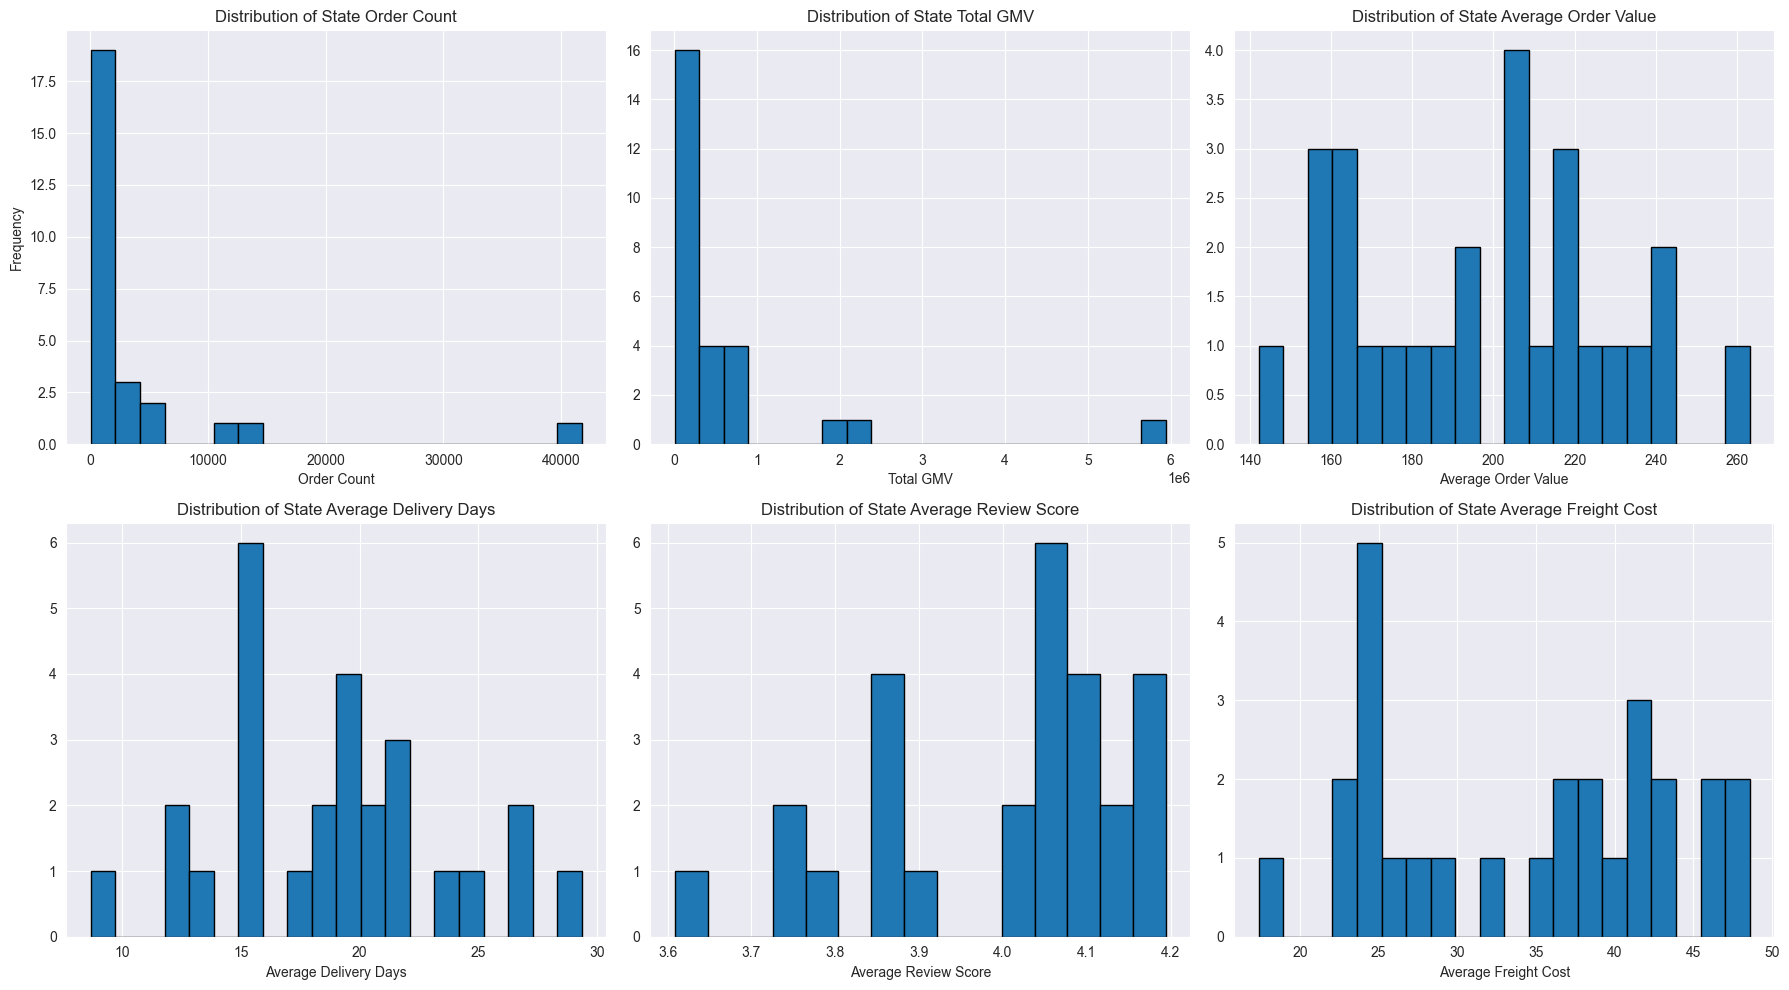

In [30]:
# plot the distribution of major state-level metrics
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# order count
axes[0, 0].hist(df_state["order_count"], bins=20, edgecolor="black")
axes[0, 0].set_title("Distribution of State Order Count")
axes[0, 0].set_xlabel("Order Count")
axes[0, 0].set_ylabel("Frequency")

# total GMV
axes[0, 1].hist(df_state["total_gmv"], bins=20, edgecolor="black")
axes[0, 1].set_title("Distribution of State Total GMV")
axes[0, 1].set_xlabel("Total GMV")

# average order value
axes[0, 2].hist(df_state["avg_order_value"], bins=20, edgecolor="black")
axes[0, 2].set_title("Distribution of State Average Order Value")
axes[0, 2].set_xlabel("Average Order Value")

# average delivery days
axes[1, 0].hist(df_state["avg_delivery_days"], bins=20, edgecolor="black")
axes[1, 0].set_title("Distribution of State Average Delivery Days")
axes[1, 0].set_xlabel("Average Delivery Days")

# average review score
axes[1, 1].hist(df_state["avg_review_score"], bins=15, edgecolor="black")
axes[1, 1].set_title("Distribution of State Average Review Score")
axes[1, 1].set_xlabel("Average Review Score")

# average freight cost
axes[1, 2].hist(df_state["avg_freight_cost"], bins=20, edgecolor="black")
axes[1, 2].set_title("Distribution of State Average Freight Cost")
axes[1, 2].set_xlabel("Average Freight Cost")

plt.tight_layout()
plt.show()

In [38]:
# summary statistics for key state-level variables

summary_stats_state = df_state[
    [
        "order_count",
        "customer_count",
        "total_gmv",
        "total_revenue",
        "avg_order_value",
        "avg_delivery_days",
        "avg_freight_cost",
        "delay_rate",
        "avg_review_score",
        "bad_review_rate"
    ]
].describe().T

summary_stats_state

,count,mean,std,min,25%,50%,75%,max
order_count,27.0,3683.000000,8.270438e+03,46.000000,381.500000,907.000000,2760.000000,4.174600e+04
customer_count,27.0,3683.000000,8.270438e+03,46.000000,381.500000,907.000000,2760.000000,4.174600e+04
total_gmv,27.0,588328.151852,1.190565e+06,10064.620000,84744.620000,186410.980000,482907.305000,5.939079e+06
total_revenue,27.0,504666.432963,1.043176e+06,7829.430000,69692.815000,156663.430000,407876.495000,5.218071e+06
avg_order_value,27.0,197.531735,3.112273e+01,142.267029,167.095850,202.703373,218.959508,2.630370e+02
avg_delivery_days,27.0,18.719604,4.906947e+00,8.703300,15.398250,19.223200,21.333600,2.934150e+01
avg_freight_cost,27.0,34.376477,9.188372e+00,17.372442,24.889408,36.442957,41.529984,4.859109e+01
delay_rate,27.0,8.831119,4.544027e+00,2.702700,4.991645,9.261500,11.279345,2.058111e+01
avg_review_score,27.0,4.003778,1.557410e-01,3.608700,3.871400,4.056200,4.106350,4.194000e+00
bad_review_rate,27.0,16.357928,3.864478e+00,7.462690,13.946670,15.000000,19.223895,2.391304e+01


In [39]:
# diagnostic check for customer-related state metrics

print("Number of states where order_count == customer_count:")
print((df_state["order_count"] == df_state["customer_count"]).sum())

print("\nUnique values in repeat_rate:")
print(df_state["repeat_rate"].unique())

Number of states where order_count == customer_count:
27

Unique values in repeat_rate:
[1.]


### State-level Numerical Distribution Analysis
The state-level distribution results show that regional performance is highly uneven across Brazil. Both `order_count` and `total_gmv` are strongly right-skewed, indicating that a small number of states contribute a disproportionately large share of orders and sales. By contrast, `avg_order_value` is more concentrated, suggesting that cross-state differences in transaction value are smaller than differences in sales scale. Logistics indicators such as `avg_delivery_days` and `avg_freight_cost` still show noticeable variation, while `avg_review_score` remains relatively stable around 4.0. In addition, repeat_rate is constant at 1.0 for all states, and customer_count is identical to order_count across all observations. This suggests that these customer-related indicators may have a metric-definition issue at the current aggregation level. Therefore, they will not be used as core variables in the following state-level comparison and business interpretation.

## 2.3 State Coverage Check

Before moving to state comparison, it is useful to confirm how many Brazilian states are covered in the dataset and whether regional sales are broadly distributed across the country. This step helps verify the geographic completeness of the analysis and provides basic context for later state-level ranking and map-based visualisation.

In [32]:
# check number of states and basic state coverage

print("Number of states covered in df_state:")
print(df_state["customer_state"].nunique())

print("\nState list:")
print(sorted(df_state["customer_state"].unique()))

print("\nOrder count by state:")
display(
    df_state[["customer_state", "order_count"]]
    .sort_values("order_count", ascending=False)
)

Number of states covered in df_state:
27

State list:
['AC', 'AL', 'AM', 'AP', 'BA', 'CE', 'DF', 'ES', 'GO', 'MA', 'MG', 'MS', 'MT', 'PA', 'PB', 'PE', 'PI', 'PR', 'RJ', 'RN', 'RO', 'RR', 'RS', 'SC', 'SE', 'SP', 'TO']

Order count by state:


,customer_state,order_count
25,SP,41746
18,RJ,12852
10,MG,11635
22,RS,5466
17,PR,5045
23,SC,3637
4,BA,3380
6,DF,2140
7,ES,2033
8,GO,2020


In [33]:
# optional: add state full names for easier interpretation

brazil_states = {
    "AC": "Acre",
    "AL": "Alagoas",
    "AP": "Amapa",
    "AM": "Amazonas",
    "BA": "Bahia",
    "CE": "Ceara",
    "DF": "Distrito Federal",
    "ES": "Espirito Santo",
    "GO": "Goias",
    "MA": "Maranhao",
    "MT": "Mato Grosso",
    "MS": "Mato Grosso do Sul",
    "MG": "Minas Gerais",
    "PA": "Para",
    "PB": "Paraiba",
    "PR": "Parana",
    "PE": "Pernambuco",
    "PI": "Piaui",
    "RJ": "Rio de Janeiro",
    "RN": "Rio Grande do Norte",
    "RS": "Rio Grande do Sul",
    "RO": "Rondonia",
    "RR": "Roraima",
    "SC": "Santa Catarina",
    "SP": "Sao Paulo",
    "SE": "Sergipe",
    "TO": "Tocantins"
}

df_state["state_name"] = df_state["customer_state"].map(brazil_states)

df_state[["customer_state", "state_name", "order_count"]].sort_values("order_count", ascending=False).head(10)

,customer_state,state_name,order_count
25,SP,Sao Paulo,41746
18,RJ,Rio de Janeiro,12852
10,MG,Minas Gerais,11635
22,RS,Rio Grande do Sul,5466
17,PR,Parana,5045
23,SC,Santa Catarina,3637
4,BA,Bahia,3380
6,DF,Distrito Federal,2140
7,ES,Espirito Santo,2033
8,GO,Goias,2020


### State Coverage Check
The dataset covers all 27 Brazilian states and federal units, which means the geographic analysis has full national coverage. This provides a complete basis for later ranking and regional comparison.

However, order volume is highly concentrated in a few leading states. SP ranks first by a large margin, followed by RJ and MG. After these three, the order count drops clearly, suggesting that most platform activity is concentrated in a limited number of major regional markets.

## 2.4 Preliminary Regional Concentration Check

Before moving to formal regional ranking analysis, it is useful to make a preliminary check of how concentrated regional sales are. This provides an early indication of whether platform revenue is broadly distributed across many states or strongly dependent on a small number of major regional markets.

In [34]:
# calculate state-level GMV share

df_concentration_state = df_state[["customer_state", "total_gmv"]].copy()
df_concentration_state["gmv_share_pct"] = (
    df_concentration_state["total_gmv"] / df_concentration_state["total_gmv"].sum() * 100
)

df_concentration_state = df_concentration_state.sort_values("total_gmv", ascending=False)

print("Top 10 states by GMV share:")
display(df_concentration_state.head(10))

print(f"GMV share of top 3 states: {df_concentration_state.head(3)['gmv_share_pct'].sum():.2f}%")
print(f"GMV share of top 5 states: {df_concentration_state.head(5)['gmv_share_pct'].sum():.2f}%")
print(f"GMV share of top 10 states: {df_concentration_state.head(10)['gmv_share_pct'].sum():.2f}%")

Top 10 states by GMV share:


,customer_state,total_gmv,gmv_share_pct
25,SP,5939079.38,37.388301
18,RJ,2135055.75,13.440822
10,MG,1860210.66,11.710589
22,RS,888633.27,5.594215
17,PR,803460.57,5.058027
4,BA,612431.53,3.855442
23,SC,611253.71,3.848027
6,DF,354560.90,2.232068
8,GO,350209.80,2.204677
7,ES,325288.44,2.047789


GMV share of top 3 states: 62.54%
GMV share of top 5 states: 73.19%
GMV share of top 10 states: 87.38%


### Preliminary Regional Concentration Check Analysis
The concentration results show that regional sales are heavily dominated by a few major states. SP alone contributes about 37.39% of total GMV, while SP, RJ, and MG together account for 62.54%.

This concentration becomes even clearer when looking at broader groups: the top 5 states contribute 73.19% of GMV, and the top 10 states contribute 87.38%. This indicates that the platform relies strongly on a small number of core regional markets.

## 3. Regional Sales Ranking Analysis

Regional sales ranking analysis aims to identify the strongest and weakest state-level markets from multiple business perspectives. Instead of looking at only one metric, this section compares states by GMV, order volume, and average order value. This helps distinguish states that are commercially dominant from those that may still have growth potential.

### 3.1 Top 10 States by GMV

GMV is one of the most direct indicators of regional business value. Analysing the top states by total GMV helps identify which regional markets contribute most strongly to the platform’s sales performance.

In [41]:
# rank states by total GMV

top10_gmv_states = (
    df_state[["customer_state", "total_gmv", "order_count", "avg_order_value", "avg_review_score"]]
    .sort_values("total_gmv", ascending=False)
    .head(10)
)

print("Top 10 states by total GMV")
display(top10_gmv_states)

Top 10 states by total GMV


,customer_state,total_gmv,order_count,avg_order_value,avg_review_score
25,SP,5939079.38,41746,142.267029,4.1756
18,RJ,2135055.75,12852,166.126342,3.8806
10,MG,1860210.66,11635,159.880590,4.1389
22,RS,888633.27,5466,162.574693,4.1363
17,PR,803460.57,5045,159.258785,4.1847
4,BA,612431.53,3380,181.192760,3.8622
23,SC,611253.71,3637,168.065359,4.0764
6,DF,354560.90,2140,165.682664,4.0693
8,GO,350209.80,2020,173.371188,4.0435
7,ES,325288.44,2033,160.004152,4.0394


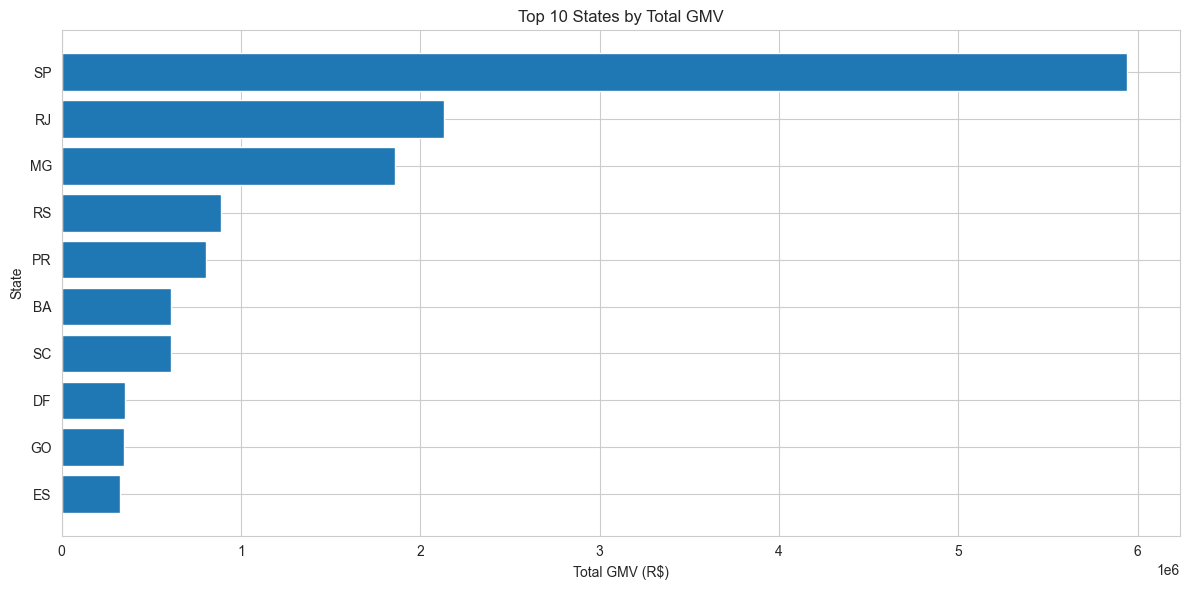

In [21]:
# visualise top 10 states by total GMV

plt.figure(figsize=(12, 6))
plt.barh(top10_gmv_states["customer_state"], top10_gmv_states["total_gmv"])
plt.xlabel("Total GMV (R$)")
plt.ylabel("State")
plt.title("Top 10 States by Total GMV")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Top 10 States by GMV Analysis
`SP` is by far the largest regional market in terms of GMV, contributing much more than any other state. `RJ` and `MG` rank second and third, but both remain far below `SP`, which shows a strong concentration of platform sales in a few leading markets.

Among the top 10 states, most also have relatively solid review scores, but `RJ` and `BA` stand out with lower satisfaction levels than the other major markets. This suggests that some high-value regional markets are commercially strong while still facing customer experience risk.

### 3.2 Top 10 States by Order Count

Order count reflects how frequently a state generates transactions and is an important indicator of market activity. While GMV highlights business value, order volume reveals the breadth of regional demand. Analysing the top states by order count helps compare market size with the GMV ranking above.

In [42]:
# rank states by order count

top10_orders_states = (
    df_state[["customer_state", "order_count", "total_gmv", "avg_review_score"]]
    .sort_values("order_count", ascending=False)
    .head(10)
)

print("Top 10 states by order count")
display(top10_orders_states)

Top 10 states by order count


,customer_state,order_count,total_gmv,avg_review_score
25,SP,41746,5939079.38,4.1756
18,RJ,12852,2135055.75,3.8806
10,MG,11635,1860210.66,4.1389
22,RS,5466,888633.27,4.1363
17,PR,5045,803460.57,4.1847
23,SC,3637,611253.71,4.0764
4,BA,3380,612431.53,3.8622
6,DF,2140,354560.90,4.0693
7,ES,2033,325288.44,4.0394
8,GO,2020,350209.80,4.0435


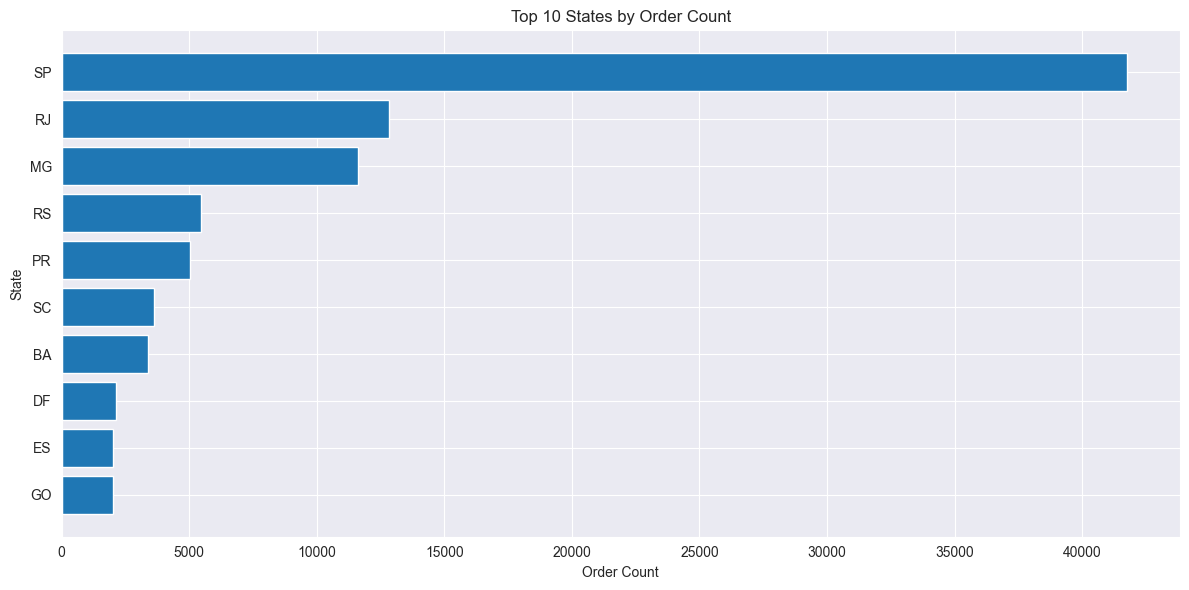

In [23]:
# visualise top 10 states by order count

plt.figure(figsize=(12, 6))
plt.barh(top10_orders_states["customer_state"], top10_orders_states["order_count"])
plt.xlabel("Order Count")
plt.ylabel("State")
plt.title("Top 10 States by Order Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Top 10 States by Order Count Analysis
The ranking by `order_count` is highly consistent with the earlier GMV ranking, which suggests that the platform's strongest regional markets are driven mainly by transaction volume rather than by a complete different spending pattern. `SP`, `RJ`, and `MG` remain the three dominant states, and `SP` is still for ahead of all others, showing the demand is heavily concentrated in a very small number of regional markets.

At this stage, order count is interpreted as a measure of market activity rather than customer breadth, because the current state-level `customer_count` metric has already shown a possible definition issue. For that reason, this section focuses on transaction intensity, which is more reliable here. The relatively lower review scores of `RJ` and `BA` are also worth noting, because some of the busiest states do not necessarily deliver the strongest customer experience.

### 3.3 Top 10 States by Average Order Value
Average order value reflects the spending value of each transaction rather than the overall market size. This step is added after GMV and `order-count` ranking because a large market **is not always a high-value market on a per-order basis.**

At this stage, a minimum order threshold is introduced before ranking. This is done to reduce distortion from very small states, where a few unusually expensive orders could create a misleadingly high average.

In [44]:
# rank states by average order value
# use a minimum order threshold to reduce the influence of very small states

min_orders = 100

top10_aov_states = (
    df_state[df_state["order_count"] >= min_orders]
    [["customer_state", "avg_order_value", "order_count", "total_gmv", "avg_review_score"]]
    .sort_values("avg_order_value", ascending=False)
    .head(10)
)

print(f"Top 10 states by average order value (min {min_orders} orders)")
display(top10_aov_states)

Top 10 states by average order value (min 100 orders)


,customer_state,avg_order_value,order_count,total_gmv,avg_review_score
14,PB,263.036959,536,140987.81,4.0133
1,AL,233.551864,413,96456.92,3.7640
20,RO,227.502055,253,57558.02,4.0562
13,PA,223.590410,975,218000.65,3.8527
26,TO,219.122929,280,61354.42,4.1047
16,PI,218.613131,495,108213.50,3.9139
19,RN,210.190825,485,101942.55,4.1023
24,SE,208.663771,350,73032.32,3.8006
5,CE,206.627463,1336,276054.29,3.8580
12,MT,205.524785,907,186410.98,4.1036


### Top 10 States by Average Order Value Analysis
The `avg_order_value` ranking is clearly different from the earlier `total_gmv` and `order_count` rankings, which shows that **high-spending states are not necessarily the largest markets**. States such as `PB`, `AL`, and `RO` appear at the top here, even though they were not leading states in overall sales scale. This suggests that some smaller regional markets may still have relatively stronger-order purchasing power.

At this stage, the `min_orders = 100` filter is important because it reduce extreme distortion from very small states. Even so, several top-ranked states still have relatively modest `order_count`, so these results should be treated as a **useful directional signal rather than a final judgement of regional value**. In addition, some high-`avg_order_value` states such as `AL`, `PA`, `CE`, and `SE` do not show equally strong `avg_review_score`, which reminds us that **higher spending per order does not automatically mean a better customer experience**.

### 3.4 Sales Concentration Analysis

### 3.4.1 GMV Share Concentration
After comparing regional rankings, the next step is to examine how much of the platform's sales is concentrated in a small number of states. This step is placed before formal inequality metrics because percentage share is more intuitive and helps build a direct business understanding of market dependence.

At this stage. `total_gmv` is used as the concentration base because it reflects total regional transaction value more directly than `order_count`. This makes it easier to judge whether the platform relies heavily on a few core markets.

In [46]:
# calculate GMV share by state

df_concentration_state = df_state[["customer_state", "total_gmv"]].copy()
df_concentration_state["gmv_share_pct"] = (
    df_concentration_state["total_gmv"] /
    df_concentration_state["total_gmv"].sum() * 100
)

df_concentration_state = df_concentration_state.sort_values(
    "total_gmv", ascending=False
).reset_index(drop=True)

print("Top 10 states by GMV share:")
display(df_concentration_state.head(10))
print(f"GMV share of top 3 states: {df_concentration_state.head(3)['gmv_share_pct'].sum():.2f}%")
print(f"GMV share of top 5 states: {df_concentration_state.head(5)['gmv_share_pct'].sum():.2f}%")
print(f"GMV share of top 10 states: {df_concentration_state.head(10)['gmv_share_pct'].sum():.2f}%")

Top 10 states by GMV share:


,customer_state,total_gmv,gmv_share_pct
0,SP,5939079.38,37.388301
1,RJ,2135055.75,13.440822
2,MG,1860210.66,11.710589
3,RS,888633.27,5.594215
4,PR,803460.57,5.058027
5,BA,612431.53,3.855442
6,SC,611253.71,3.848027
7,DF,354560.90,2.232068
8,GO,350209.80,2.204677
9,ES,325288.44,2.047789


GMV share of top 3 states: 62.54%
GMV share of top 5 states: 73.19%
GMV share of top 10 states: 87.38%


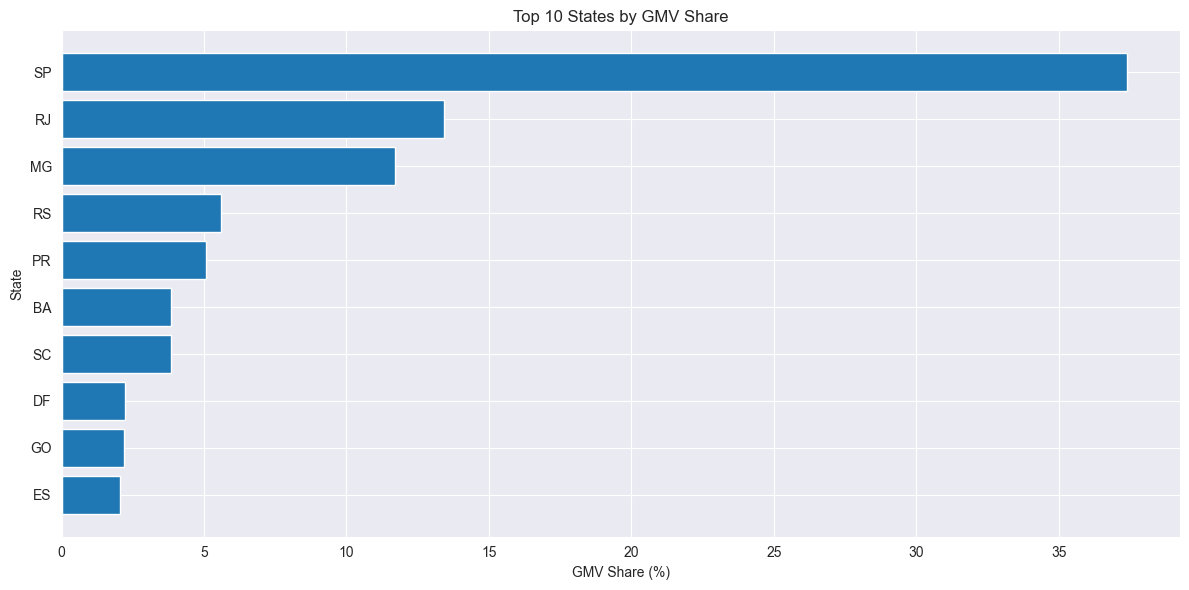

In [48]:
# visualise top 10 states by GMV share

top10_share_states = df_concentration_state.head(10)

plt.figure(figsize=(12, 6))
plt.barh(top10_share_states["customer_state"], top10_share_states["gmv_share_pct"])
plt.xlabel("GMV Share (%)")
plt.ylabel("State")
plt.title("Top 10 States by GMV Share")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### GMV Share Concentration Analysis
The `gmv_share_pct` results show that the platform's sales are **highly concentrated in a small number of states**, `SP` alone contribute about `37.39%` of total `GMV`, while the top 3 states (`SP`, `RJ`, and `MG`) together account for `62.54%`. This means the platform’s regional performance depends heavily on a very limited set of core markets.

This step is important because ranking alone shows who is largest, but `gmv_share_pct` shows **how dominant those leading states really are**. The fact that the top 10 states already contribute `87.38%` of total `GMV` suggests that most smaller states currently play only a marginal role in total sales. This concentration pattern will be useful later when interpreting regional segmentation and expansion priority.

### 3.4.2 Gini Coefficient and Lorenz Curve
The percentage-share view is useful, but it is still descriptive. To make the concentration pattern more formally interpretable, this step adds the `Gini coefficient` and the `Lorenz curve`, which are commonly used to measure inequality in distributions.

This step is included after the share calculation because the visual and percentage-based evidence should come first. In other words, the formal concentration metric is used here to validate and deepen the earlier observation, rather than replace it.

In [52]:
# calculate Lorenz curve inputs and Gini coefficient based on state-level total_gmv

df_lorenz = df_state[["customer_state", "total_gmv"]].copy()
df_lorenz = df_lorenz.sort_values("total_gmv", ascending=True).reset_index(drop=True)

df_lorenz["cum_gmv"] = df_lorenz["total_gmv"].cumsum()
df_lorenz["cum_gmv_pct"] = df_lorenz["cum_gmv"] / df_lorenz["total_gmv"].sum()
df_lorenz["cum_state_pct"] = (np.arange(1, len(df_lorenz) + 1)) / len(df_lorenz)

# include origin point for Lorenz curve
lorenz_x = np.insert(df_lorenz["cum_state_pct"].values, 0, 0)
lorenz_y = np.insert(df_lorenz["cum_gmv_pct"].values, 0, 0)

# calculate Gini coefficient
gini = 1 - 2 * np.trapezoid(lorenz_y, lorenz_x)

print(f"Gini coefficient of state-level GMV: {gini:.4f}")

Gini coefficient of state-level GMV: 0.7032


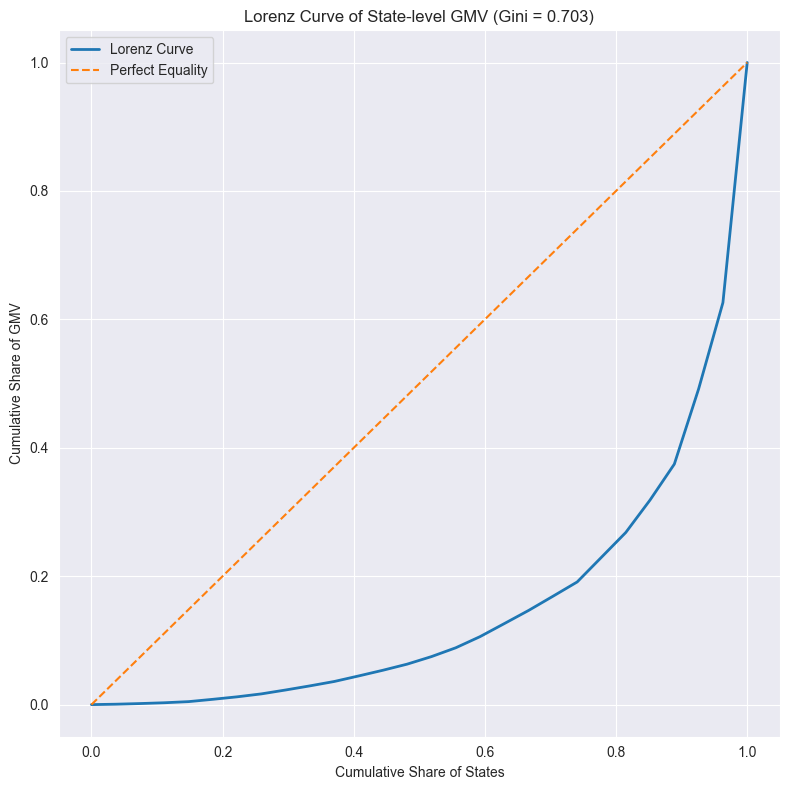

In [53]:
# plot Lorenz curve

plt.figure(figsize=(8, 8))
plt.plot(lorenz_x, lorenz_y, label="Lorenz Curve", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect Equality")

plt.xlabel("Cumulative Share of States")
plt.ylabel("Cumulative Share of GMV")
plt.title(f"Lorenz Curve of State-level GMV (Gini = {gini:.3f})")
plt.legend()
plt.tight_layout()
plt.show()

In [54]:
# identify core states contribution about 80% of GMV

df_core_states = df_concentration_state.copy()

df_core_states["cum_gmv_share_pct"] = df_core_states["gmv_share_pct"].cumsum()

core_states = df_core_states[df_core_states["cum_gmv_share_pct"] <= 80]

# make sure the first state crossing 80% is also included
if len(core_states) < len(df_core_states):
    core_states = df_core_states.iloc[:len(core_states) + 1]

print(f"Number of core states contributing about 80% of GMV: {len(core_states)}")
display(core_states[["customer_state", "total_gmv", "gmv_share_pct", "cum_gmv_share_pct"]])

Number of core states contributing about 80% of GMV: 7


,customer_state,total_gmv,gmv_share_pct,cum_gmv_share_pct
0,SP,5939079.38,37.388301,37.388301
1,RJ,2135055.75,13.440822,50.829123
2,MG,1860210.66,11.710589,62.539712
3,RS,888633.27,5.594215,68.133927
4,PR,803460.57,5.058027,73.191955
5,BA,612431.53,3.855442,77.047397
6,SC,611253.71,3.848027,80.895424


### Gini Coefficient and Lorenz Curve Analysis
The `Gini coefficient` of state-level `GMV` is `o.7032`, which indicates **a very high level of regional sales concentration**. This result confirms that the platform's revenue is not evenly distributed across Brazil, but is instead dominated by a small group of leading states. In other words, the earlier `gmv_share_pct` results are not just a ranking phenomenon; they reflect a broader structural imbalance in the regional market .

The shape of the `Lorenz curve` supports the same conclusion. The curve stays for below the line of perfect equality for most of the distribution, which means that a large share of states contributes only a small share of total `GMV`. This step is useful because it turns the earlier descriptive observation into a more formal concentration measure, making the later discussion of core markets and expansion priorities more convincing.

The `core_states` result shows that only `7` states contribute about `80%` of total `GMV`, which further confirms that **the platform’s sales base is highly concentrated rather than broadly distributed**. In particular, `SP`, `RJ`, and `MG` already account for more than `60%` of total `GMV`, while adding `RS`, `PR`, `BA`, and `SC` pushes the cumulative share above the `80%` threshold.

This step is useful because it translates the concentration pattern into a more operational definition of **core regional markets**. Instead of treating all states equally in later strategy design, the analysis now has a clearer basis for separating core markets from peripheral markets. This will be important later when discussing regional segmentation, logistics prioritisation, and market expansion.

## 4. Geographic Visualization

### 4.1 State-level Geographic Bubble Map
After the ranking and concentration analysis, the next step is to add a spatial view of regional performance. This step is useful because a ranking table shows **who is large**, but it does not show **where the major markets are located**.

At this stage, a `bubble map` is used instead of a full `choropleth map`. This choice is intentional: it avoids extra dependency on external `GeoJSON` filers while still preserving the main geographic pattern. The coordinates used here are approximate state-level reference points, so the map should be read as a **spatial summary**, not as a precise boundary map.

In [56]:
# create approximate state-level coordinates for geographic visualisation
# these points are used as spatial reference locations rather than exact state centroids

state_coords = {
    "AC": (-9.97, -67.81),      # Rio Branco
    "AL": (-9.66, -35.74),      # Maceio
    "AP": (0.03, -51.05),       # Macapa
    "AM": (-3.10, -60.02),      # Manaus
    "BA": (-12.97, -38.50),     # Salvador
    "CE": (-3.73, -38.52),      # Fortaleza
    "DF": (-15.79, -47.88),     # Brasilia
    "ES": (-20.32, -40.34),     # Vitoria
    "GO": (-16.68, -49.25),     # Goiania
    "MA": (-2.53, -44.30),      # Sap Luis
    "MT": (-15.60, -56.10),     # Cuiaba
    "MS": (-20.45, -54.62),     # Campo Grande
    "MG": (-19.92, -43.94),     # Belo Horizonte
    "PA": (-1.45, -48.49),      # Belem
    "PB": (-7.12, -34.86),      # Joao Pessoa
    "PR": (-25.43, -49.27),     # Curitiba
    "PE": (-8.05, -34.88),      # Recife
    "PI": (-5.09, -42.80),      # Teresina
    "RJ": (-22.91, -43.17),     # Rio de Janeiro
    "RN": (-5.79, -35.21),      # Natal
    "RS": (-30.03, -51.23),     # Porto Alegre
    "RO": (-8.76, -63.90),      # Porto Velho
    "RR": (2.82, -60.67),       # Boa Vista
    "SC": (-27.59, -48.55),     # Florianopolis
    "SP": (-23.55, -46.63),     # Sao Paulo
    "SE": (-10.91, -37.07),     # Aracaju
    "TO": (-10.18, -48.33)      # Palmas
}

df_state_map = df_state.copy()

df_state_map["lat"] = df_state_map["customer_state"].map(lambda x: state_coords[x][0])
df_state_map["lon"] = df_state_map["customer_state"].map(lambda x: state_coords[x][1])

# create scaled bubble size for clearer visual comparison
df_state_map["bubble_size"] = (
    df_state_map["total_gmv"] / df_state_map["total_gmv"].max() * 45
) + 8

df_state_map[["customer_state", "lat", "lon", "total_gmv", "avg_review_score"]].head()

,customer_state,lat,lon,total_gmv,avg_review_score
0,AC,-9.97,-67.81,19669.70,4.0750
1,AL,-9.66,-35.74,96456.92,3.7640
2,AM,-3.10,-60.02,27918.87,4.1781
3,AP,0.03,-51.05,16262.80,4.1940
4,BA,-12.97,-38.50,612431.53,3.8622


In [58]:
# visualise state-level GMV and review score on a geographic bubble map

fig = px.scatter_geo(
    df_state_map,
    lat="lat",
    lon="lon",
    size="bubble_size",
    color="avg_review_score",
    hover_name="customer_state",
    hover_data={
        "total_gmv": ":,.2f",
        "order_count": ":,",
        "avg_order_value": ":.2f",
        "avg_review_score": ":.2f",
        "lat": False,
        "lon": False,
        "bubble_size": False
    },
    title="Brazil State-level Market Distribution: GMV Size and Review Score",
    projection="natural earth"
)

fig.update_traces(textposition="top center")

fig.update_geos(
    scope="south america",
    center={"lat": -14.0, "lon": -52.0},
    projection_scale=4.2,
    showland=True,
    landcolor="rgb(240,240,240)",
    showcountries=True
)

fig.update_layout(height=700)
fig.show()

### State-level Geographic Bubble Map Analysis
The `bubble map` show that **the platform's strongest markets are spatially concentrated in the south-east in the south-east and nearby coastal regions of Brazil**. The largest bubble is clearly `SP`, while other important markets such as `RJ`, `MG`, `PR`, `RS`, and `SC` are also located in the more economically active eastern and southern parts of the country. This means the platform has national coverage, but its commercial strength is still concentrated in a limited regional corridor.

Compared with the strong size differences in `total_gmv`, the colour variation in `avg_review_score` is more moderate. This suggests that **regional differences in market scale are much stronger than regional differences in customer satisfaction**. At this stage, the map is useful not because it proves causality, but because it helps connect earlier ranking results with spatial structure, making the later discussion of logistics efficiency, market expansion, and regional clustering more grounded.

### 4.2 Top 20 Cities by GMV

After identifying the broad state-level market pattern, the next step is to move down to the city level. This step is necessary because `state-level` analysis may hide strong internal concentration, where a single major city contributes a large share of the state’s total sales.

At this stage, the analysis focuses on the top `20` cities by `total_gmv` rather than all cities. This is done to keep the comparison readable and to highlight the cities that matter most for regional business scale. The full `df_city` dataset is still retained for later analysis, so this filtering is only used for visual emphasis rather than data reduction.

In [59]:
# rank cities by total GMV
# keep only the top 20 cities for clearer comparison

top20_cities_gmv = (
    df_city[
        [
            "customer_state",
            "customer_city",
            "order_count",
            "total_gmv",
            "avg_order_value",
            "avg_review_score"
        ]
    ]
    .sort_values("total_gmv", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

print("Top 20 cities by total GMV")
display(top20_cities_gmv)

Top 20 cities by total GMV


,customer_state,customer_city,order_count,total_gmv,avg_order_value,avg_review_score
0,SP,sao paulo,15540,2178401.50,140.180277,4.1577
1,RJ,rio de janeiro,6882,1158078.33,168.276421,3.9094
2,MG,belo horizonte,2773,418157.72,150.796149,4.1103
3,DF,brasilia,2131,353636.60,165.948663,4.0696
4,PR,curitiba,1521,245388.19,161.333458,4.2045
5,RS,porto alegre,1379,224719.74,162.958477,4.0066
6,BA,salvador,1245,217174.14,174.437060,3.7196
7,SP,campinas,1444,213830.92,148.082355,4.0971
8,SP,guarulhos,1189,163769.92,137.737527,4.0791
9,RJ,niteroi,849,138378.24,162.989682,3.9583


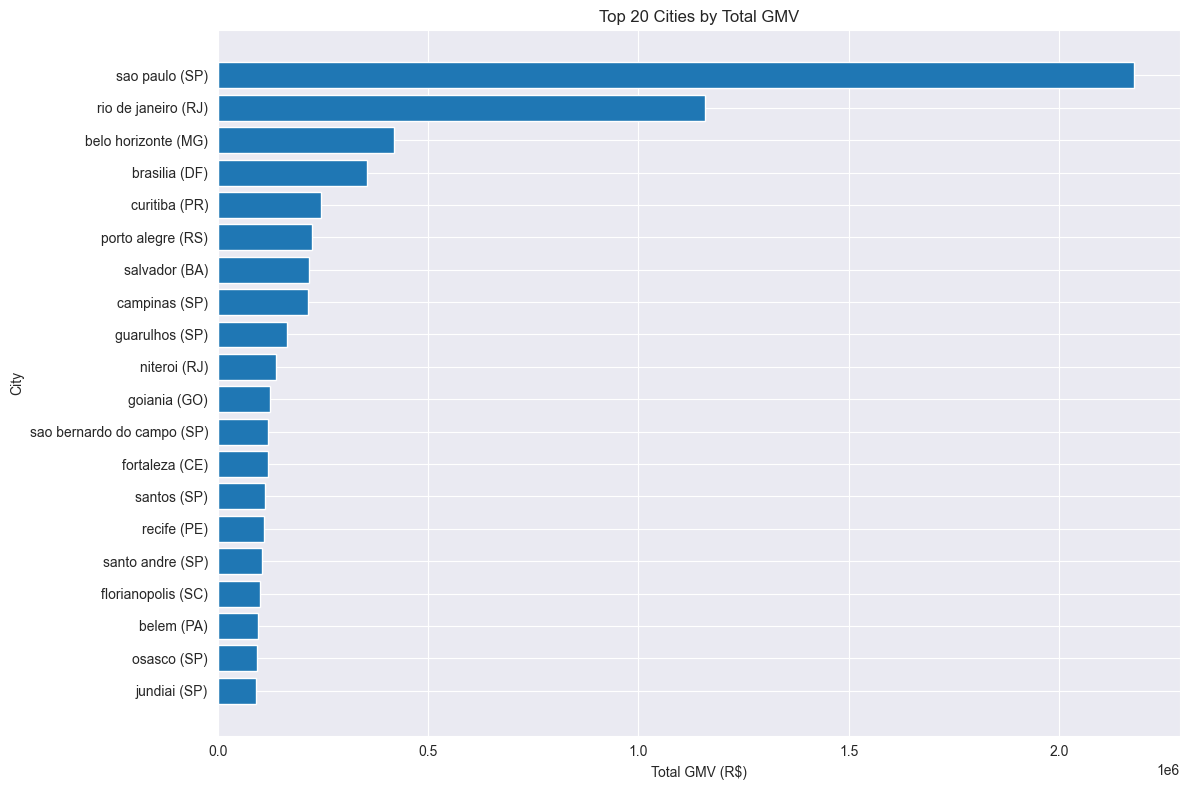

In [60]:
# visualise top 20 cities by total GMV

plt.figure(figsize=(12, 8))
plt.barh(
    top20_cities_gmv["customer_city"] + " (" + top20_cities_gmv["customer_state"] + ")",
    top20_cities_gmv["total_gmv"]
)

plt.xlabel("Total GMV (R$)")
plt.ylabel("City")
plt.title("Top 20 Cities by Total GMV")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Top 20 Cities by GMV Analysis
The city-level ranking shows that `total_gmv` is **even more concentrated at the urban level than at the state level**. `sao paulo` is far ahead of all other cities, and `rio de janeiro` is the only city that remains relatively close, while the gap to the rest becomes much larger after the top two. This suggests that regional sales are not only concentrated in a few states, but are also heavily anchored in a very small number of major metropolitan markets.

This step is important because `state-level` strength does not necessarily mean that sales are evenly distributed inside the state. The repeated appearance of cities from `SP` and `RJ` shows that **intra-state concentration is also strong**, especially in the most developed regions. At the same time, cities such as `brasilia`, `curitiba`, `porto alegre`, and `salvador` still stand out, which means the platform’s urban sales structure is concentrated but not completely one-dimensional.

### 4.3 City-level Concentration Within Top States

After identifying the top cities by `total_gmv`, the next step is to examine whether strong states are supported by a broad city base or dominated by only one or two major cities. This step is useful because a high-performing state may still be internally unbalanced.

At this stage, the analysis focuses on the top `5` states by `total_gmv` rather than all states. This is done to keep the comparison interpretable and to concentrate on the regional markets that contribute most to total platform sales. The goal here is not to describe every state, but to test whether **state-level strength is internally diversified or highly concentrated**.

In [61]:
# identify top 5 states by total GMV
# then examine city-level GMV concentration inside each of these states

top5_states = (
    df_state.sort_values("total_gmv", ascending=False)
    .head(5)["customer_state"]
    .tolist()
)

df_city_top5_states = df_city[df_city["customer_state"].isin(top5_states)].copy()

# rank cities within each top state
top5_state_city_gmv = (
    df_city_top5_states[
        ["customer_state", "customer_city", "order_count", "total_gmv", "avg_order_value", "avg_review_score"]
    ]
    .sort_values(["customer_state", "total_gmv"], ascending=[True, False])
)

print("Top 5 states:")
print(top5_states)

print("\nTop cities within top 5 states by GMV:")
display(top5_state_city_gmv.groupby("customer_state").head(5))

Top 5 states:
['SP', 'RJ', 'MG', 'RS', 'PR']

Top cities within top 5 states by GMV:


,customer_state,customer_city,order_count,total_gmv,avg_order_value,avg_review_score
2,MG,belo horizonte,2773,418157.72,150.796149,4.1103
23,MG,juiz de fora,427,75914.94,177.786745,4.2090
33,MG,contagem,426,58614.17,137.591948,3.9507
35,MG,uberlandia,374,56975.46,152.340802,4.2661
55,MG,divinopolis,137,38792.24,283.155036,4.1241
4,PR,curitiba,1521,245388.19,161.333458,4.2045
38,PR,londrina,306,53286.37,174.138464,4.1667
43,PR,maringa,271,44985.80,165.999262,4.0896
77,PR,cascavel,148,27649.61,186.821689,4.1096
102,PR,ponta grossa,143,22152.28,154.911049,4.3916


In [62]:
# calculate how much the top city contributes within each top state

state_total_city_gmv = (
    df_city_top5_states.groupby("customer_state")["total_gmv"]
    .sum()
    .reset_index(name="state_city_total_gmv")
)

top_city_each_state = (
    df_city_top5_states.sort_values(["customer_state", "total_gmv"], ascending=[True, False])
    .groupby("customer_state")
    .head(1)
    [["customer_state", "customer_city", "total_gmv"]]
    .rename(columns={
        "customer_city": "top_city",
        "total_gmv": "top_city_gmv"
    })
)

state_city_concentration = state_total_city_gmv.merge(
    top_city_each_state,
    on="customer_state",
    how="left"
)

state_city_concentration["top_city_share_pct"] = (
    state_city_concentration["top_city_gmv"] /
    state_city_concentration["state_city_total_gmv"] * 100
)

state_city_concentration = state_city_concentration.sort_values(
    "top_city_share_pct", ascending=False
).reset_index(drop=True)

print("Top-city concentration within top 5 states:")
display(state_city_concentration)

Top-city concentration within top 5 states:


,customer_state,state_city_total_gmv,top_city,top_city_gmv,top_city_share_pct
0,RJ,2135055.75,rio de janeiro,1158078.33,54.241128
1,SP,5939079.38,sao paulo,2178401.50,36.679111
2,PR,803460.57,curitiba,245388.19,30.541410
3,RS,888633.27,porto alegre,224719.74,25.288243
4,MG,1860210.66,belo horizonte,418157.72,22.479052


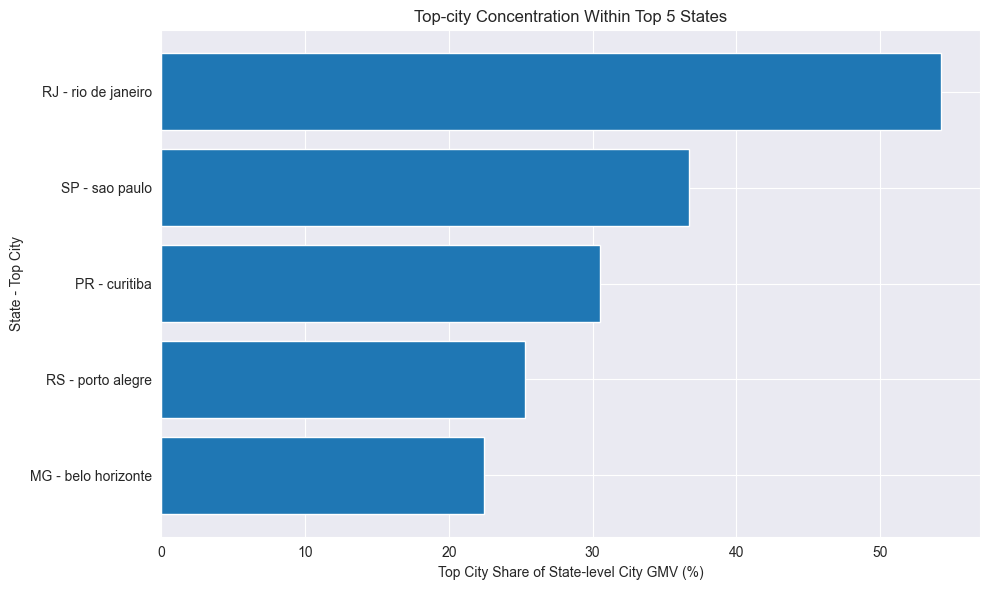

In [63]:
# visualise top-city share within each top state

plt.figure(figsize=(10, 6))
plt.barh(
    state_city_concentration["customer_state"] + " - " + state_city_concentration["top_city"],
    state_city_concentration["top_city_share_pct"]
)

plt.xlabel("Top City Share of State-level City GMV (%)")
plt.ylabel("State - Top City")
plt.title("Top-city Concentration Within Top 5 States")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### City-level Concentration Within Top States Analysis
The `top_city_share_pct` results show that **strong states do not all have the same internal market structure**. `RJ` is the most concentrated case, where `rio de janeiro` alone contributes about `54.24%` of the state’s city-level `GMV`. By contrast, `MG` is much less concentrated, with `belo horizonte` contributing only about `22.48%`. This means some leading states depend heavily on one dominant city, while others are supported by a broader urban base.

This step is important because high `state-level` performance can come from very different internal patterns. A state like `RJ` may look strong overall, but its sales base is more exposed to single-city dependence. In contrast, `MG`, `RS`, and `PR` appear relatively more distributed across multiple cities, which suggests a **more balanced intra-state market structure**. This distinction will be useful later when discussing regional resilience, logistics layout, and city-focused expansion strategy.

## 5. Regional Segmentation Analysis

### 5.1 Clustering Feature Selection and Preparation

After the ranking, concentration, and geographic visualisation steps, the next task is to test whether states can be grouped into a small number of regional types. This step is useful because individual rankings show isolated performance, while clustering helps reveal **multi-dimensional regional patterns**.

At this stage, the clustering input is limited to a small set of interpretable `state-level` variables: `total_gmv`, `avg_order_value`, `avg_review_score`, `avg_delivery_days`, `delay_rate`, and `avg_freight_cost`. Variables such as `repeat_rate` are not included because they showed no effective variation, and `customer_count` is not treated as a core feature because its current definition may overlap too strongly with `order_count`. Standardisation is used before clustering because these variables are measured on very different scales, and without scaling, large-value metrics such as `total_gmv` would dominate the segmentation result.

In [64]:
# select clustering features from the state-level dataset
# keep only variables that are interpretable and have usable variation

cluster_features = [
    "total_gmv",
    "avg_order_value",
    "avg_review_score",
    "avg_delivery_days",
    "delay_rate",
    "avg_freight_cost"
]

df_cluster_base = df_state[["customer_state"] + cluster_features].copy()

print("Clustering feature dataset shape:")
print(df_cluster_base.shape)

print("\nSelected clustering features:")
print(cluster_features)

display(df_cluster_base.head())

Clustering feature dataset shape:
(27, 7)

Selected clustering features:
['total_gmv', 'avg_order_value', 'avg_review_score', 'avg_delivery_days', 'delay_rate', 'avg_freight_cost']


,customer_state,total_gmv,avg_order_value,avg_review_score,avg_delivery_days,delay_rate,avg_freight_cost
0,AC,19669.70,242.835802,4.0750,21.0000,3.70370,45.515432
1,AL,96456.92,233.551864,3.7640,24.4525,20.58111,38.628357
2,AM,27918.87,188.641014,4.1781,26.3151,2.70270,37.203581
3,AP,16262.80,239.158824,4.1940,27.1791,2.94118,41.007353
4,BA,612431.53,181.192760,3.8622,19.2929,11.77515,29.806459


In [65]:
# standardise clustering features
# this step is necessary because the variables are on very different numeric scales

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_cluster_base[cluster_features])

df_cluster_scaled = pd.DataFrame(
    X_scaled,
    columns=cluster_features,
    index=df_cluster_base.index
)

df_cluster_scaled["customer_state"] = df_cluster_base["customer_state"]

print("Scaled feature matrix shape:")
print(X_scaled.shape)

display(df_cluster_scaled.head())

Scaled feature matrix shape:
(27, 6)


,total_gmv,avg_order_value,avg_review_score,avg_delivery_days,delay_rate,avg_freight_cost,customer_state
0,-0.486736,1.483388,0.466023,0.473581,-1.149881,1.235382,AC
1,-0.421011,1.179405,-1.568922,1.190578,2.635068,0.471561,AL
2,-0.479675,-0.291108,1.140631,1.577393,-1.374367,0.313544,AM
3,-0.489652,1.362993,1.244668,1.756824,-1.320885,0.735407,AP
4,0.020631,-0.534986,-0.926376,0.119059,0.660232,-0.506844,BA


In [66]:
# compare original feature ranges before clustering

feature_summary = df_cluster_base[cluster_features].agg(["min", "max", "mean", "std"]).T
display(feature_summary)

,min,max,mean,std
total_gmv,10064.620000,5.939079e+06,588328.151852,1.190565e+06
avg_order_value,142.267029,2.630370e+02,197.531735,3.112273e+01
avg_review_score,3.608700,4.194000e+00,4.003778,1.557410e-01
avg_delivery_days,8.703300,2.934150e+01,18.719604,4.906947e+00
delay_rate,2.702700,2.058111e+01,8.831119,4.544027e+00
avg_freight_cost,17.372442,4.859109e+01,34.376477,9.188372e+00


### Clustering Feature Selection and Preparation Analysis
The selected `cluster_features` cover **three key regional dimensions at the same time**: market scale (`total_gmv`), customer value (`avg_order_value`), and service performance (`avg_review_score`, `avg_delivery_days`, `delay_rate`, `avg_freight_cost`). This is important because clustering should not be driven by only one business perspective. Otherwise, the result would become a disguised sales ranking rather than a real regional segmentation.

The `feature_summary` also shows why `StandardScaler` is necessary. The numeric range of `total_gmv` is far larger than the other variables, so without scaling, it would dominate the distance calculation and weaken the contribution of service and satisfaction indicators. At this stage, variables such as `repeat_rate` are excluded because they showed no useful variation, and `customer_count` is not treated as a core feature because its current definition may overlap too strongly with transaction volume. This keeps the clustering input **more stable, more interpretable, and less distorted by metric-definition issues**.

### 5.2 Choosing the Number of Clusters
Before running `KMeans`, the number of clusters must be chosen carefully. This step is necessary because clustering is sensitive to the choice of `K`, and different values may produce very different regional structures.

At this stage, the analysis combines three evaluation perspectives: `inertia`, `silhouette_score`, and `davies_bouldin_score`. This is done because no single metric is sufficient on its own. The goal is not to find a mathematically perfect `K`, but to identify a value that is **reasonably stable, interpretable, and useful for later business profiling**.

In [67]:
# evaluate different numbers of clusters
# use multiple metrics to avoid relying on a single criterion

from sklearn.metrics import silhouette_score, davies_bouldin_score

k_values = range(2, 8)

evaluation_results = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)

    evaluation_results.append({
        "k": k,
        "inertia": kmeans.inertia_,
        "silhouette_score": silhouette_score(X_scaled, labels),
        "davies_bouldin_score": davies_bouldin_score(X_scaled, labels)
    })

df_k_eval = pd.DataFrame(evaluation_results)

print("Cluster evaluation results:")
display(df_k_eval)

Cluster evaluation results:


,k,inertia,silhouette_score,davies_bouldin_score
0,2,92.339984,0.371618,0.970798
1,3,63.061109,0.372451,0.935146
2,4,42.619412,0.385897,0.731482
3,5,36.001468,0.356295,0.761678
4,6,29.975199,0.288010,0.927028
5,7,24.838985,0.286885,0.818374


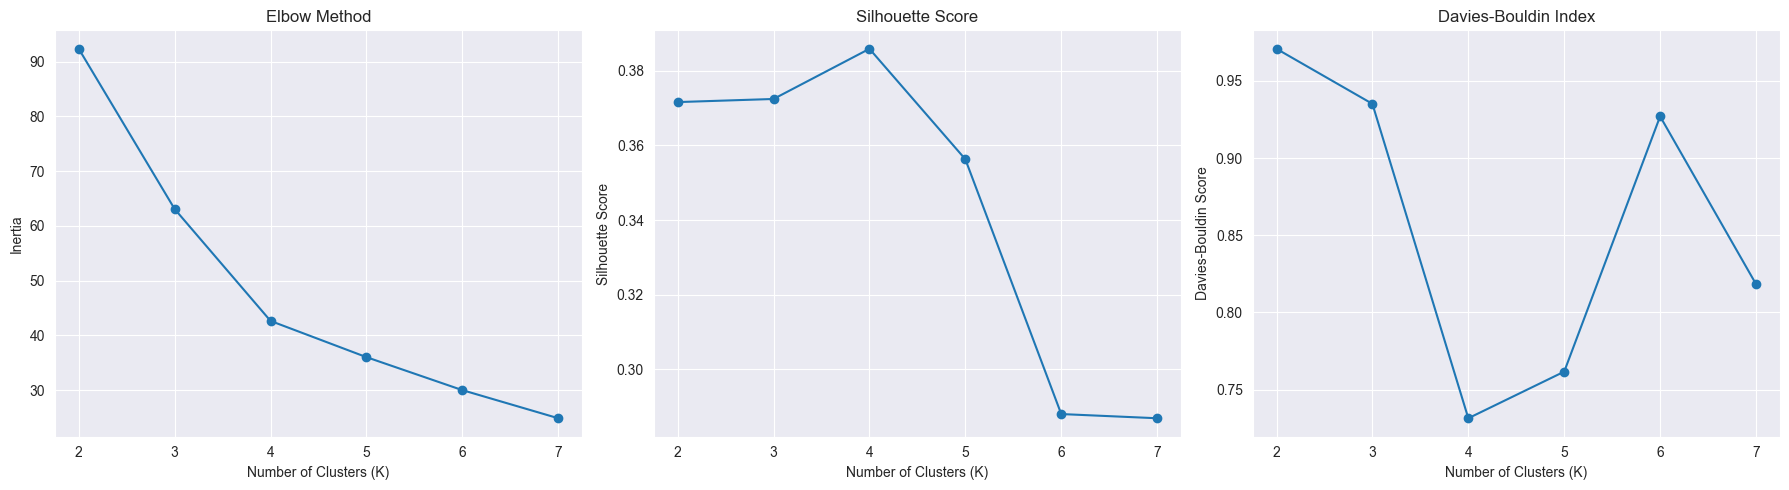

In [68]:
# visualise cluster evaluation metrics

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# inertia
axes[0].plot(df_k_eval["k"], df_k_eval["inertia"], marker="o")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia")

# silhouette score
axes[1].plot(df_k_eval["k"], df_k_eval["silhouette_score"], marker="o")
axes[1].set_title("Silhouette Score")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")

# davies-bouldin score
axes[2].plot(df_k_eval["k"], df_k_eval["davies_bouldin_score"], marker="o")
axes[2].set_title("Davies-Bouldin Index")
axes[2].set_xlabel("Number of Clusters (K)")
axes[2].set_ylabel("Davies-Bouldin Score")

plt.tight_layout()
plt.show()

In [69]:
# highlight the best values from each metric

best_silhouette_k = df_k_eval.loc[df_k_eval["silhouette_score"].idxmax(), "k"]
best_db_k = df_k_eval.loc[df_k_eval["davies_bouldin_score"].idxmin(), "k"]

print(f"Best K by silhouette_score: {best_silhouette_k}")
print(f"Best K by davies_bouldin_score: {best_db_k}")

Best K by silhouette_score: 4
Best K by davies_bouldin_score: 4


### Choosing the Number of Clusters Analysis
The evaluation results suggest that `K = 4` is the most reasonable choice for this dataset. Both `silhouette_score` and `davies_bouldin_score` point to `4` as the best-performing option, which means this solution achieves a relatively better balance between **cluster separation** and **within-cluster compactness**. At the same time, the `inertia` curve shows a visible slowing of improvement after `K = 4`, so adding more clusters would reduce variance further but with weaker practical gain.

This step is important because the goal of clustering is not to maximise mathematical complexity, but to produce a structure that is **stable enough to trust and simple enough to interpret**. In a dataset with only `27` states, choosing too many clusters would risk over-segmentation and make the later business profiling much less meaningful. For that reason, `K = 4` is adopted here as a compromise between statistical quality and regional interpretability.

### 5.3 State-level Clustering with KMeans
After choosing `K = 4`, the next step is to run `KMeans` and assign each state to a cluster. This step turns the earlier feature preparation into an actual regional segmentation result.

At this stage, the clustering labels are treated as **intermediate analytical groups rather than final business labels**. In other words, the model first identifies statistical similarity, and only after that will the clusters be interpreted in business terms. This separation is important because a numeric `cluster` is not automatically meaningful until its underlying profile is examined.

In [70]:
# run KMeans with the selected number of clusters
# assign cluster labels back to the state-level dataset

optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

df_state_clustered = df_state.copy()
df_state_clustered["cluster"] = cluster_labels

print("Cluster assignment by state:")
display(
    df_state_clustered[
        ["customer_state", "cluster", "total_gmv", "avg_order_value",
         "avg_review_score", "avg_delivery_days", "delay_rate", "avg_freight_cost"]
    ].sort_values(["cluster", "total_gmv"], ascending=[True, False])
)

Cluster assignment by state:


,customer_state,cluster,total_gmv,avg_order_value,avg_review_score,avg_delivery_days,delay_rate,avg_freight_cost
18,RJ,0,2135055.75,166.126342,3.8806,15.2440,11.68690,23.944250
10,MG,0,1860210.66,159.880590,4.1389,11.9439,4.46927,23.450920
22,RS,0,888633.27,162.574693,4.1363,15.2548,5.96414,24.951491
17,PR,0,803460.57,159.258785,4.1847,11.9390,3.94450,23.596681
23,SC,0,611253.71,168.065359,4.0764,14.9198,8.02859,24.827325
6,DF,0,354560.90,165.682664,4.0693,12.9115,5.51402,23.834691
8,GO,0,350209.80,173.371188,4.0435,15.5480,6.43564,26.491230
7,ES,0,325288.44,160.004152,4.0394,15.7266,10.52632,24.569104
11,MS,0,136560.11,190.993161,4.1080,15.5417,9.51049,26.956909
15,PE,1,322769.11,195.380817,4.0086,18.3794,9.26150,36.015940


In [71]:
# check how many states fall into each cluster

cluster_counts = (
    df_state_clustered["cluster"]
    .value_counts()
    .sort_index()
    .reset_index()
)

cluster_counts.columns = ["cluster", "state_count"]

print("Number of states in each cluster:")
display(cluster_counts)

Number of states in each cluster:


,cluster,state_count
0,0,9
1,1,9
2,2,8
3,3,1


In [72]:
# inspect cluster centers in standardised space

df_cluster_centers_scaled = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=cluster_features
)

df_cluster_centers_scaled["cluster"] = range(optimal_k)

print("Cluster centers in scaled feature space:")
display(df_cluster_centers_scaled)

Cluster centers in scaled feature space:


,total_gmv,avg_order_value,avg_review_score,avg_delivery_days,delay_rate,avg_freight_cost,cluster
0,0.206403,-0.988941,0.467550,-0.910242,-0.333905,-1.069208,0
1,-0.414662,0.777129,0.582929,0.435872,-0.584851,0.727069,1
2,-0.338197,0.464479,-1.322323,0.793683,1.158745,0.620638,2
3,4.579910,-1.809528,1.124273,-2.080134,-1.001154,-1.885856,3


In [73]:
# convert cluster centers back to original scale for business interpretation

cluster_centers_original = scaler.inverse_transform(kmeans.cluster_centers_)

df_cluster_centers = pd.DataFrame(
    cluster_centers_original,
    columns=cluster_features
)

df_cluster_centers["cluster"] = range(optimal_k)

print("Cluster centers in original feature scale:")
display(df_cluster_centers.round(2))

Cluster centers in original feature scale:


,total_gmv,avg_order_value,avg_review_score,avg_delivery_days,delay_rate,avg_freight_cost,cluster
0,829470.36,167.33,4.08,14.34,7.34,24.74,0
1,103874.92,221.27,4.09,20.82,6.22,40.93,1
2,193209.16,211.72,3.80,22.54,14.00,39.97,2
3,5939079.38,142.27,4.18,8.70,4.37,17.37,3


### State-level Clustering with KMeans Analysis
The `KMeans` result shows that the `27` states are not grouped into equally similar market types. Instead, the clustering already reveals **clear structural differences in regional profiles**. `cluster 0`, `cluster 1`, and `cluster 2` contain multiple states with shared patterns, while `cluster 3` contains only `1` state, which suggests that at least one regional market is statistically far more distinctive than the others.

This is an important reminder that clustering does not always produce balanced groups. A singleton `cluster` is not automatically a problem; in this case, it likely reflects an **extreme outlier market** rather than a modelling error. At this stage, the `cluster` labels should still be treated as analytical placeholders, not final business categories. The next step is therefore to compare the `cluster centers` in business terms and decide what each group actually represents.

### 5.4 Cluster Profiling and Business Naming

After obtaining the `cluster` assignments, the next step is to profile each group in business terms. This step is necessary because numeric `cluster` labels are only statistical outputs; they do not become useful until they are translated into interpretable regional types.

At this stage, the naming process is done manually rather than automatically. This is intentional: `KMeans` identifies similarity, but **business meaning still requires human interpretation**. The naming therefore depends on the relative pattern of `total_gmv`, `avg_order_value`, `avg_review_score`, `avg_delivery_days`, `delay_rate`, and `avg_freight_cost`, rather than on any single metric alone.

In [75]:
# build a cluster profiling table in original business scale

cluster_profile = (
    df_state_clustered.groupby("cluster")
    .agg(
        state_count=("customer_state", "count"),
        total_gmv=("total_gmv", "mean"),
        avg_order_value=("avg_order_value", "mean"),
        avg_review_score=("avg_review_score", "mean"),
        avg_delivery_days=("avg_delivery_days", "mean"),
        delay_rate=("delay_rate", "mean"),
        avg_freight_cost=("avg_freight_cost", "mean")
    )
    .reset_index()
)

print("Cluster profile summary:")
display(cluster_profile.round(2))

Cluster profile summary:


,cluster,state_count,total_gmv,avg_order_value,avg_review_score,avg_delivery_days,delay_rate,avg_freight_cost
0,0,9,829470.36,167.33,4.08,14.34,7.34,24.74
1,1,9,103874.92,221.27,4.09,20.82,6.22,40.93
2,2,8,193209.16,211.72,3.80,22.54,14.00,39.97
3,3,1,5939079.38,142.27,4.18,8.70,4.37,17.37


In [76]:
# inspect state membership in each cluster

cluster_members = (
    df_state_clustered.groupby("cluster")["customer_state"]
    .apply(list)
    .reset_index(name="states")
)

print("Cluster members:")
display(cluster_members)

Cluster members:


,cluster,states
0,0,"[DF, ES, GO, MG, MS, PR, RJ, RS, SC]"
1,1,"[AC, AM, AP, MT, PB, PE, RN, RO, TO]"
2,2,"[AL, BA, CE, MA, PA, PI, RR, SE]"
3,3,[SP]


In [77]:
# assign business names to clusters based on the observed profile pattern

cluster_name_map = {
    0: "Balanced Core Markets",
    1: "High-AOV Potential Markets",
    2: "Logistics-Stressed Markets",
    3: "Super Core Outlier Market"
}

df_state_clustered["cluster_name"] = df_state_clustered["cluster"].map(cluster_name_map)
cluster_profile["cluster_name"] = cluster_profile["cluster"].map(cluster_name_map)
cluster_members["cluster_name"] = cluster_members["cluster"].map(cluster_name_map)

print("Cluster profile with business names:")
display(cluster_profile.round(2))

print("\nCluster members with business names:")
display(cluster_members)

Cluster profile with business names:


,cluster,state_count,total_gmv,avg_order_value,avg_review_score,avg_delivery_days,delay_rate,avg_freight_cost,cluster_name
0,0,9,829470.36,167.33,4.08,14.34,7.34,24.74,Balanced Core Markets
1,1,9,103874.92,221.27,4.09,20.82,6.22,40.93,High-AOV Potential Markets
2,2,8,193209.16,211.72,3.80,22.54,14.00,39.97,Logistics-Stressed Markets
3,3,1,5939079.38,142.27,4.18,8.70,4.37,17.37,Super Core Outlier Market



Cluster members with business names:


,cluster,states,cluster_name
0,0,"[DF, ES, GO, MG, MS, PR, RJ, RS, SC]",Balanced Core Markets
1,1,"[AC, AM, AP, MT, PB, PE, RN, RO, TO]",High-AOV Potential Markets
2,2,"[AL, BA, CE, MA, PA, PI, RR, SE]",Logistics-Stressed Markets
3,3,[SP],Super Core Outlier Market


In [78]:
# reorder columns for easier reporting

cluster_profile = cluster_profile[
    [
        "cluster",
        "cluster_name",
        "state_count",
        "total_gmv",
        "avg_order_value",
        "avg_review_score",
        "avg_delivery_days",
        "delay_rate",
        "avg_freight_cost"
    ]
]

display(cluster_profile.round(2))

,cluster,cluster_name,state_count,total_gmv,avg_order_value,avg_review_score,avg_delivery_days,delay_rate,avg_freight_cost
0,0,Balanced Core Markets,9,829470.36,167.33,4.08,14.34,7.34,24.74
1,1,High-AOV Potential Markets,9,103874.92,221.27,4.09,20.82,6.22,40.93
2,2,Logistics-Stressed Markets,8,193209.16,211.72,3.80,22.54,14.00,39.97
3,3,Super Core Outlier Market,1,5939079.38,142.27,4.18,8.70,4.37,17.37


### Cluster Profiling and Business Naming Analysis
The `cluster_profile` results show that the four groups are **meaningfully different in both market scale and operating conditions**. `cluster 3` is clearly the most distinctive case: it contains only `SP`, with extremely high `total_gmv`, the lowest `avg_order_value`, the highest `avg_review_score`, and the strongest delivery performance. This means it is more appropriate to interpret this group as a **super core outlier market** rather than as a normal peer cluster.

By contrast, `cluster 0` contains the main balanced core states such as `RJ`, `MG`, `PR`, `RS`, and `SC`. This group combines relatively strong `total_gmv`, stable `avg_review_score`, and better logistics conditions, so it represents the platform’s **broad high-performing regional base**. `cluster 1` has the highest `avg_order_value` among the multi-state groups, but much smaller `total_gmv`, which supports the label **high-AOV potential markets**. `cluster 2` shows a different pattern: although its `avg_order_value` is also relatively high, it has the lowest `avg_review_score`, the slowest `avg_delivery_days`, and the highest `delay_rate`, so its main constraint appears to be **service and logistics pressure rather than demand value alone**.

### 5.5 Cluster Visualisation

After assigning business names to the `cluster` groups, the next step is to visualise them in a two-dimensional business space. This step is useful because the segmentation logic is easier to interpret when the clusters can be seen as relative positions rather than only as tables.

At this stage, the plot uses `total_gmv` and `avg_review_score` as the main axes, while `order_count` is used as bubble size. This choice is intentional: `total_gmv` captures overall regional value, `avg_review_score` reflects customer experience, and `order_count` adds a sense of market activity. The goal is not to display every feature at once, but to create a **clear visual summary of the cluster structure**.

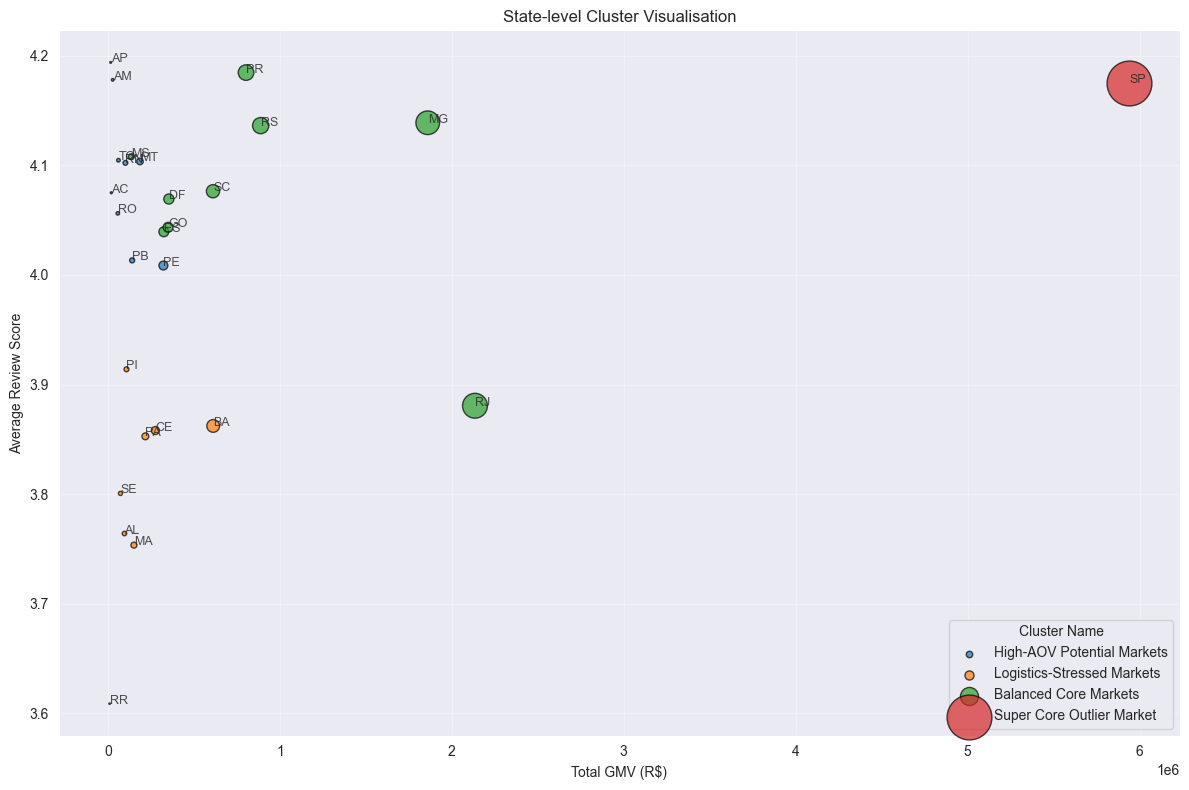

In [79]:
# visualise state-level clusters in a business interpretation space

plt.figure(figsize=(12, 8))

for cluster_name in df_state_clustered["cluster_name"].unique():
    subset = df_state_clustered[df_state_clustered["cluster_name"] == cluster_name]

    plt.scatter(
        subset["total_gmv"],
        subset["avg_review_score"],
        s=subset["order_count"] / 40,
        alpha=0.7,
        label=cluster_name,
        edgecolors="black"
    )

    for _, row in subset.iterrows():
        plt.annotate(
            row["customer_state"],
            (row["total_gmv"], row["avg_review_score"]),
            fontsize=9,
            alpha=0.8
        )

plt.xlabel("Total GMV (R$)")
plt.ylabel("Average Review Score")
plt.title("State-level Cluster Visualisation")
plt.legend(title="Cluster Name")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

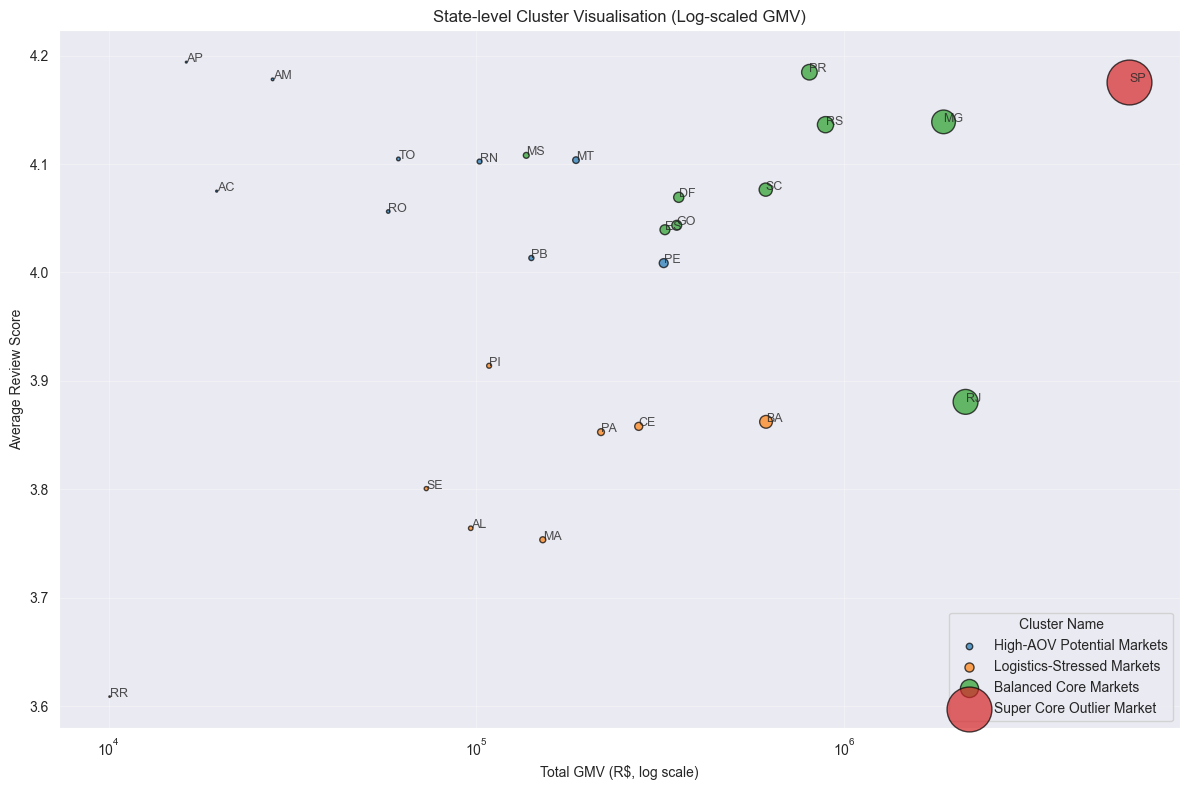

In [80]:
# optional: use log scale on x-axis to reduce the dominance of the outlier market

plt.figure(figsize=(12, 8))

for cluster_name in df_state_clustered["cluster_name"].unique():
    subset = df_state_clustered[df_state_clustered["cluster_name"] == cluster_name]

    plt.scatter(
        subset["total_gmv"],
        subset["avg_review_score"],
        s=subset["order_count"] / 40,
        alpha=0.7,
        label=cluster_name,
        edgecolors="black"
    )

    for _, row in subset.iterrows():
        plt.annotate(
            row["customer_state"],
            (row["total_gmv"], row["avg_review_score"]),
            fontsize=9,
            alpha=0.8
        )

plt.xscale("log")
plt.xlabel("Total GMV (R$, log scale)")
plt.ylabel("Average Review Score")
plt.title("State-level Cluster Visualisation (Log-scaled GMV)")
plt.legend(title="Cluster Name")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Cluster Visualisation Analysis
The cluster visualisation shows that the segmentation result is **not driven by random grouping, but by clear differences in market scale and service performance**. In the linear-scale plot, `SP` dominates the horizontal axis so strongly that the other states are compressed together. This makes the overall structure harder to read, even though it still confirms that the `Super Core Outlier Market` is far beyond all other regions in `total_gmv`.

For interpretation, the `log-scaled GMV` plot is more useful because it reveals the relating spacing among the non-outlier states. In that view, the `Balanced Core Markets` cluster is concentrated in the upper-middle area, combining stronger`total_gmv` with relatively high `avg_review_score`. The `High-AOV Potential Markets` cluster stays further left, which reflects smaller market scale, but many of these states still maintain solid review performance. By contrast, the `Logistics-Stressed Markets` cluster is positioned lower on the `avg_review_score` axis, which supports the earlier conclusion that **their main weakness is operational quality rather than customer spending power**.

This comparison is also methodologically useful. The linear plot preserves the true size dominance of `SP`, while the `log-scaled` plot improves interpretability for the rest of the states. For that reason, the standard-scale figure is better for showing **market dominance**, whereas the `log-scaled` version is better for showing **cluster structure**.

## 6. Logistics Performance Analysis

### 6.1 State-level Delivery Performance Comparison
After identifying regional market differences, the next step is to compare logistics performance across states. This step is necessary because regional sales strength does not automatically imply good service quality, and delivery conditions may be one of the main reasons behind later satisfaction differences.

At this stage, the comparison focuses on `avg_delivery_days`, `delay_rate`, and `avg_freight_cost`. These three indicators are used together because delivery reliability, and shipping cost reflect different aspects of logistics performance. Looking at only one of them would make the interpretation too narrow.

In [81]:
# compare logistics performance across states
# keep the top 15 states by order volume for a more meaningful comparison

top15_logistics_states = (
    df_state.sort_values("order_count", ascending=False)
    .head(15)[
        [
            "customer_state",
            "order_count",
            "avg_delivery_days",
            "delay_rate",
            "avg_freight_cost",
            "avg_review_score"
        ]
    ]
    .sort_values("avg_delivery_days", ascending=False)
    .reset_index(drop=True)
)

print("Top 15 states by order count: logistics comparison")
display(top15_logistics_states)

Top 15 states by order count: logistics comparison


,customer_state,order_count,avg_delivery_days,delay_rate,avg_freight_cost,avg_review_score
0,PA,975,23.7242,10.87179,39.842690,3.8527
1,MA,747,21.4611,16.73360,42.571090,3.7534
2,CE,1336,21.2061,13.24850,36.442957,3.8580
3,BA,3380,19.2929,11.77515,29.806459,3.8622
4,PE,1652,18.3794,9.26150,36.015940,4.0086
5,MT,907,17.9977,5.84344,32.906582,4.1036
6,ES,2033,15.7266,10.52632,24.569104,4.0394
7,GO,2020,15.5480,6.43564,26.491230,4.0435
8,RS,5466,15.2548,5.96414,24.951491,4.1363
9,RJ,12852,15.2440,11.68690,23.944250,3.8806


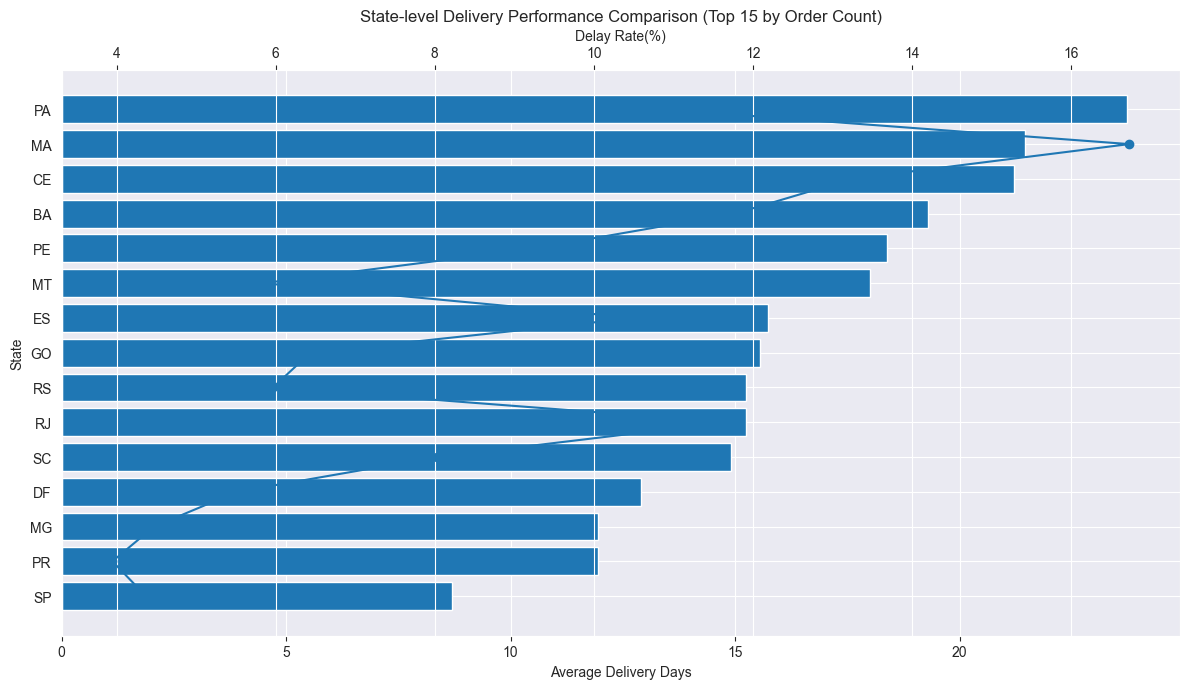

In [82]:
# visualise delivery days and delay rate together

fig, ax1 = plt.subplots(figsize=(12, 7))

ax1.barh(
    top15_logistics_states["customer_state"],
    top15_logistics_states["avg_delivery_days"]
)
ax1.set_xlabel("Average Delivery Days")
ax1.set_ylabel("State")
ax1.set_title("State-level Delivery Performance Comparison (Top 15 by Order Count)")
ax1.invert_yaxis()

ax2 = ax1.twiny()
ax2.plot(
    top15_logistics_states["delay_rate"],
    top15_logistics_states["customer_state"],
    marker="o"
)
ax2.set_xlabel("Delay Rate(%)")

plt.tight_layout()
plt.show()

In [83]:
# rank the same states by freight cost for supporting interpretation

top15_freight_states = (
    top15_logistics_states[
        ["customer_state", "avg_freight_cost", "avg_delivery_days", "delay_rate", "avg_review_score"]
    ]
    .sort_values("avg_freight_cost", ascending=False)
    .reset_index(drop=True)
)

print("Freight-cost comparison within top 15 states by order count")
display(top15_freight_states)

Freight-cost comparison within top 15 states by order count


,customer_state,avg_freight_cost,avg_delivery_days,delay_rate,avg_review_score
0,MA,42.571090,21.4611,16.73360,3.7534
1,PA,39.842690,23.7242,10.87179,3.8527
2,CE,36.442957,21.2061,13.24850,3.8580
3,PE,36.015940,18.3794,9.26150,4.0086
4,MT,32.906582,17.9977,5.84344,4.1036
5,BA,29.806459,19.2929,11.77515,3.8622
6,GO,26.491230,15.5480,6.43564,4.0435
7,RS,24.951491,15.2548,5.96414,4.1363
8,SC,24.827325,14.9198,8.02859,4.0764
9,ES,24.569104,15.7266,10.52632,4.0394


### State-level Delivery Performance Comparison Analysis
The state-level logistics comparison shows that **delivery performance differs substantially across major regional markets**.States such as `PA`, `MA`, and `CE` have the longest `avg_delivery_days`, while `SP`, `PR`, and `NG` perform much better on delivery speed. This suggests that the platform's logistics network is not equally efficient across regions, even among states with meaningful order volume.

The same pattern appears in `delay_rate` and `avg_freight_cost`, `MA`, `CE`, `BA`, and `RJ` combine relatively high delay or freight pressure with less competitive service outcomes, while `SP` stands out with the lowest `avg_delivery_days`, the lowest `avg_freight_cost`, and one of the strongest `avg_review_score` values. This is important because logistics performance is not only an operational issue; it is also a likely explanation for later regional differences in customer experience. At this stage, the comparison remains descriptive, but it already suggests that **slow and expensive delivery is concentrated in specific states rather than spread evenly across the platform**.

### 6.2 Same-state vs Cross-state Trade Comparison

After comparing logistics performance across states, the next step is to examine whether delivery outcomes differ between `Same State` and `Cross State` transactions. This step is necessary because part of the regional logistics gap may come from trade structure rather than from state location alone.

At this stage, the comparison uses `delivered_days`, `freight_value`, `gmv`, and `review_score` together. This is intentional: delivery distance may affect not only shipping time, but also cost and customer perception. The goal here is not to claim causality immediately, but to test whether the two trade types show a **clear and consistent performance gap**.

In [84]:
# compare same-state and cross-state transactions
# use the buyer-seller distance dataset because it preserves trade structure directly

trade_comparison = (
    df_distance.groupby("trade_type")
    .agg(
        order_count=("order_id", "count"),
        avg_delivery_days=("delivered_days", "mean"),
        avg_freight_value=("freight_value", "mean"),
        avg_gmv=("gmv", "mean"),
        avg_review_score=("review_score", "mean")
    )
    .reset_index()
)

print("Same-state vs cross-state trade comparison:")
display(trade_comparison.round(2))

Same-state vs cross-state trade comparison:


,trade_type,order_count,avg_delivery_days,avg_freight_value,avg_gmv,avg_review_score
0,Cross State,72149,14.99,23.68,153.51,3.97
1,Same State,40886,7.87,13.46,117.63,4.15


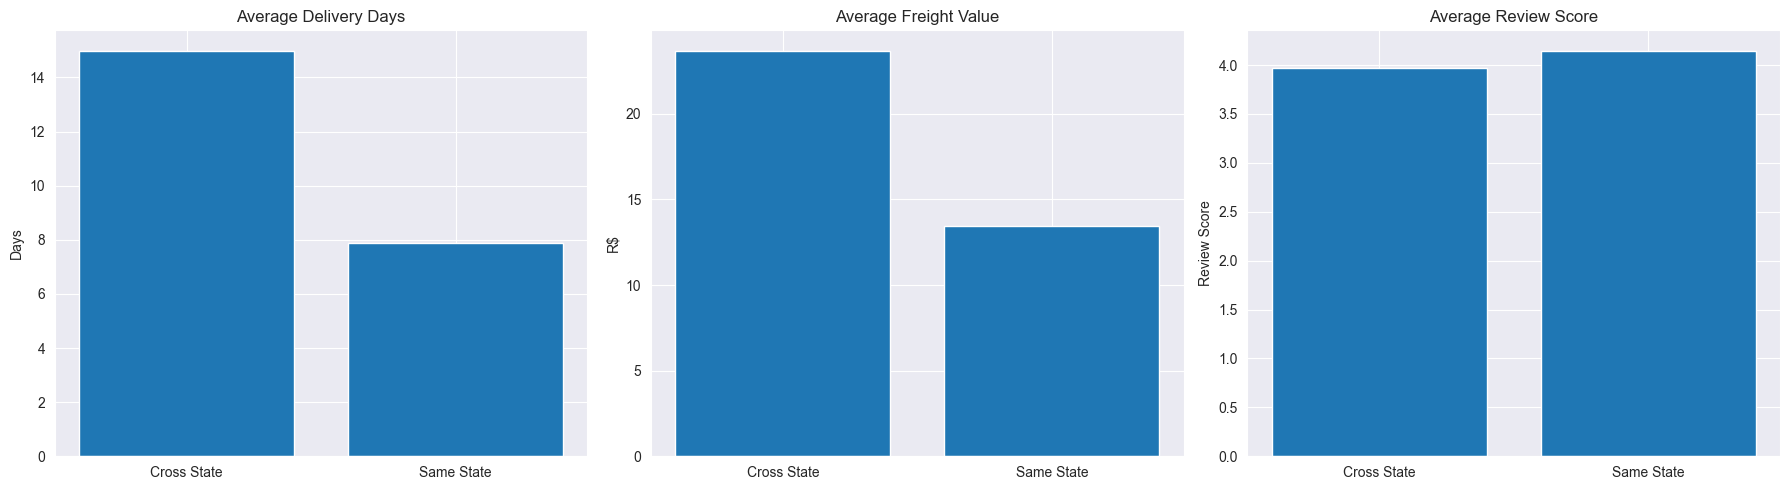

In [85]:
# visualise same-state vs cross-state comparison

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# average delivery days
axes[0].bar(
    trade_comparison["trade_type"],
    trade_comparison["avg_delivery_days"]
)
axes[0].set_title("Average Delivery Days")
axes[0].set_ylabel("Days")

# average freight value
axes[1].bar(
    trade_comparison["trade_type"],
    trade_comparison["avg_freight_value"]
)
axes[1].set_title("Average Freight Value")
axes[1].set_ylabel("R$")

# average review score
axes[2].bar(
    trade_comparison["trade_type"],
    trade_comparison["avg_review_score"]
)
axes[2].set_title("Average Review Score")
axes[2].set_ylabel("Review Score")

plt.tight_layout()
plt.show()

In [86]:
# test whether delivery time differs between same-state and cross-state transactions
# Welch's t-test is used because the two groups may have unequal variances

same_state_delivery = df_distance.loc[
    df_distance["trade_type"] == "Same State", "delivered_days"
].dropna()

cross_state_delivery = df_distance.loc[
    df_distance["trade_type"] == "Cross State", "delivered_days"
].dropna()

t_stat, p_value = stats.ttest_ind(
    same_state_delivery,
    cross_state_delivery,
    equal_var=False
)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Same-state average delivery days: {same_state_delivery.mean():.2f}")
print(f"Cross-state average delivery days: {cross_state_delivery.mean():.2f}")

T-statistic: -145.4815
P-value: 0.000000
Same-state average delivery days: 7.87
Cross-state average delivery days: 14.99


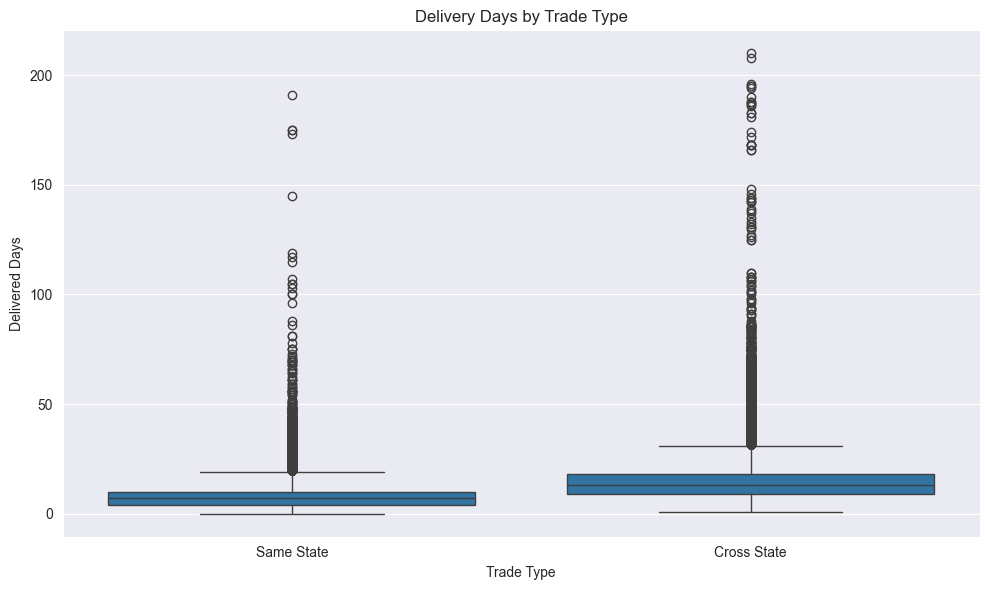

In [87]:
# compare the distribution of delivery days by trade type

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df_distance[df_distance["delivered_days"].notna()],
    x="trade_type",
    y="delivered_days"
)
plt.title("Delivery Days by Trade Type")
plt.xlabel("Trade Type")
plt.ylabel("Delivered Days")
plt.tight_layout()
plt.show()

### Same-state vs Cross-state Trade Comparison Analysis
The `trade_comparison` results show a **clear and substantial logistics gap** between `Same State` and `Cross State` transactions. Cross-state orders take about `14.99` days on average, compared with only `7.87` days for same-state orders, and they also have much higher `avg_freight_value` (`23.68` vs `13.46`). This suggests that a large part of delivery pressure is closely related to inter-state trade structure rather than to state performance alone.

The same pattern also appears in customer experience. `Cross State` transactions have a lower `avg_review_score`, which means the logistics difference is not only operational but also visible to customers. The `Welch's t-test` result (`t = -145.4815`, `p < 0.001`) confirms that the delivery-time gap is **statistically very strong rather than a random fluctuation**. The boxplot supports this further: cross-state orders are not only slower on average, but also show a wider distribution and more extreme long-delay cases. At this stage, the analysis still does not prove pure causality, but it provides strong evidence that **cross-state trade is one of the main structural drivers of delivery inefficiency**.
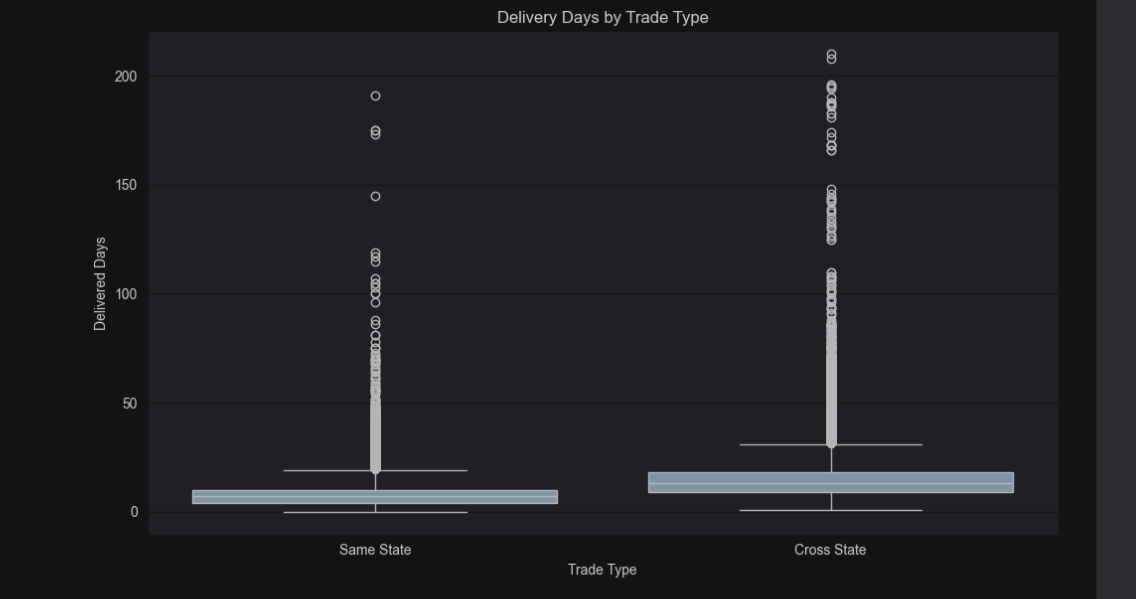

### 6.3 Major Trade Route Analysis

After confirming that `Cross State` transactions are slower and more expensive on average, the next step is to identify the major buyer-seller routes behind this pattern. This step is necessary because overall trade-type comparison shows the structural gap, but it does not reveal which specific regional connections matter most in practice.

At this stage, a `route` is defined as `buyer_state -> seller_state`. This is a simplified logistics representation rather than a full transport network model, but it is sufficient for identifying major transaction corridors and high-pressure routes. The analysis focuses first on the most active routes by `order_count`, because routes with very low volume may look extreme but are less important for overall operational impact.

In [88]:
# build buyer-seller route labels
# each route is defined as buyer_state -> seller_state

df_distance_route = df_distance.copy()
df_distance_route["route"] = (
    df_distance_route["buyer_state"] + " -> " + df_distance_route["seller_state"]
)

top20_routes_by_volume = (
    df_distance_route.groupby("route")
    .agg(
        order_count=("order_id", "count"),
        avg_delivery_days=("delivered_days", "mean"),
        avg_freight_value=("freight_value", "mean"),
        avg_gmv=("gmv", "mean"),
        avg_review_score=("review_score", "mean")
    )
    .reset_index()
    .sort_values("order_count", ascending=False)
    .head(20)
)

print("Top 20 routes by order count:")
display(top20_routes_by_volume.round(2))

Top 20 routes by order count:


,route,order_count,avg_delivery_days,avg_freight_value,avg_gmv,avg_review_score
404,SP -> SP,36316,7.87,13.20,113.08,4.13
301,RJ -> SP,9722,16.04,20.46,134.51,3.73
168,MG -> SP,8735,12.23,20.25,129.06,4.04
351,RS -> SP,4208,15.96,20.73,128.35,4.00
281,PR -> SP,3684,12.72,20.53,130.82,4.05
397,SP -> PR,3427,11.07,19.26,156.68,4.15
390,SP -> MG,2971,10.87,21.53,130.09,4.13
368,SC -> SP,2755,15.78,20.82,133.59,3.91
63,BA -> SP,2715,19.69,24.22,143.08,3.76
156,MG -> MG,1711,8.58,17.17,125.68,4.25


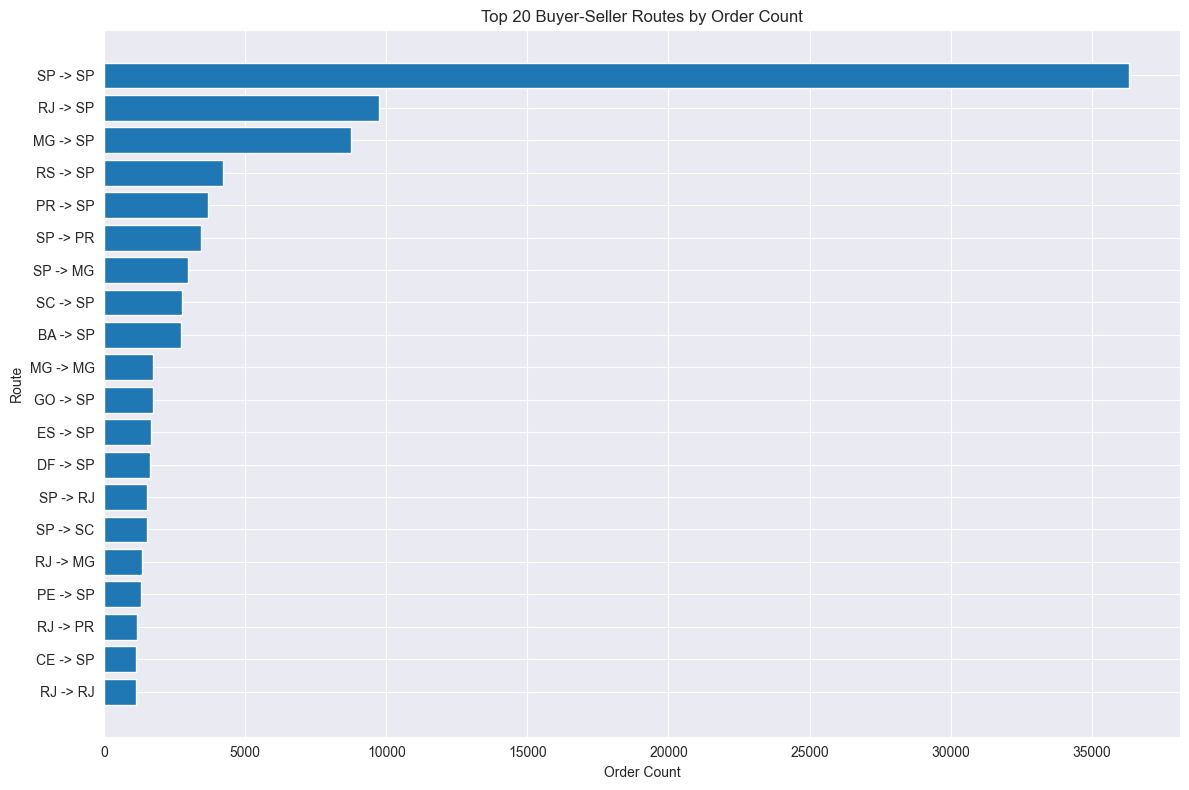

In [89]:
# visualise top 20 routes by order count

plt.figure(figsize=(12, 8))
plt.barh(
    top20_routes_by_volume["route"],
    top20_routes_by_volume["order_count"]
)

plt.xlabel("Order Count")
plt.ylabel("Route")
plt.title("Top 20 Buyer-Seller Routes by Order Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [90]:
# identify high-volume routes with slower delivery
# use the top 20 high-volume routes for a more meaningful operational comparison

slow_high_volume_routes = (
    top20_routes_by_volume[
        ["route", "order_count", "avg_delivery_days", "avg_freight_value", "avg_review_score"]
    ]
    .sort_values("avg_delivery_days", ascending=False)
    .reset_index(drop=True)
)

print("Slowest routes within top 20 by order count:")
display(slow_high_volume_routes.round(2))

Slowest routes within top 20 by order count:


,route,order_count,avg_delivery_days,avg_freight_value,avg_review_score
0,CE -> SP,1137,20.89,30.94,3.81
1,BA -> SP,2715,19.69,24.22,3.76
2,PE -> SP,1295,18.63,30.77,3.91
3,RJ -> PR,1156,16.80,22.42,3.76
4,RJ -> SP,9722,16.04,20.46,3.73
5,RS -> SP,4208,15.96,20.73,4.00
6,SC -> SP,2755,15.78,20.82,3.91
7,GO -> SP,1710,15.68,20.78,3.94
8,ES -> SP,1653,15.66,20.55,3.95
9,RJ -> MG,1336,14.01,24.69,3.98


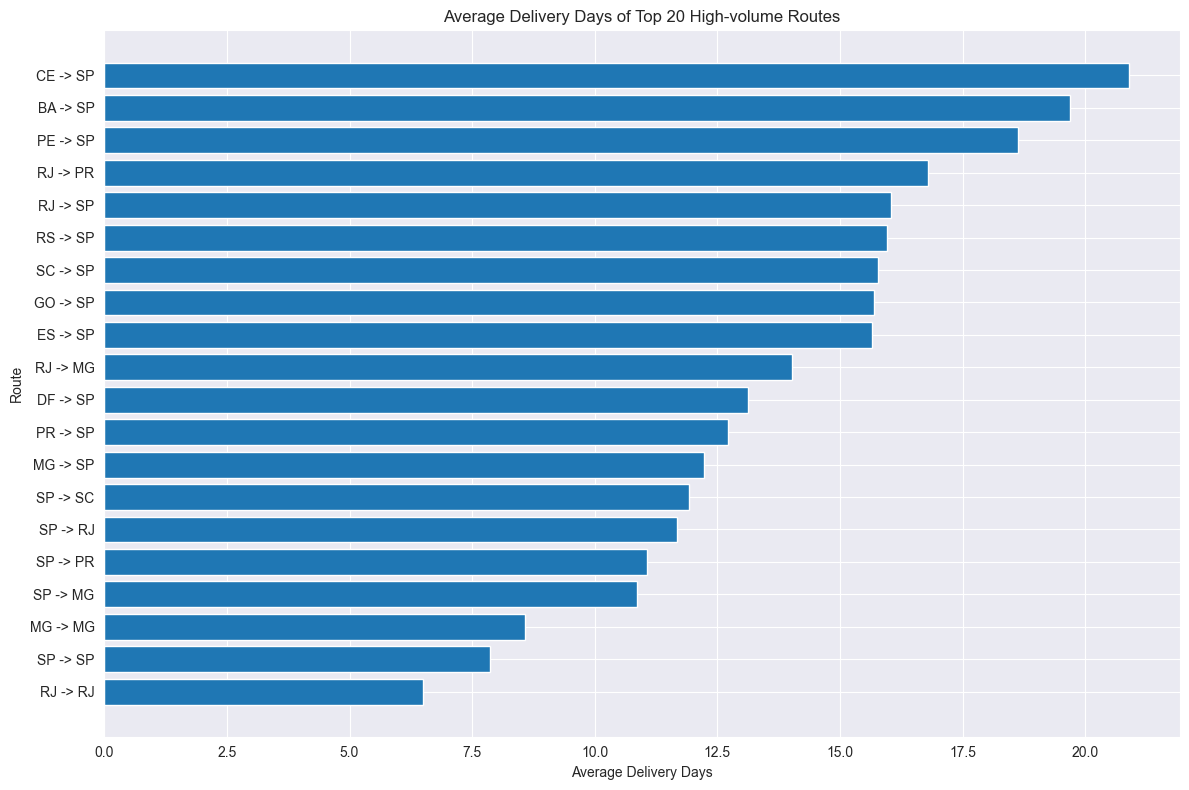

In [91]:
# visualise delivery time for the top 20 high-volume routes

plt.figure(figsize=(12, 8))
plt.barh(
    slow_high_volume_routes["route"],
    slow_high_volume_routes["avg_delivery_days"]
)

plt.xlabel("Average Delivery Days")
plt.ylabel("Route")
plt.title("Average Delivery Days of Top 20 High-volume Routes")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [92]:
# identify expensive routes within the same high-volume route set

expensive_high_volume_routes = (
    top20_routes_by_volume[
        ["route", "order_count", "avg_freight_value", "avg_delivery_days", "avg_review_score"]
    ]
    .sort_values("avg_freight_value", ascending=False)
    .reset_index(drop=True)
)

print("Most expensive routes within top 20 by order count:")
display(expensive_high_volume_routes.round(2))

Most expensive routes within top 20 by order count:


,route,order_count,avg_freight_value,avg_delivery_days,avg_review_score
0,CE -> SP,1137,30.94,20.89,3.81
1,PE -> SP,1295,30.77,18.63,3.91
2,RJ -> MG,1336,24.69,14.01,3.98
3,BA -> SP,2715,24.22,19.69,3.76
4,RJ -> PR,1156,22.42,16.80,3.76
5,SP -> SC,1507,22.18,11.92,4.12
6,SP -> MG,2971,21.53,10.87,4.13
7,SC -> SP,2755,20.82,15.78,3.91
8,GO -> SP,1710,20.78,15.68,3.94
9,RS -> SP,4208,20.73,15.96,4.00


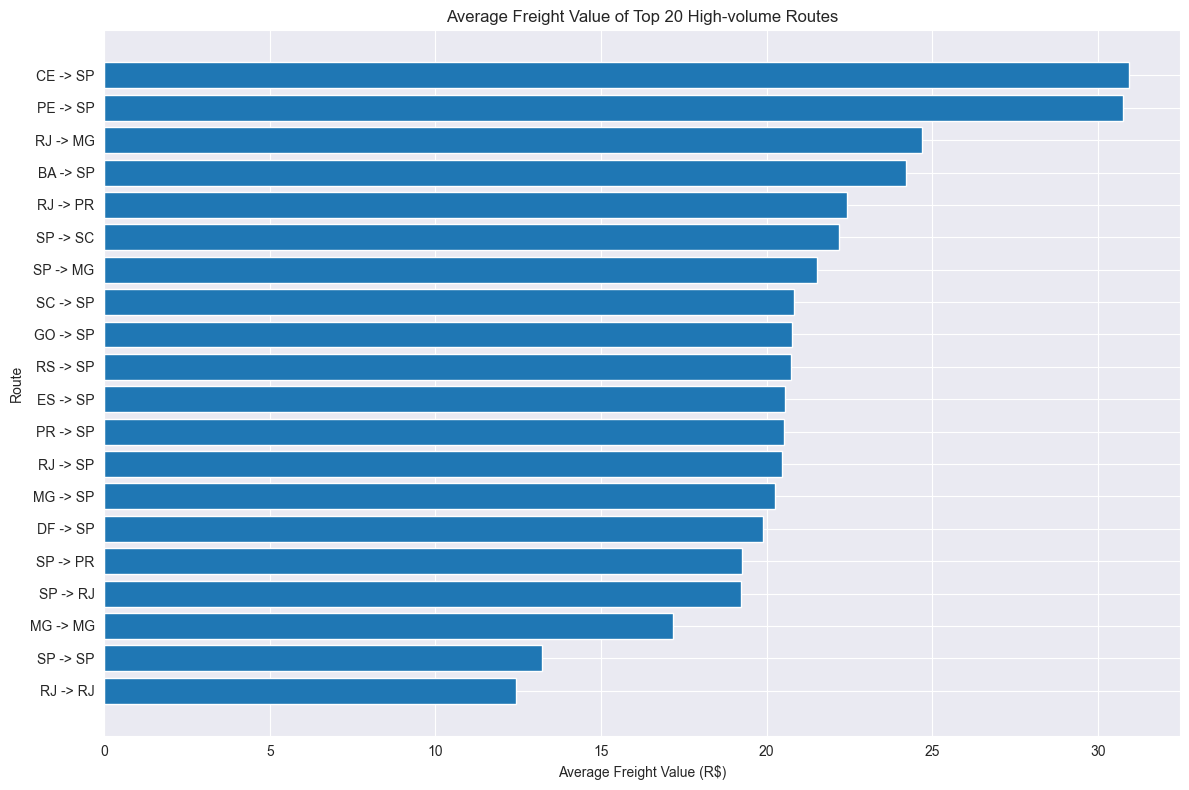

In [93]:
# visualise freight cost for the top 20 high-volume routes

plt.figure(figsize=(12, 8))
plt.barh(
    expensive_high_volume_routes["route"],
    expensive_high_volume_routes["avg_freight_value"]
)

plt.xlabel("Average Freight Value (R$)")
plt.ylabel("Route")
plt.title("Average Freight Value of Top 20 High-volume Routes")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Major Trade Route Analysis
The route-level results show that `SP` is **the dominant logistics hub of the platform**. The most active route is `SP -> SP`, which is both the largest by `order_count` and one of the fastest and cheapest routes. At the same time, many other high-volume routes also end in `SP`, such as `RJ -> SP`, `MG -> SP`, `RS -> SP`, and `PR -> SP`. This means the platform’s transaction network is not only geographically concentrated at the state level, but also strongly organised around one major destination market.

The slower and more expensive routes are also highly concentrated among the routes heading into `SP`, especially from `CE`, `BA`, `PE`, `SC`, `GO`, and `ES`. This is an important pattern because it suggests that **high route volume does not guarantee efficient delivery**. Some of the busiest corridors are also among the most time-consuming and costly, which may create structural logistics pressure around long-distance supply into core markets. By contrast, same-state routes such as `SP -> SP`, `MG -> MG`, and `RJ -> RJ` remain much faster and cheaper, which reinforces the earlier conclusion that cross-state trade is a major source of delivery inefficiency.

### 6.4 Freight Cost and Delivery Speed Relationship

After identifying slower and more expensive logistics routes, the next step is to examine the relationship between `freight_value` and `delivered_days`. This step is necessary because higher shipping cost does not automatically imply better logistics efficiency.

At this stage, the analysis is carried out at the transaction level rather than the state level. This is intentional: route-level and order-level variation would be hidden if only aggregated averages were used. A sample-based scatter plot is used for visual clarity, while the correlation is calculated on the full valid dataset to preserve statistical reliability.

In [94]:
# prepare valid data for freight-delivery relationship analysis

df_freight_delivery = df_distance[
    df_distance["freight_value"].notna() &
    df_distance["delivered_days"].notna()
].copy()

# compute Pearson correlation on the full valid dataset
corr_freight_delivery = df_freight_delivery["freight_value"].corr(
    df_freight_delivery["delivered_days"]
)

print("Valid observations for freight-delivery analysis:", len(df_freight_delivery))
print(f"Correlation between `freight_value` and `delivered_days`: {corr_freight_delivery:.4f}")

Valid observations for freight-delivery analysis: 110569
Correlation between `freight_value` and `delivered_days`: 0.2146


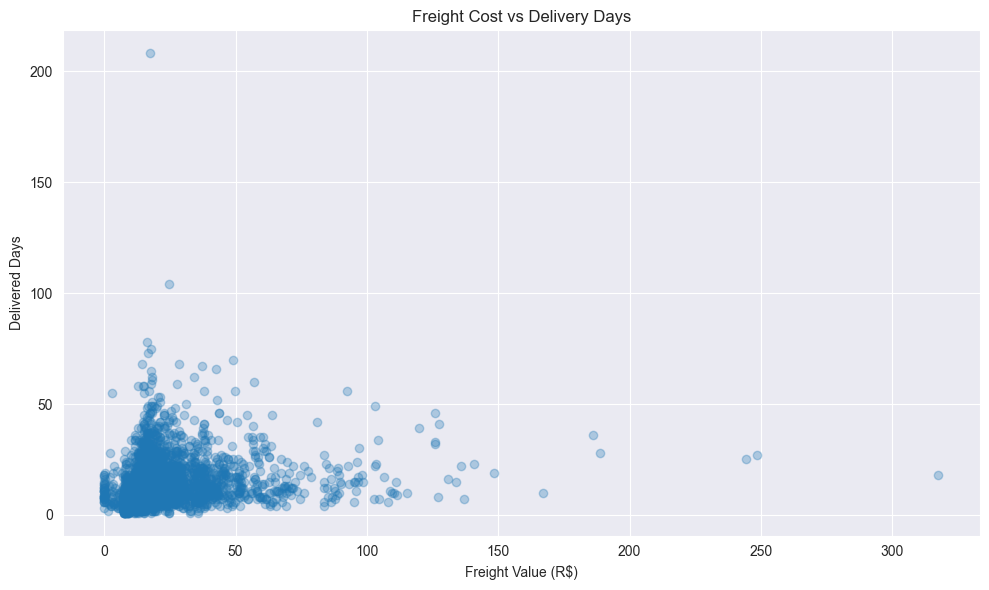

In [95]:
# use a sample for clearer visualisation
# keep the full dataset for correlation calculation above

sample_size = 5000
df_freight_sample = df_freight_delivery.sample(
    n=min(sample_size, len(df_freight_delivery)),
    random_state=42
)

plt.figure(figsize=(10, 6))
plt.scatter(
    df_freight_sample["freight_value"],
    df_freight_sample["delivered_days"],
    alpha=0.3
)

plt.xlabel("Freight Value (R$)")
plt.ylabel("Delivered Days")
plt.title("Freight Cost vs Delivery Days")
plt.tight_layout()
plt.show()

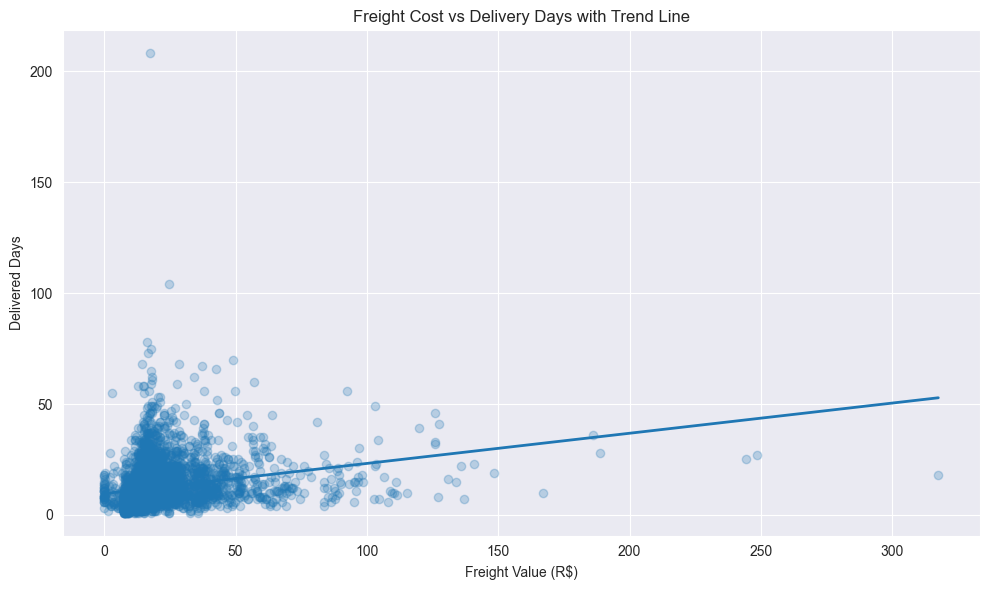

In [96]:
# add a simple linear trend line for easier interpretation

plt.figure(figsize=(10, 6))
plt.scatter(
    df_freight_sample["freight_value"],
    df_freight_sample["delivered_days"],
    alpha=0.25
)

z = np.polyfit(
    df_freight_sample["freight_value"],
    df_freight_sample["delivered_days"],
    1
)
p = np.poly1d(z)

x_line = np.linspace(
    df_freight_sample["freight_value"].min(),
    df_freight_sample["freight_value"].max(),
    200
)

plt.plot(x_line, p(x_line), linewidth=2)

plt.xlabel("Freight Value (R$)")
plt.ylabel("Delivered Days")
plt.title("Freight Cost vs Delivery Days with Trend Line")
plt.tight_layout()
plt.show()

In [97]:
# identify high-freight and slow-delivery orders using median thresholds

freight_median = df_freight_delivery["freight_value"].median()
delivery_median = df_freight_delivery["delivered_days"].median()

df_high_cost_slow = df_freight_delivery[
    (df_freight_delivery["freight_value"] > freight_median) &
    (df_freight_delivery["delivered_days"] > delivery_median)
].copy()

print(f"Median `freight_value`: {freight_median:.2f}")
print(f"Median `delivered_days`: {delivery_median:.2f}")
print("Number of high-cost and slow-delivery records:", len(df_high_cost_slow))
print(f"Share of valid records: {len(df_high_cost_slow) / len(df_freight_delivery) * 100:.2f}%")

Median `freight_value`: 16.25
Median `delivered_days`: 10.00
Number of high-cost and slow-delivery records: 34147
Share of valid records: 30.88%


In [98]:
# check whether high-cost and slow-delivery records are concentrated in a specific trade type

problem_trade_type = (
    df_high_cost_slow.groupby("trade_type")
    .agg(
        order_count=("order_id", "count"),
        avg_freight_value=("freight_value", "mean"),
        avg_delivery_days=("delivered_days", "mean"),
        avg_review_score=("review_score", "mean")
    )
    .reset_index()
)

print("High-cost and slow-delivery records by trade type:")
display(problem_trade_type.round(2))

High-cost and slow-delivery records by trade type:


,trade_type,order_count,avg_freight_value,avg_delivery_days,avg_review_score
0,Cross State,32150,28.77,19.80,3.88
1,Same State,1997,27.95,17.44,3.76


### Freight Cost and Delivery Speed Relationship Analysis
The scatter plots suggest that the relationship between `freight_value` and `delivered_days` is **positive but not strongly linear**. The fitted trend line slopes upward, which means more expensive orders tend to take longer rather than shorter to deliver. This is important because it shows that higher shipping cost does not automatically buy better logistics performance.

The middle-threshold check gives a similar message. About `30.88%` of valid records fall into the joint area of **high cost and slow delivery**, which is too large to treat as a small operational exception. The `problem_trade_type` table also shows that most of these records come from `Cross State` transactions, and that this group combines higher `avg_delivery_days` with weaker `avg_review_score`. At this stage, the evidence does not support the idea that expensive shipping is generally efficient; instead, it suggests that a meaningful share of logistics activity is **both costly and operationally inefficient**, especially in cross-state trade.

### 6.5 Logistics Risk State Identification

After examining delivery speed, trade structure, route performance, and the relationship between `freight_value` and `delivered_days`, the next step is to identify the states that face the strongest logistics pressure. This step is useful because earlier findings are still distributed across several views, while regional operations usually require a more direct list of risk areas.

At this stage, a state is treated as a logistics-risk state if it performs poorly on more than one indicator rather than on only one extreme value. This is intentional: a state may be slightly slow or slightly expensive by chance, but a combination of weak `avg_delivery_days`, high `delay_rate`, and high `avg_freight_cost` is more likely to reflect a structural logistics issue.

In [103]:
# build a simple logistics risk score at the state level
# larger values on these indicators mean worse logistics performance

df_logistics_risk = df_state[
    [
        "customer_state",
        "order_count",
        "avg_delivery_days",
        "delay_rate",
        "avg_freight_cost",
        "avg_review_score"
    ]
].copy()

# assign larger ranks to worse-performing states
df_logistics_risk["delivery_rank"] = df_logistics_risk["avg_delivery_days"].rank(ascending=True)
df_logistics_risk["delay_rank"] = df_logistics_risk["delay_rate"].rank(ascending=True)
df_logistics_risk["freight_rank"] = df_logistics_risk["avg_freight_cost"].rank(ascending=True)

df_logistics_risk["logistics_risk_score"] = (
    df_logistics_risk["delivery_rank"] +
    df_logistics_risk["delay_rank"] +
    df_logistics_risk["freight_rank"]
)

# now larger score really means higher logistics risk
df_logistics_risk = df_logistics_risk.sort_values(
    "logistics_risk_score",
    ascending=False
).reset_index(drop=True)

print("State-level logistics risk ranking:")
display(df_logistics_risk.round(2))

State-level logistics risk ranking:


,customer_state,order_count,avg_delivery_days,delay_rate,avg_freight_cost,avg_review_score,delivery_rank,delay_rank,freight_rank,logistics_risk_score
0,RR,46,29.34,10.87,48.59,3.61,27.0,19.0,27.0,73.0
1,MA,747,21.46,16.73,42.57,3.75,21.0,26.0,22.0,69.0
2,AL,413,24.45,20.58,38.63,3.76,24.0,27.0,16.0,67.0
3,SE,350,21.46,14.57,40.90,3.80,22.0,25.0,19.0,66.0
4,PI,495,19.39,13.33,42.99,3.91,17.0,24.0,23.0,64.0
5,PB,536,20.39,10.07,48.35,4.01,18.0,17.0,26.0,61.0
6,PA,975,23.72,10.87,39.84,3.85,23.0,20.0,18.0,61.0
7,CE,1336,21.21,13.25,36.44,3.86,20.0,23.0,14.0,57.0
8,BA,3380,19.29,11.78,29.81,3.86,16.0,22.0,11.0,49.0
9,AP,68,27.18,2.94,41.01,4.19,26.0,3.0,20.0,49.0


In [104]:
# focus on risk states with meaningful order volume
# this avoids over-emphasising very small states with unstable averages

median_order_count = df_logistics_risk["order_count"].median()

priority_logistics_risk_states = df_logistics_risk[
    df_logistics_risk["order_count"] >= median_order_count
].copy()

priority_logistics_risk_states = priority_logistics_risk_states.sort_values(
    "logistics_risk_score",
    ascending=False
).reset_index(drop=True)

print(f"Priority logistics-risk states (order_count >= median = {median_order_count:.0f}):")
display(priority_logistics_risk_states.round(2))

Priority logistics-risk states (order_count >= median = 907):


,customer_state,order_count,avg_delivery_days,delay_rate,avg_freight_cost,avg_review_score,delivery_rank,delay_rank,freight_rank,logistics_risk_score
0,PA,975,23.72,10.87,39.84,3.85,23.0,20.0,18.0,61.0
1,CE,1336,21.21,13.25,36.44,3.86,20.0,23.0,14.0,57.0
2,BA,3380,19.29,11.78,29.81,3.86,16.0,22.0,11.0,49.0
3,PE,1652,18.38,9.26,36.02,4.01,13.0,14.0,13.0,40.0
4,ES,2033,15.73,10.53,24.57,4.04,10.0,18.0,6.0,34.0
5,MT,907,18.00,5.84,32.91,4.10,12.0,9.0,12.0,33.0
6,RJ,12852,15.24,11.69,23.94,3.88,6.0,21.0,5.0,32.0
7,GO,2020,15.55,6.44,26.49,4.04,9.0,11.0,9.0,29.0
8,RS,5466,15.25,5.96,24.95,4.14,7.0,10.0,8.0,25.0
9,SC,3637,14.92,8.03,24.83,4.08,5.0,12.0,7.0,24.0


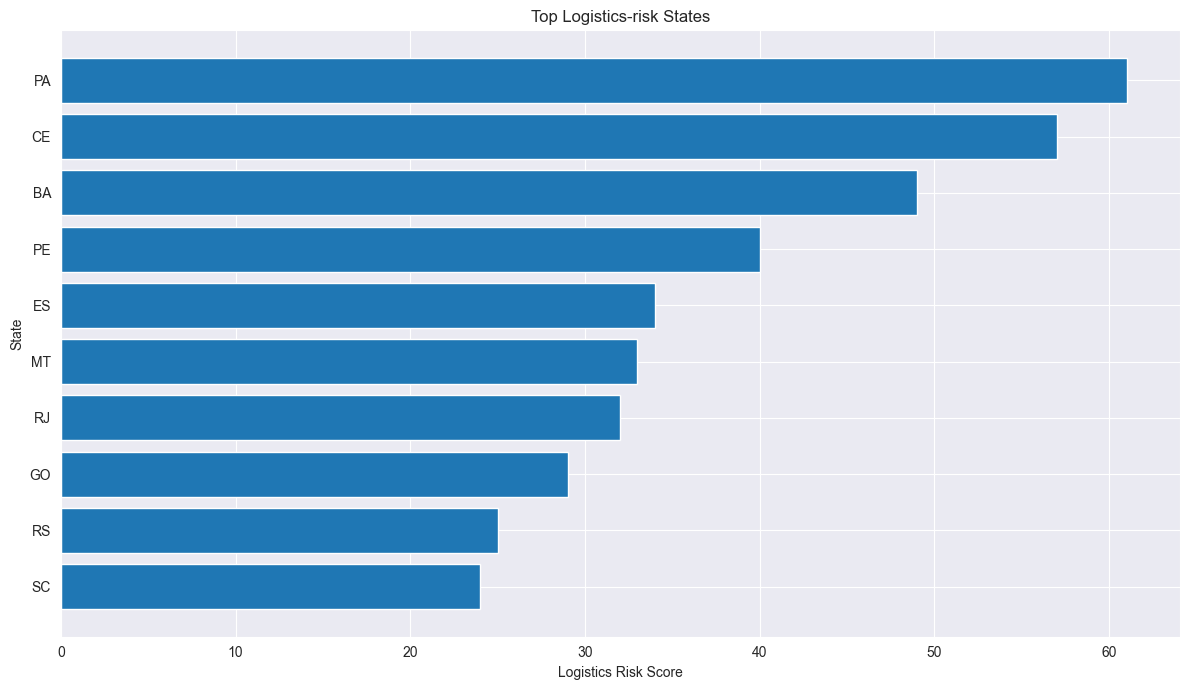

In [105]:
# visualise the main logistics-risk states

top10_logistics_risk_states = priority_logistics_risk_states.head(10)

plt.figure(figsize=(12, 7))
plt.barh(
    top10_logistics_risk_states["customer_state"],
    top10_logistics_risk_states["logistics_risk_score"]
)

plt.xlabel("Logistics Risk Score")
plt.ylabel("State")
plt.title("Top Logistics-risk States")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

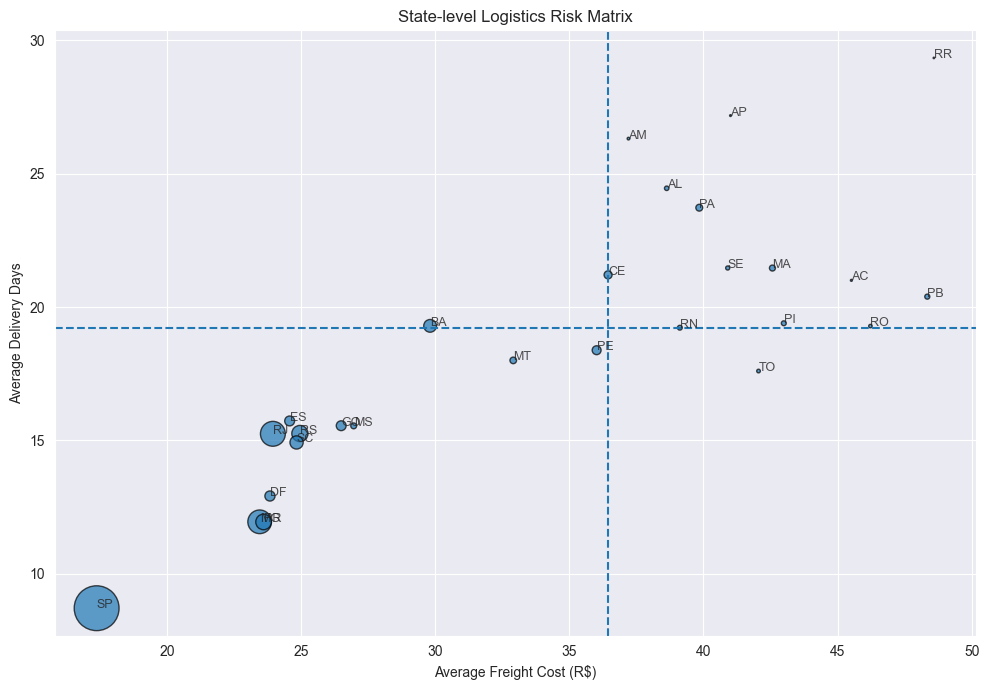

In [106]:
# create a simple logistics risk matrix
# x-axis: average freight cost, y-axis: average delivery days

plt.figure(figsize=(10, 7))
plt.scatter(
    df_logistics_risk["avg_freight_cost"],
    df_logistics_risk["avg_delivery_days"],
    s=df_logistics_risk["order_count"] / 40,
    alpha=0.7,
    edgecolors="black"
)

for _, row in df_logistics_risk.iterrows():
    plt.annotate(
        row["customer_state"],
        (row["avg_freight_cost"], row["avg_delivery_days"]),
        fontsize=9,
        alpha=0.8
    )

plt.axvline(df_logistics_risk["avg_freight_cost"].median(), linestyle="--")
plt.axhline(df_logistics_risk["avg_delivery_days"].median(), linestyle="--")

plt.xlabel("Average Freight Cost (R$)")
plt.ylabel("Average Delivery Days")
plt.title("State-level Logistics Risk Matrix")
plt.tight_layout()
plt.show()

### Logistics Rick state Identification Analysis
The corrected `logistics_risk_score` ranking shows that **logistics pressure is concentrated in a limited group of states rather than spread evenly across the platform**. In the full ranking, several low-volume states such as  `RR`, `AL`, and `SE` appear near the top, which suggests that very small markets can still show severe logistics weakness. However, their business impact is limited, so they should be interpreted cautiously rather than treated as the first operational priority.

The `priority_logistics_risk_states` filter makes the result more actionable. After keeping only states with at least median `order_count`, the main risk areas become `PA`, `CE`, `BA`, `PE`, and `ES`, with `RJ` and `MT` also showing meaningful logistics pressure. These states combine relatively weak `avg_delivery_days`, high `delay_rate`, and elevated `avg_freight_cost`, which means the problem is **multi-dimensional rather than driven by only one bad KPI**. The risk matrix supports the same conclusions: states in the upper-right area are both slower and more expensive, while `SP`, `PR`, and `MG` remain closer to the lower-cost, faster-delivery region.
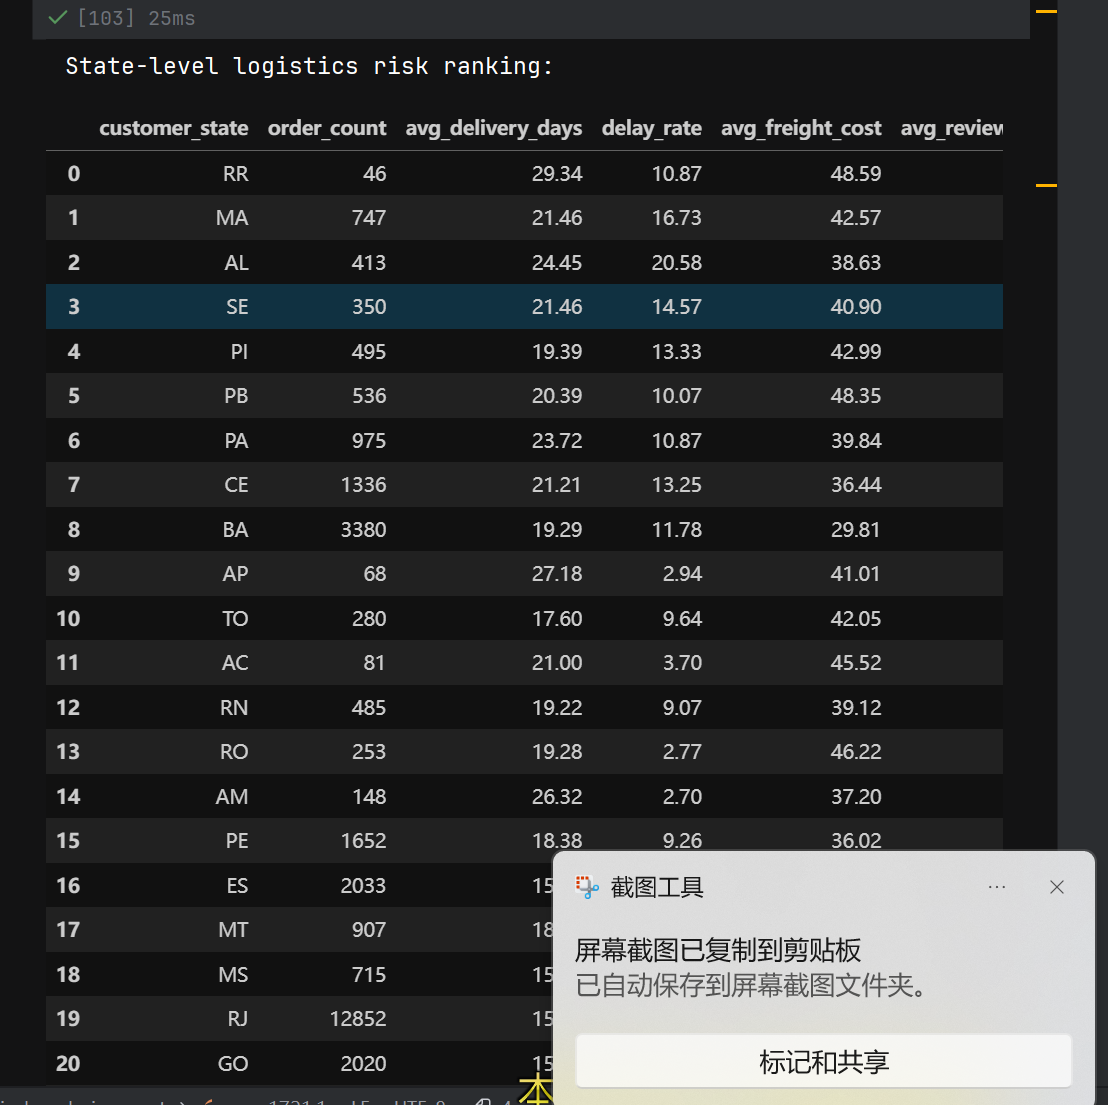

### 7.1 State-level Satisfaction Comparison

After examining logistics performance, the next step is to compare customer satisfaction across states. This step is necessary because regional delivery differences only become commercially meaningful when they are reflected in customer perception.

At this stage, the analysis focuses on `avg_review_score` and `bad_review_rate` together. This is intentional: the average score shows overall satisfaction level, while the bad-review ratio highlights the concentration of clearly negative experiences. Looking at only one of these measures would make the comparison too narrow.

In [107]:
# compare satisfaction performance across major states
# keep states with higher order volume for more stable comparison

top15_satisfaction_states = (
    df_state.sort_values("order_count", ascending=False)
    .head(15)[
        [
            "customer_state",
            "order_count",
            "avg_review_score",
            "bad_review_rate",
            "avg_delivery_days",
            "delay_rate"
        ]
    ]
    .sort_values("avg_review_score", ascending=False)
    .reset_index(drop=True)
)

print("Top 15 states by order count: satisfaction comparison")
display(top15_satisfaction_states.round(2))

Top 15 states by order count: satisfaction comparison


,customer_state,order_count,avg_review_score,bad_review_rate,avg_delivery_days,delay_rate
0,PR,5045,4.18,12.39,11.94,3.94
1,SP,41746,4.18,12.59,8.70,4.37
2,MG,11635,4.14,13.21,11.94,4.47
3,RS,5466,4.14,13.28,15.25,5.96
4,MT,907,4.10,13.70,18.00,5.84
5,SC,3637,4.08,14.56,14.92,8.03
6,DF,2140,4.07,14.95,12.91,5.51
7,GO,2020,4.04,14.79,15.55,6.44
8,ES,2033,4.04,14.91,15.73,10.53
9,PE,1652,4.01,16.75,18.38,9.26


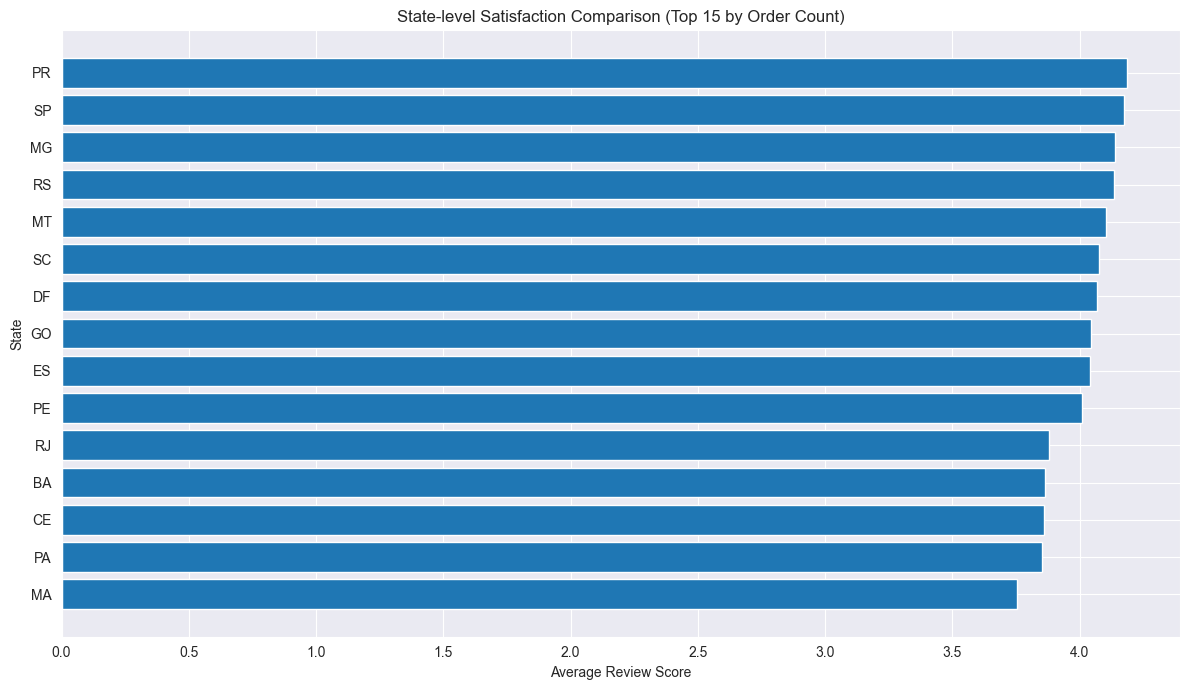

In [108]:
# visualise average review score across the top 15 states by order count

plt.figure(figsize=(12, 7))
plt.barh(
    top15_satisfaction_states["customer_state"],
    top15_satisfaction_states["avg_review_score"]
)

plt.xlabel("Average Review Score")
plt.ylabel("State")
plt.title("State-level Satisfaction Comparison (Top 15 by Order Count)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [109]:
# compare bad-review rate for the same group of states

top15_bad_review_states = (
    top15_satisfaction_states[
        [
            "customer_state",
            "bad_review_rate",
            "avg_review_score",
            "avg_delivery_days",
            "delay_rate"
        ]
    ]
    .sort_values("bad_review_rate", ascending=False)
    .reset_index(drop=True)
)

print("Bad-review comparison within top 15 states by order count")
display(top15_bad_review_states.round(2))

Bad-review comparison within top 15 states by order count


,customer_state,bad_review_rate,avg_review_score,avg_delivery_days,delay_rate
0,MA,21.95,3.75,21.46,16.73
1,RJ,20.59,3.88,15.24,11.69
2,CE,19.64,3.86,21.21,13.25
3,PA,19.54,3.85,23.72,10.87
4,BA,18.91,3.86,19.29,11.78
5,PE,16.75,4.01,18.38,9.26
6,DF,14.95,4.07,12.91,5.51
7,ES,14.91,4.04,15.73,10.53
8,GO,14.79,4.04,15.55,6.44
9,SC,14.56,4.08,14.92,8.03


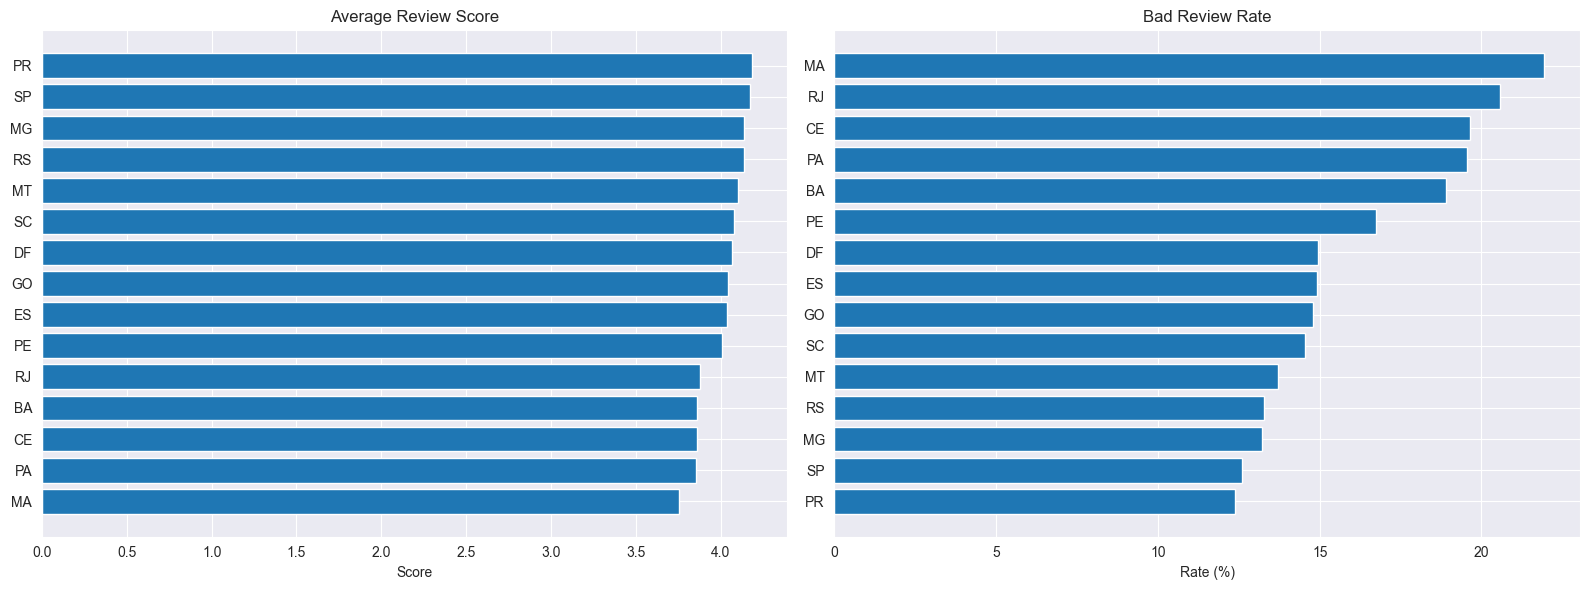

In [110]:
# visualise average review score and bad-review rate together

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# average review score
axes[0].barh(
    top15_satisfaction_states["customer_state"],
    top15_satisfaction_states["avg_review_score"]
)
axes[0].set_title("Average Review Score")
axes[0].set_xlabel("Score")
axes[0].invert_yaxis()

# bad review rate
axes[1].barh(
    top15_bad_review_states["customer_state"],
    top15_bad_review_states["bad_review_rate"]
)
axes[1].set_title("Bad Review Rate")
axes[1].set_xlabel("Rate (%)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### State-level Satisfaction Comparison Analysis
The state-level comparison shows that regional satisfaction differences are **visible but not extremely wide in average score**, with most high-volume states remaining between about `3.75` and `4.18`. This means the platform does not have a complete satisfaction breakdown in any major state, but it also suggests that small differences in `avg_review_score` may still be meaningful when they persist at scale. In this ranking, `PR` and `SP` perform best, while `MA`, `PA`, `CE`, and `BA` remain at the lower end.

The `bad_review_rate` results make the contrast clearer. States such as `MA`, `RJ`, `CE`, `PA`, and `BA` show a relatively high concentration of negative experiences, while `PR` and `SP` remain more stable on both measures. This is important because `avg_review_score` alone can compress regional differences, whereas `bad_review_rate` reveals where dissatisfaction is more concentrated. At this stage, the pattern already suggests that **states with weaker logistics performance tend to also show weaker customer satisfaction**, although the relationship still needs to be tested more directly in the next step.

### 7.2 Satisfaction and Logistics Relationship

After comparing state-level satisfaction, the next step is to examine whether customer evaluation is systematically associated with logistics performance. This step is necessary because descriptive rankings alone are not enough to show whether weaker delivery conditions are actually linked to lower satisfaction.

At this stage, the analysis focuses on `avg_review_score`, `bad_review_rate`, `avg_delivery_days`, and `delay_rate`. This is intentional: `avg_delivery_days` captures delivery speed, while `delay_rate` reflects reliability. Using both helps avoid treating logistics as a one-dimensional concept. A correlation matrix is used first for summary comparison, and scatter plots are then used to make the pattern more interpretable.

In [111]:
# examine the relationship between satisfaction and logistics indicators at the state level

satisfaction_logistics_vars = [
    "avg_review_score",
    "bad_review_rate",
    "avg_delivery_days",
    "delay_rate",
    "avg_freight_cost"
]

corr_satisfaction_logistics = df_state[satisfaction_logistics_vars].corr()

print("Correlation matrix: satisfaction and logistics indicators")
display(corr_satisfaction_logistics.round(3))

Correlation matrix: satisfaction and logistics indicators


,avg_review_score,bad_review_rate,avg_delivery_days,delay_rate,avg_freight_cost
avg_review_score,1.000,-0.948,-0.513,-0.805,-0.430
bad_review_rate,-0.948,1.000,0.421,0.808,0.367
avg_delivery_days,-0.513,0.421,1.000,0.301,0.802
delay_rate,-0.805,0.808,0.301,1.000,0.262
avg_freight_cost,-0.430,0.367,0.802,0.262,1.000


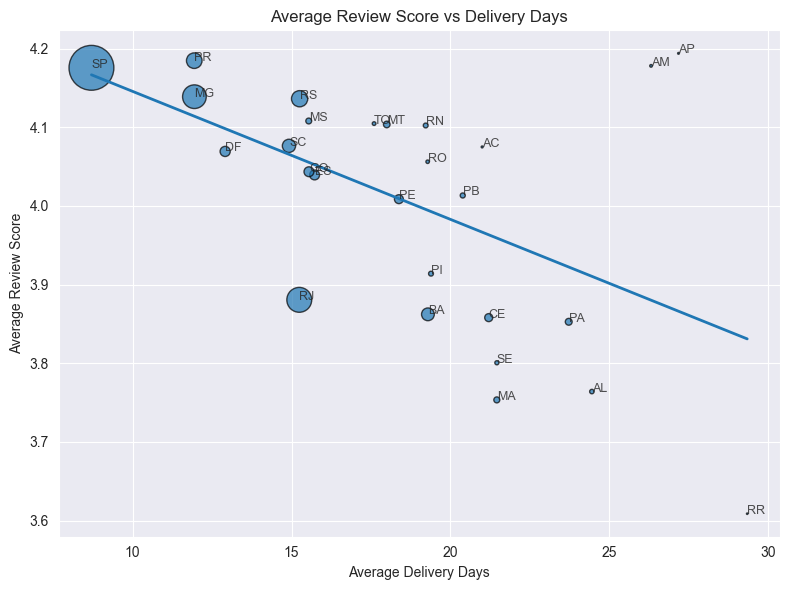

In [112]:
# scatter plot: average review score vs average delivery days

plt.figure(figsize=(8, 6))
plt.scatter(
    df_state["avg_delivery_days"],
    df_state["avg_review_score"],
    s=df_state["order_count"] / 40,
    alpha=0.7,
    edgecolors="black"
)

for _, row in df_state.iterrows():
    plt.annotate(
        row["customer_state"],
        (row["avg_delivery_days"], row["avg_review_score"]),
        fontsize=9,
        alpha=0.8
    )

z = np.polyfit(df_state["avg_delivery_days"], df_state["avg_review_score"], 1)
p = np.poly1d(z)

x_line = np.linspace(
    df_state["avg_delivery_days"].min(),
    df_state["avg_delivery_days"].max(),
    200
)

plt.plot(x_line, p(x_line), linewidth=2)

plt.xlabel("Average Delivery Days")
plt.ylabel("Average Review Score")
plt.title("Average Review Score vs Delivery Days")
plt.tight_layout()
plt.show()

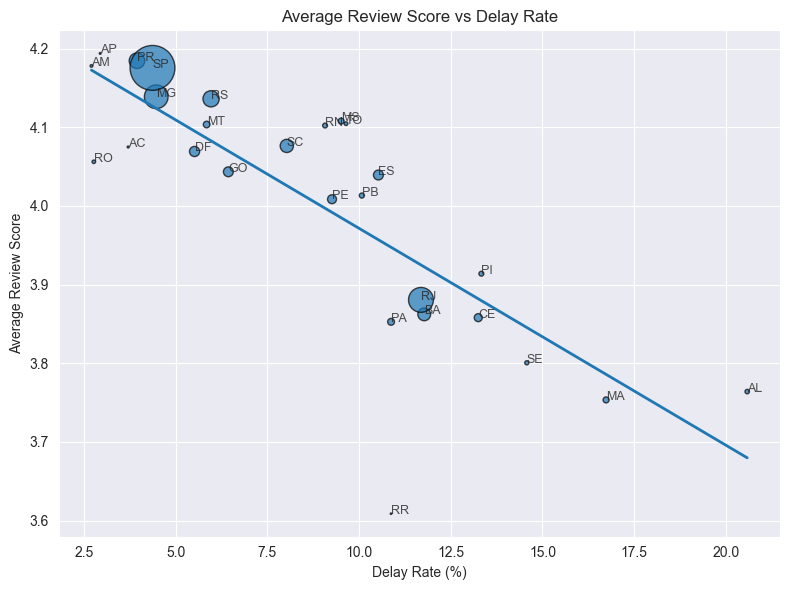

In [113]:
# scatter plot: average review score vs delay rate

plt.figure(figsize=(8, 6))
plt.scatter(
    df_state["delay_rate"],
    df_state["avg_review_score"],
    s=df_state["order_count"] / 40,
    alpha=0.7,
    edgecolors="black"
)

for _, row in df_state.iterrows():
    plt.annotate(
        row["customer_state"],
        (row["delay_rate"], row["avg_review_score"]),
        fontsize=9,
        alpha=0.8
    )

z = np.polyfit(df_state["delay_rate"], df_state["avg_review_score"], 1)
p = np.poly1d(z)

x_line = np.linspace(
    df_state["delay_rate"].min(),
    df_state["delay_rate"].max(),
    200
)

plt.plot(x_line, p(x_line), linewidth=2)

plt.xlabel("Delay Rate (%)")
plt.ylabel("Average Review Score")
plt.title("Average Review Score vs Delay Rate")
plt.tight_layout()
plt.show()

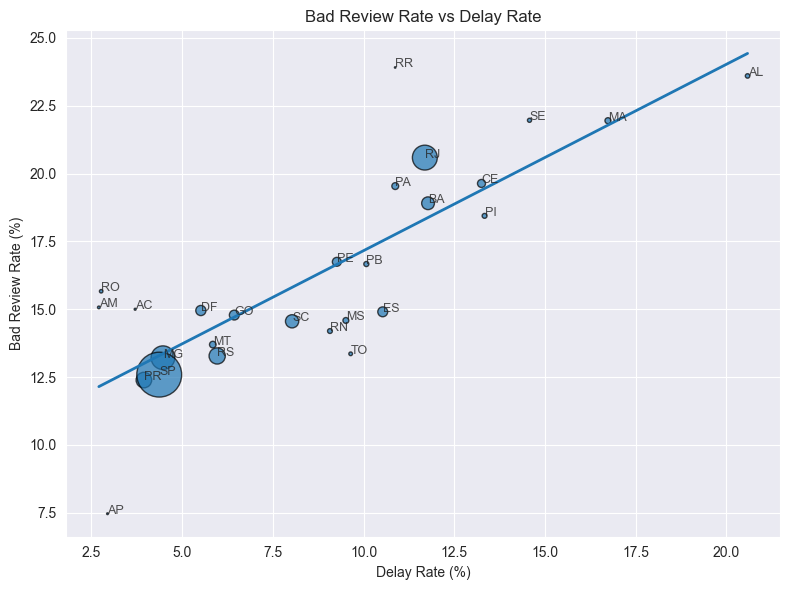

In [114]:
# scatter plot: bad review rate vs delay rate

plt.figure(figsize=(8, 6))
plt.scatter(
    df_state["delay_rate"],
    df_state["bad_review_rate"],
    s=df_state["order_count"] / 40,
    alpha=0.7,
    edgecolors="black"
)

for _, row in df_state.iterrows():
    plt.annotate(
        row["customer_state"],
        (row["delay_rate"], row["bad_review_rate"]),
        fontsize=9,
        alpha=0.8
    )

z = np.polyfit(df_state["delay_rate"], df_state["bad_review_rate"], 1)
p = np.poly1d(z)

x_line = np.linspace(
    df_state["delay_rate"].min(),
    df_state["delay_rate"].max(),
    200
)

plt.plot(x_line, p(x_line), linewidth=2)

plt.xlabel("Delay Rate (%)")
plt.ylabel("Bad Review Rate (%)")
plt.title("Bad Review Rate vs Delay Rate")
plt.tight_layout()
plt.show()

### Satisfaction and Logistics Relationship Analysis
The correlation results show that **customer satisfaction is clearly associated with logistics performance**, but the strength of that relationship is not identical across indicators. `avg_review_score` has a moderate negative correlation with `avg_delivery_days` (`-0.513`), but a much stronger negative correlation with `delay_rate` (`-0.805`). This suggests that customers may tolerate slower delivery to some extent, but they react more strongly when delivery becomes unreliable or frequently delayed.

The same pattern appears from the bad-experience side. `bad_review_rate` is strongly positively correlated with `delay_rate` (`0.808`), which means delays are closely linked to the accumulation of negative reviews. The scatter plots support this visual pattern: the downward trend is clearer in `avg_review_score vs delay_rate` than in `avg_review_score vs avg_delivery_days`, and the upward trend in `bad_review_rate vs delay_rate` is also more direct. At this stage, the analysis still does not prove strict causality, but it provides strong evidence that **delivery reliability matters more than delivery speed alone in shaping regional satisfaction differences**.

### 7.3 Problem Region Identification

After comparing satisfaction levels and linking them to logistics indicators, the next step is to identify the states where satisfaction problems are also commercially important. This step is necessary because not every low-score state should be treated as an immediate operational priority.

At this stage, a state is treated as a problem region when it combines relatively weak satisfaction with meaningful business volume. This is intentional: low-volume states may look extreme because of small-sample fluctuation, but states with both high `order_count` and weak `avg_review_score` are more likely to represent structural customer-experience risk.

In [115]:
# identify problem regions with both meaningful order volume and weak satisfaction

median_order_count = df_state["order_count"].median()
median_review_score = df_state["avg_review_score"].median()

problem_regions = df_state[
    (df_state["order_count"] >= median_order_count) &
    (df_state["avg_review_score"] < median_review_score)
].copy()

problem_regions = problem_regions[
    [
        "customer_state",
        "order_count",
        "avg_review_score",
        "bad_review_rate",
        "avg_delivery_days",
        "delay_rate",
        "avg_freight_cost"
    ]
].sort_values(
    ["avg_review_score", "order_count"],
    ascending=[True, False]
).reset_index(drop=True)

print(f"Problem regions (order_count >= median = {median_order_count:.0f}, avg_review_score < median = {median_review_score:.2f}):")
display(problem_regions.round(2))

Problem regions (order_count >= median = 907, avg_review_score < median = 4.06):


,customer_state,order_count,avg_review_score,bad_review_rate,avg_delivery_days,delay_rate,avg_freight_cost
0,PA,975,3.85,19.54,23.72,10.87,39.84
1,CE,1336,3.86,19.64,21.21,13.25,36.44
2,BA,3380,3.86,18.91,19.29,11.78,29.81
3,RJ,12852,3.88,20.59,15.24,11.69,23.94
4,PE,1652,4.01,16.75,18.38,9.26,36.02
5,ES,2033,4.04,14.91,15.73,10.53,24.57
6,GO,2020,4.04,14.79,15.55,6.44,26.49


In [116]:
# identify states with both high bad-review rate and high delay rate

median_bad_review = df_state["bad_review_rate"].median()
median_delay_rate = df_state["delay_rate"].median()

problem_regions_delay = df_state[
    (df_state["bad_review_rate"] > median_bad_review) &
    (df_state["delay_rate"] > median_delay_rate)
].copy()

problem_regions_delay = problem_regions_delay[
    [
        "customer_state",
        "order_count",
        "avg_review_score",
        "bad_review_rate",
        "avg_delivery_days",
        "delay_rate",
        "avg_freight_cost"
    ]
].sort_values(
    ["bad_review_rate", "delay_rate"],
    ascending=False
).reset_index(drop=True)

print(f"Problem regions by bad reviews and delay (bad_review_rate > median = {median_bad_review:.2f}, delay_rate > median = {median_delay_rate:.2f}):")
display(problem_regions_delay.round(2))

Problem regions by bad reviews and delay (bad_review_rate > median = 15.00, delay_rate > median = 9.26):


,customer_state,order_count,avg_review_score,bad_review_rate,avg_delivery_days,delay_rate,avg_freight_cost
0,RR,46,3.61,23.91,29.34,10.87,48.59
1,AL,413,3.76,23.60,24.45,20.58,38.63
2,SE,350,3.80,21.97,21.46,14.57,40.90
3,MA,747,3.75,21.95,21.46,16.73,42.57
4,RJ,12852,3.88,20.59,15.24,11.69,23.94
5,CE,1336,3.86,19.64,21.21,13.25,36.44
6,PA,975,3.85,19.54,23.72,10.87,39.84
7,BA,3380,3.86,18.91,19.29,11.78,29.81
8,PI,495,3.91,18.44,19.39,13.33,42.99
9,PB,536,4.01,16.67,20.39,10.07,48.35


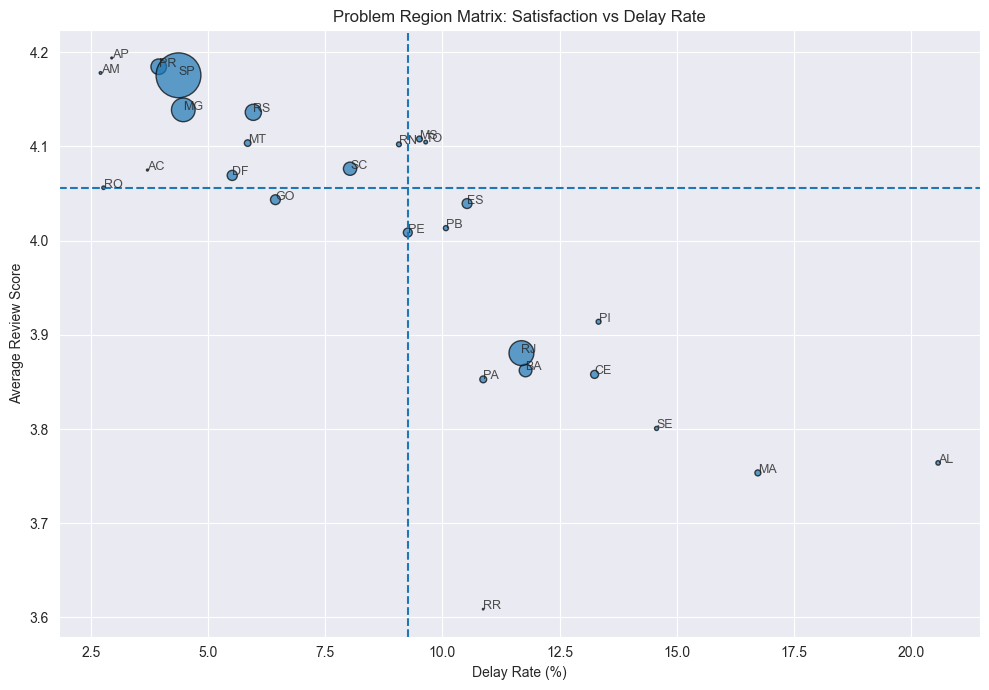

In [117]:
# visualise problem regions in a satisfaction-logistics space

plt.figure(figsize=(10, 7))
plt.scatter(
    df_state["delay_rate"],
    df_state["avg_review_score"],
    s=df_state["order_count"] / 40,
    alpha=0.7,
    edgecolors="black"
)

for _, row in df_state.iterrows():
    plt.annotate(
        row["customer_state"],
        (row["delay_rate"], row["avg_review_score"]),
        fontsize=9,
        alpha=0.8
    )

plt.axvline(df_state["delay_rate"].median(), linestyle="--")
plt.axhline(df_state["avg_review_score"].median(), linestyle="--")

plt.xlabel("Delay Rate (%)")
plt.ylabel("Average Review Score")
plt.title("Problem Region Matrix: Satisfaction vs Delay Rate")
plt.tight_layout()
plt.show()

In [118]:
# mark whether a state is a priority problem region

df_state_problem_flag = df_state.copy()

df_state_problem_flag["problem_region_flag"] = np.where(
    (df_state_problem_flag["order_count"] >= median_order_count) &
    (df_state_problem_flag["avg_review_score"] < median_review_score),
    "Priority Problem Region",
    "Other"
)

print("Priority problem-region flags:")
display(
    df_state_problem_flag[
        ["customer_state", "order_count", "avg_review_score", "delay_rate", "problem_region_flag"]
    ].sort_values(["problem_region_flag", "order_count"], ascending=[False, False]).round(2)
)

Priority problem-region flags:


,customer_state,order_count,avg_review_score,delay_rate,problem_region_flag
18,RJ,12852,3.88,11.69,Priority Problem Region
4,BA,3380,3.86,11.78,Priority Problem Region
7,ES,2033,4.04,10.53,Priority Problem Region
8,GO,2020,4.04,6.44,Priority Problem Region
15,PE,1652,4.01,9.26,Priority Problem Region
5,CE,1336,3.86,13.25,Priority Problem Region
13,PA,975,3.85,10.87,Priority Problem Region
25,SP,41746,4.18,4.37,Other
10,MG,11635,4.14,4.47,Other
22,RS,5466,4.14,5.96,Other


### Problem Region Identification Analysis
The `problem_regions` results show that customer-experience risk is **not evenly distributed across high-volume markets**. The main priority problem states are `RA`, `CE`, `BA`, `RJ`, `PE`, `ES`, and `GO`, because they combine relatively weak `avg_review_score` with meaningful `order_count`. This means the issue is not limited to small or unstable markets; it is already affecting states with real commercial importance.

The second filter using `bad_review_rate` and `delay_rate` supports the same pattern from a different angle. States such as `RJ`, `CE`, `PA`, and `BA` appear again, which suggests that their weaker satisfaction is not only visible in average score, but also in the concentration of clearly negative customer experiences. The matrix view reinforces this interpretation: the upper-left region contains states with relatively strong satisfaction, while the lower-right region highlights states where **high delay and weak customer perception overlap**. At this stage, the most concerning issue is not simply low satisfaction, but low satisfaction in states that also matter operationally and commercially.
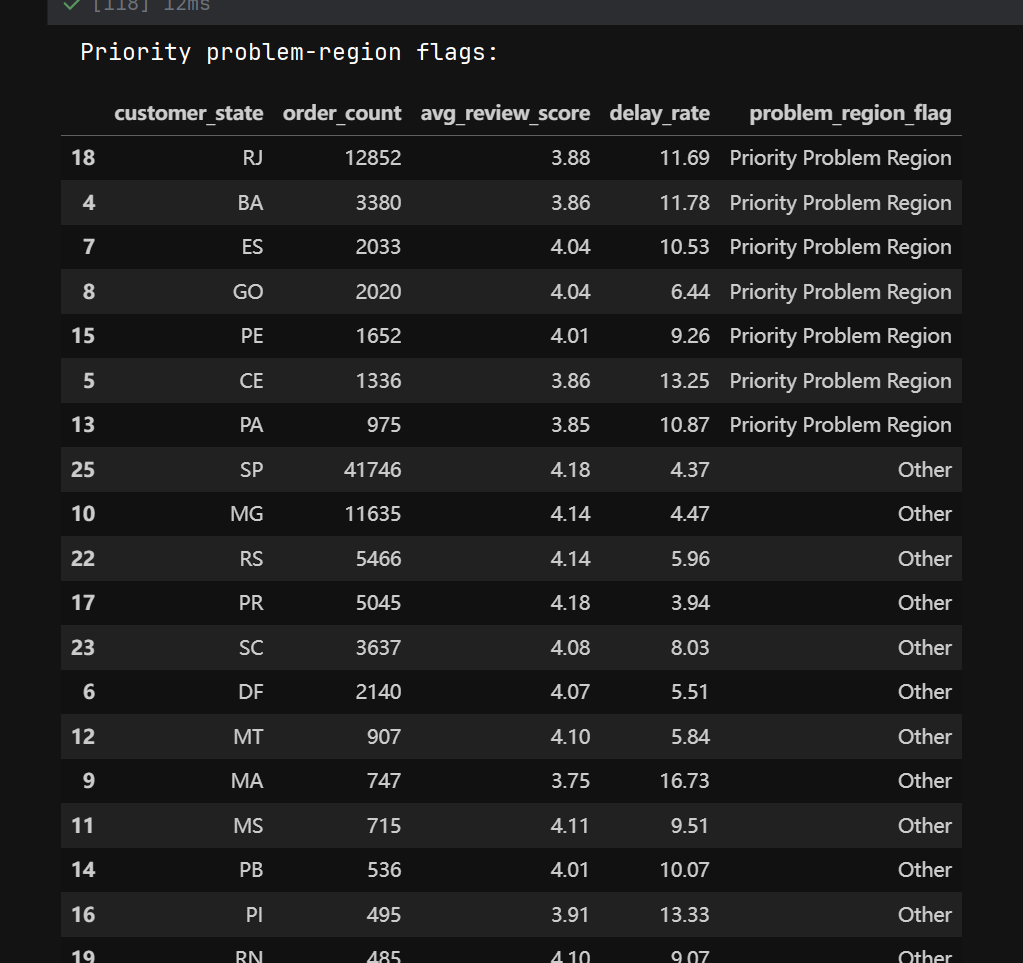
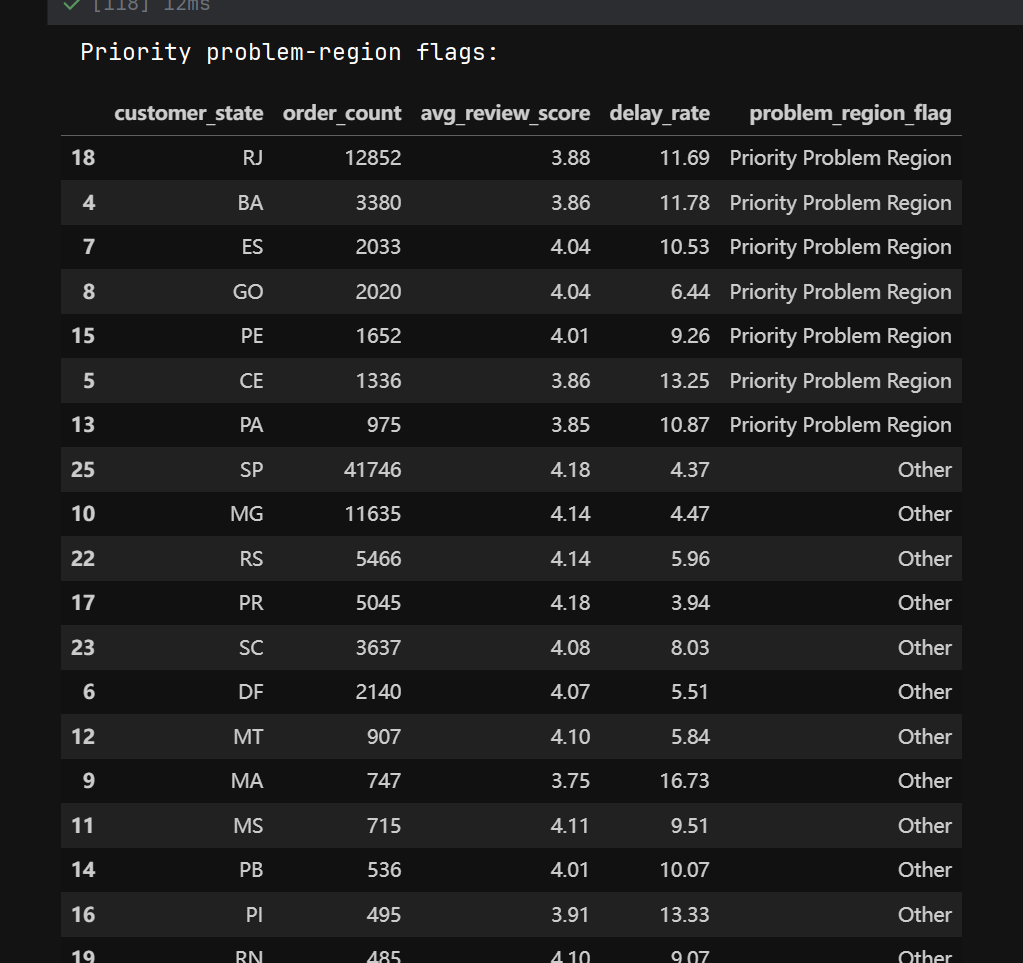

### 7.4 Cluster-level Satisfaction Profile

After identifying problem regions, the next step is to compare satisfaction performance across the previously defined `cluster_name` groups. This step is useful because individual states may vary, but cluster-level comparison helps reveal whether customer-experience differences also follow the broader regional segmentation structure.

At this stage, the analysis focuses on `avg_review_score` and `bad_review_rate` at the cluster level. This is intentional: the goal is not to compare every state again, but to test whether the regional types identified earlier also differ systematically in customer satisfaction. This helps connect the segmentation chapter with the satisfaction chapter in a more integrated way.

In [120]:
# compare satisfaction performance across regional clusters

cluster_satisfaction_profile = (
    df_state_clustered.groupby("cluster_name")
    .agg(
        state_count=("customer_state", "count"),
        total_order_count=("order_count", "sum"),
        avg_review_score=("avg_review_score", "mean"),
        bad_review_rate=("bad_review_rate", "mean"),
        avg_delivery_days=("avg_delivery_days", "mean"),
        delay_rate=("delay_rate", "mean")
    )
    .reset_index()
)

print("Cluster-level satisfaction profile:")
display(cluster_satisfaction_profile.round(2))

Cluster-level satisfaction profile:


,cluster_name,state_count,total_order_count,avg_review_score,bad_review_rate,avg_delivery_days,delay_rate
0,Balanced Core Markets,9,45543,4.08,14.81,14.34,7.34
1,High-AOV Potential Markets,9,4410,4.09,14.21,20.82,6.22
2,Logistics-Stressed Markets,8,7742,3.80,20.99,22.54,14.00
3,Super Core Outlier Market,1,41746,4.18,12.59,8.70,4.37


In [121]:
# sort clusters by average review score for clearer comparison

cluster_satisfaction_ranked = cluster_satisfaction_profile.sort_values(
    "avg_review_score",
    ascending=False
).reset_index(drop=True)

print("Cluster-level satisfaction ranking:")
display(cluster_satisfaction_ranked.round(2))

Cluster-level satisfaction ranking:


,cluster_name,state_count,total_order_count,avg_review_score,bad_review_rate,avg_delivery_days,delay_rate
0,Super Core Outlier Market,1,41746,4.18,12.59,8.70,4.37
1,High-AOV Potential Markets,9,4410,4.09,14.21,20.82,6.22
2,Balanced Core Markets,9,45543,4.08,14.81,14.34,7.34
3,Logistics-Stressed Markets,8,7742,3.80,20.99,22.54,14.00


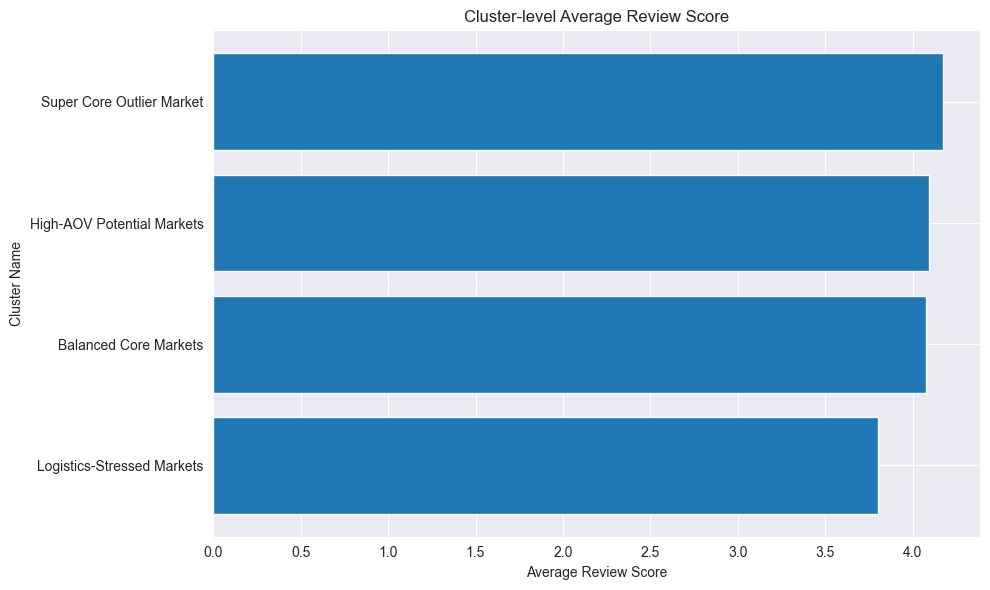

In [122]:
# visualise average review score across clusters

plt.figure(figsize=(10, 6))
plt.barh(
    cluster_satisfaction_ranked["cluster_name"],
    cluster_satisfaction_ranked["avg_review_score"]
)

plt.xlabel("Average Review Score")
plt.ylabel("Cluster Name")
plt.title("Cluster-level Average Review Score")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

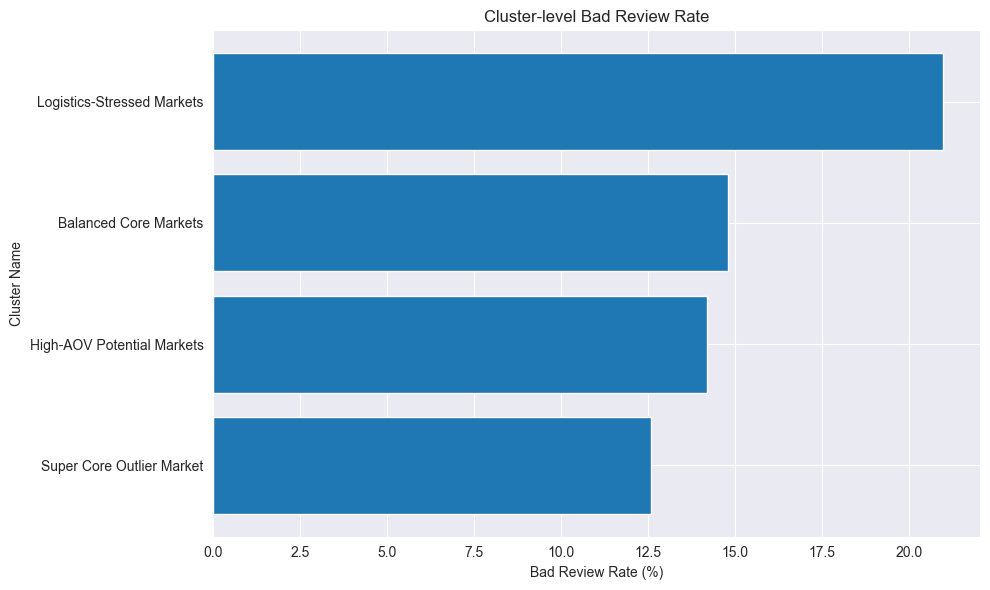

In [123]:
# visualise bad-review rate across clusters

cluster_bad_review_ranked = cluster_satisfaction_profile.sort_values(
    "bad_review_rate",
    ascending=False
).reset_index(drop=True)

plt.figure(figsize=(10, 6))
plt.barh(
    cluster_bad_review_ranked["cluster_name"],
    cluster_bad_review_ranked["bad_review_rate"]
)

plt.xlabel("Bad Review Rate (%)")
plt.ylabel("Cluster Name")
plt.title("Cluster-level Bad Review Rate")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

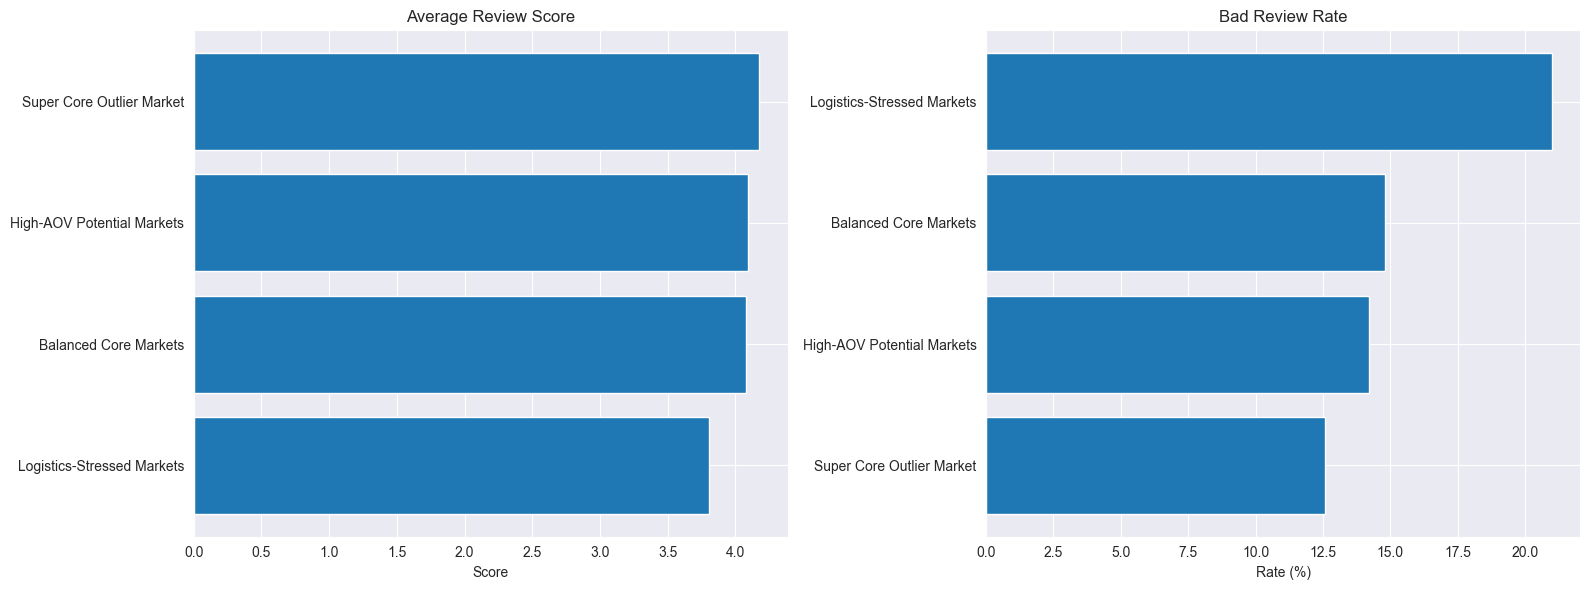

In [124]:
# compare average review score and bad-review rate side by side

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(
    cluster_satisfaction_ranked["cluster_name"],
    cluster_satisfaction_ranked["avg_review_score"]
)
axes[0].set_title("Average Review Score")
axes[0].set_xlabel("Score")
axes[0].invert_yaxis()

axes[1].barh(
    cluster_bad_review_ranked["cluster_name"],
    cluster_bad_review_ranked["bad_review_rate"]
)
axes[1].set_title("Bad Review Rate")
axes[1].set_xlabel("Rate (%)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

### Cluster-level Satisfaction Profile Analysis
The `cluster-level` results show that customer satisfaction differences are **not random across states, but are aligned with the broader regional segmentation structure**. The `Super Core Outlier Market` performs best, with the highest `avg_review_score` (`4.18`) and the lowest `bad_review_rate` (`12.59`). This is consistent with its earlier profile of stronger logistics performance and confirms that the platform’s most dominant market is also its most stable in customer experience terms.

The weakest cluster is clearly `Logistics-Stressed Markets`, where `avg_review_score` drops to `3.80` and `bad_review_rate` rises to `20.99`. This pattern strongly supports the earlier finding that **logistics pressure and satisfaction weakness tend to cluster together rather than appear independently**. By contrast, `Balanced Core Markets` and `High-AOV Potential Markets` remain relatively close in average satisfaction, which suggests that smaller market scale does not necessarily lead to worse customer perception. At this stage, the main structural contrast is not between large and small markets, but between regions with more stable operations and regions under stronger logistics stress.
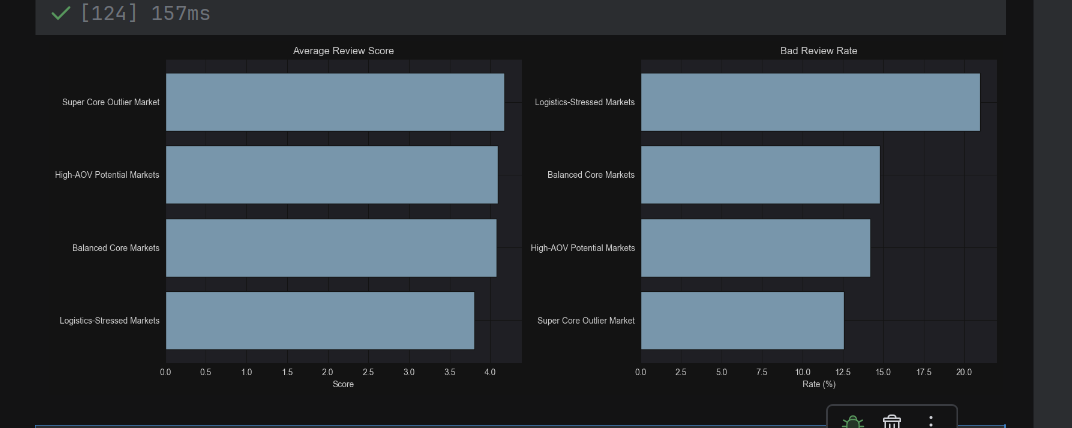
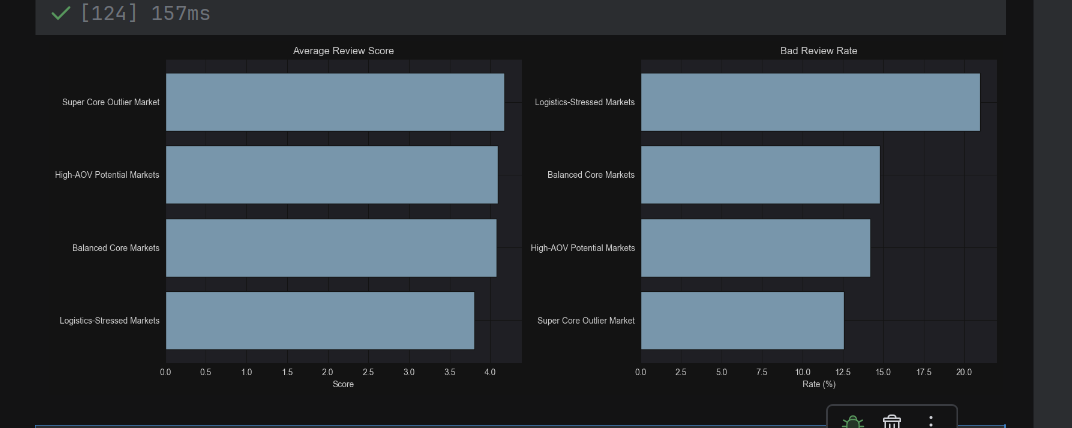
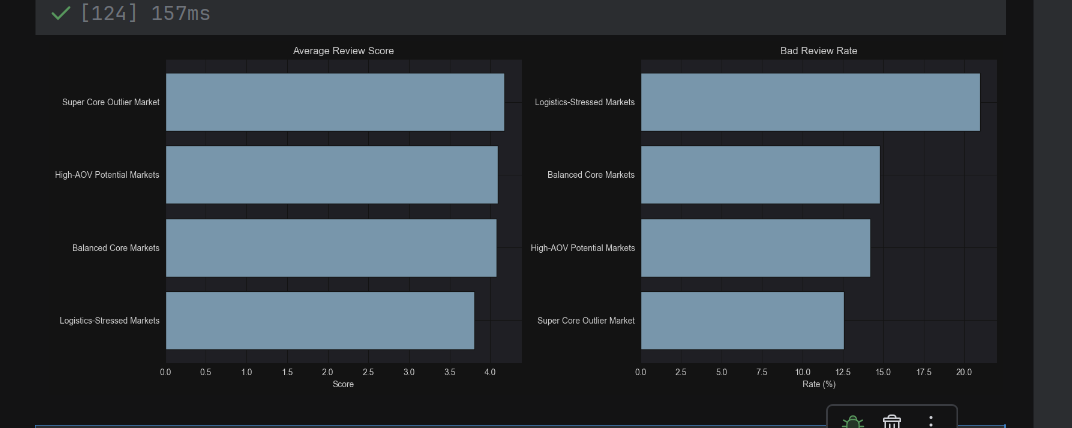

## 8. Regional Product Preference Analysis

### 8.1 Top Categories by State

After identifying regional market strength, logistics pressure, and satisfaction differences, the next step is to examine whether states also differ in what they buy. This step is necessary because regional performance is not only shaped by market size, but also by product mix and local demand structure.

At this stage, the analysis focuses on category-level `GMV` by state. This is intentional: `GMV` captures the economic weight of each category more directly than transaction count alone. The goal here is not to describe every small category, but to identify the main demand pattern within each important regional market.

In [125]:
# aggregate category-level GMV by state
# use the order-level dataset with valid category information

state_category_gmv = (
    df_orders_category.groupby(["customer_state", "category"])
    .agg(
        total_gmv=("gmv", "sum"),
        order_count=("order_id", "count")
    )
    .reset_index()
)

print("State-category GMV table:")
display(state_category_gmv.head())

State-category GMV table:


,customer_state,category,total_gmv,order_count
0,AC,artigos_de_natal,130.85,1
1,AC,automotivo,661.91,4
2,AC,bebes,871.97,3
3,AC,beleza_saude,1655.00,7
4,AC,brinquedos,318.05,3


In [126]:
# focus on the top 10 states by total GMV for clearer comparison

top10_states = (
    df_state.sort_values("total_gmv", ascending=False)
    .head(10)["customer_state"]
    .tolist()
)

state_top_categories = (
    state_category_gmv[state_category_gmv["customer_state"].isin(top10_states)]
    .sort_values(["customer_state", "total_gmv"], ascending=[True, False])
)

print("Top 5 categories within top 10 states:")
display(state_top_categories.groupby("customer_state").head(5).round(2))

Top 5 categories within top 10 states:


,customer_state,category,total_gmv,order_count
136,BA,beleza_saude,60254.07,350
184,BA,relogios_presentes,53789.79,234
155,BA,esporte_lazer,46618.58,295
166,BA,informatica_acessorios,39630.40,259
133,BA,automotivo,34247.82,158
296,DF,relogios_presentes,35589.67,148
252,DF,beleza_saude,34567.72,246
278,DF,informatica_acessorios,28455.11,164
270,DF,esporte_lazer,27707.97,226
254,DF,cama_mesa_banho,20849.40,213


In [127]:
# print top 5 categories for each top-10 state

for state in top10_states:
    print(f"\nTop 5 categories in {state}:")
    display(
        state_top_categories[state_top_categories["customer_state"] == state]
        .head(5)
        .round(2)
    )


Top 5 categories in SP:


,customer_state,category,total_gmv,order_count
1271,SP,cama_mesa_banho,560177.54,5278
1269,SP,beleza_saude,520635.92,4216
1324,SP,relogios_presentes,463521.22,2284
1290,SP,esporte_lazer,441785.98,3675
1302,SP,informatica_acessorios,399592.99,3188



Top 5 categories in RJ:


,customer_state,category,total_gmv,order_count
978,RJ,relogios_presentes,199298.21,875
926,RJ,cama_mesa_banho,181035.41,1650
924,RJ,beleza_saude,165010.22,1069
945,RJ,esporte_lazer,147031.53,1048
957,RJ,informatica_acessorios,141904.44,1005



Top 5 categories in MG:


...

,customer_state,category,total_gmv,order_count
296,DF,relogios_presentes,35589.67,148
252,DF,beleza_saude,34567.72,246
278,DF,informatica_acessorios,28455.11,164
270,DF,esporte_lazer,27707.97,226
254,DF,cama_mesa_banho,20849.40,213



Top 5 categories in GO:


,customer_state,category,total_gmv,order_count
417,GO,relogios_presentes,36031.50,147
369,GO,beleza_saude,33781.26,230
371,GO,cama_mesa_banho,28122.96,240
383,GO,cool_stuff,25647.35,100
389,GO,esporte_lazer,23294.13,168



Top 5 categories in ES:


,customer_state,category,total_gmv,order_count
354,ES,relogios_presentes,32094.41,152
314,ES,cama_mesa_banho,27265.64,228
330,ES,esporte_lazer,23938.40,174
312,ES,beleza_saude,23851.84,165
339,ES,informatica_acessorios,18084.18,152


### Top Categories by State Analysis
The `state_category_gmv` results show that regional product demand is **not completely unique by state, but neither is it fully homogeneous**. Across the top-value states, several categories appear repeatedly, such as `beleza_saude`, `relogios_presentes`, `esporte_lazer`, and `informatica_acessorios`. This suggests that the platform has a relatively stable national demand base in a few commercially important categories.

At the same time, the ranking is not identical across states, which means regional demand structure still matters. For example, `BA` shows strong weight in `beleza_saude` and `relogios_presentes`, while `DF`, `ES`, and `GO` also give prominent positions to `informatica_acessorios`, `cama_mesa_banho`, or `cool_stuff`. This is important because high-value states are not differentiated only by size; they are also differentiated by **which category mix generates that value**. At this stage, the evidence points to a pattern of **shared category core plus regional variation at the margin**, which is exactly the kind of structure that can support more targeted regional assortment strategy later.

#### 8.2 Category Preference Heatmap by State
After reviewing the top categories within major states, the next step is to compare these category patterns in a more structured way. This step is useful because ranking tables show local leaders, but they are less effective for comparing preference structure across multiple states at the same time.

At this stage, the heatmap focuses on the top `10` states by `total_gmv` and the top `15` categories by total `GMV`. This is intentional: using all states and all categories would make the visualisation too sparse and difficult to interpret. The aim here is not full coverage, but a **clear comparison of the main regional demand structure**.

In [128]:
# identify the top 15 categories by total GMV across the full valid category dataset

top15_categories = (
    df_orders_category.groupby("category")["gmv"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
    .index
    .tolist()
)

print("Top 15 categories by total GMV:")
print(top15_categories)

Top 15 categories by total GMV:
['beleza_saude', 'relogios_presentes', 'cama_mesa_banho', 'esporte_lazer', 'informatica_acessorios', 'moveis_decoracao', 'utilidades_domesticas', 'cool_stuff', 'automotivo', 'ferramentas_jardim', 'brinquedos', 'bebes', 'perfumaria', 'telefonia', 'moveis_escritorio']


In [130]:
# build a state-category pivot table for the top 10 states and top 15 categories

heatmap_data = state_category_gmv[
    (state_category_gmv["customer_state"].isin(top10_states)) &
    (state_category_gmv["category"].isin(top15_categories))
].copy()

state_category_pivot = heatmap_data.pivot(
    index="customer_state",
    columns="category",
    values="total_gmv"
).fillna(0)

print("State-category GMV pivot table:")
display(state_category_pivot.round(2))

State-category GMV pivot table:


category,automotivo,bebes,beleza_saude,brinquedos,cama_mesa_banho,cool_stuff,esporte_lazer,ferramentas_jardim,informatica_acessorios,moveis_decoracao,moveis_escritorio,perfumaria,relogios_presentes,telefonia,utilidades_domesticas
customer_state,,,,,,,,,,,,,,,
BA,34247.82,18353.65,60254.07,17747.78,32459.75,27734.00,46618.58,29825.34,39630.40,30754.44,18923.63,11471.81,53789.79,25688.79,22246.52
DF,20130.57,10210.60,34567.72,13849.54,20849.40,14267.27,27707.97,10668.42,28455.11,15538.83,3884.40,11370.67,35589.67,7718.73,16575.57
ES,14199.17,9904.85,23851.84,12456.00,27265.64,12487.14,23938.40,13609.61,18084.18,16320.37,6818.33,7731.13,32094.41,11183.92,15049.65
GO,13558.86,11359.40,33781.26,9551.51,28122.96,25647.35,23294.13,18613.41,16776.95,15825.22,4118.62,11920.04,36031.50,8207.25,18640.04
MG,84283.48,56608.21,178980.48,68634.00,158926.03,82950.66,133532.60,73535.42,129590.00,99646.19,35853.82,55560.08,134686.20,42960.55,96804.46
PR,33895.47,25367.79,62777.38,28159.67,55833.14,42057.56,67921.95,25667.79,51316.82,62141.81,20450.85,18277.77,65269.61,17264.41,38695.62
RJ,75819.67,50798.81,165010.22,84573.13,181035.41,95695.74,147031.53,90066.75,141904.44,122934.71,59947.34,61077.62,199298.21,45619.00,97689.05
RS,30938.13,35781.86,60624.05,33597.21,73352.53,52623.29,64125.06,43531.45,63030.49,67649.89,13417.46,23383.30,52150.82,24146.26,48909.97
SC,32101.32,19880.41,46063.88,18188.63,38619.00,31860.28,51488.30,27963.50,44093.41,40381.40,13186.78,15953.10,36406.57,15058.45,33272.30


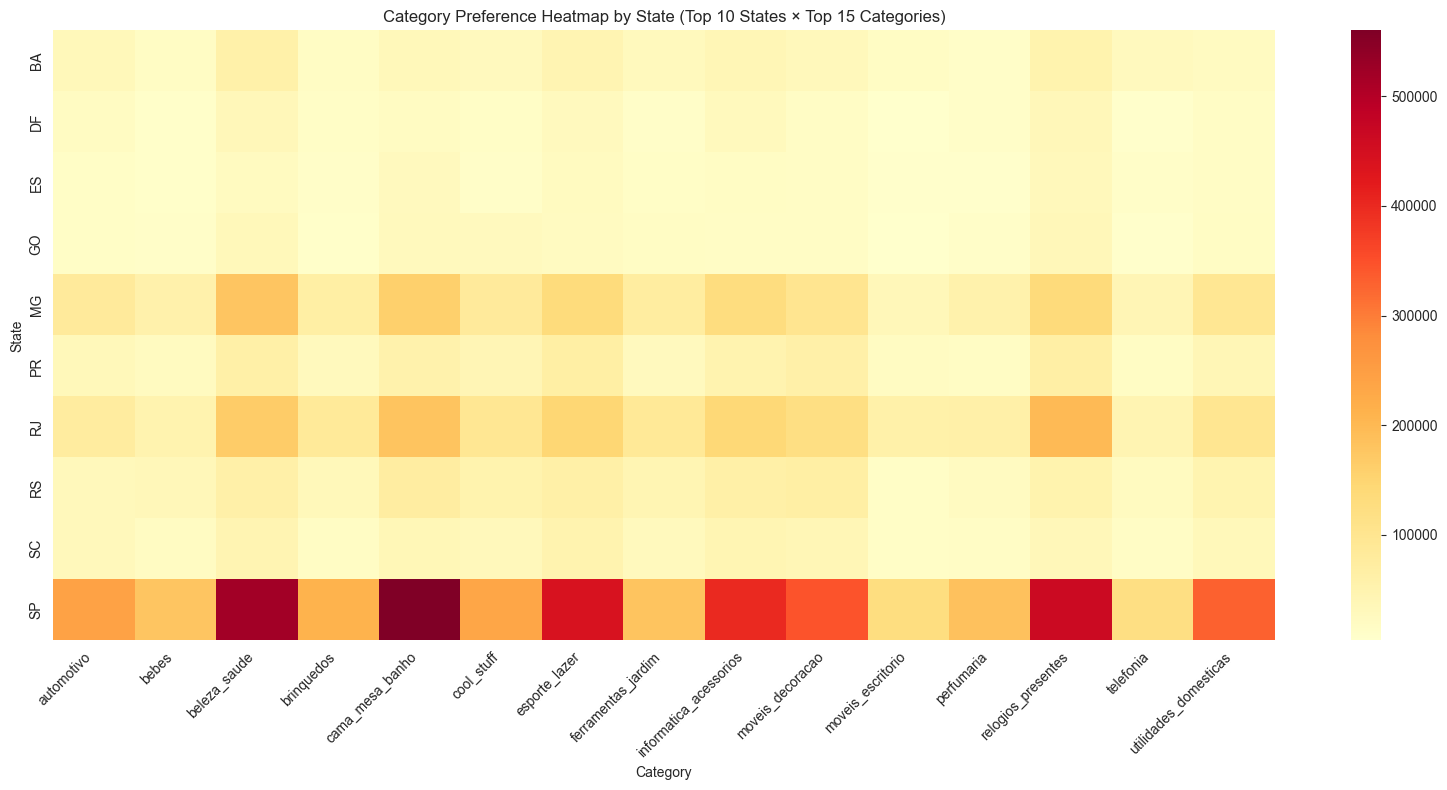

In [131]:
# visualise category preference by state

plt.figure(figsize=(16, 8))
sns.heatmap(
    state_category_pivot,
    cmap="YlOrRd"
)

plt.title("Category Preference Heatmap by State (Top 10 States × Top 15 Categories)")
plt.xlabel("Category")
plt.ylabel("State")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

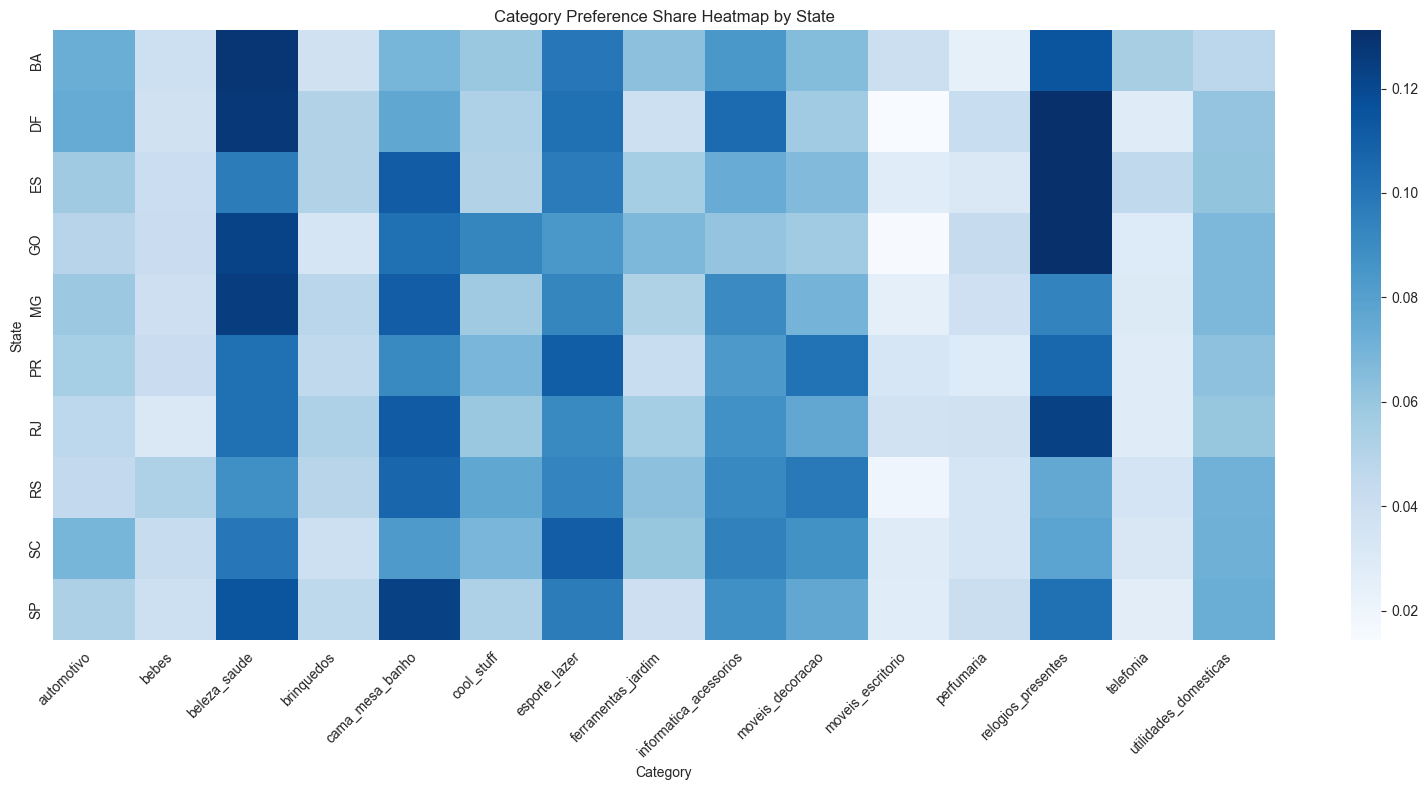

In [132]:
# optional: normalise category GMV within each state
# this helps compare structure rather than absolute market size

state_category_share = state_category_pivot.div(
    state_category_pivot.sum(axis=1),
    axis=0
)

plt.figure(figsize=(16, 8))
sns.heatmap(
    state_category_share,
    cmap="Blues"
)

plt.title("Category Preference Share Heatmap by State")
plt.xlabel("Category")
plt.ylabel("State")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Category Preference Heatmap by State Analysis
The original `GMV` heatmap shows that category sales are still strongly influenced by overall state size. `SP` is visibly brighter across most major categories, and `RJ` and `MG` also stand out in several product groups. This means the raw heatmap is useful for showing **where category value is concentrated**, but it does not by itself tell us whether a state truly prefers a category or is simply larger in total market scale.

The normalised heatmap is more informative for structure. After converting category `GMV` into within-state shares, the cross-state differences become narrower but still visible, which suggests that regional demand is based on a **shared national category core with moderate local variation**. Categories such as `beleza_saude`, `cama_mesa_banho`, `esporte_lazer`, and `relogios_presentes` remain important in many top states, while some categories become relatively more prominent in specific states than in others. This is important because it shows that regional assortment strategy should not start from the idea that every state is completely different; instead, it should start from a common product backbone and then adjust around the categories that are relatively stronger in each regional market.

### 8.3 Regional Specialty Categories with Location Quotient

After comparing category patterns across states, the next step is to identify whether some categories are relatively more concentrated in specific states than the national average. This step is useful because raw `GMV` can show market size, but it cannot clearly separate **absolute sales strength** from **relative category preference**.

At this stage, the analysis uses `Location Quotient (LQ)` as a relative preference measure. This is intentional: an `LQ` above `1` means the category has a larger share in a given state than it has nationally, while an `LQ` above `1.5` can be used as a stronger signal of regional specialty. The purpose here is not to claim cultural causality, but to identify category-state combinations that are structurally more prominent than expected.

In [133]:
# calculate national category share and state-level category share
# use GMV share rather than order count to reflect economic weight more directly

national_category_share = (
    df_orders_category.groupby("category")["gmv"].sum() /
    df_orders_category["gmv"].sum()
)

state_category_share_long = state_category_gmv.copy()
state_total_gmv = state_category_share_long.groupby("customer_state")["total_gmv"].transform("sum")
state_category_share_long["state_category_share"] = (
    state_category_share_long["total_gmv"] / state_total_gmv
)

state_category_share_long["national_category_share"] = (
    state_category_share_long["category"].map(national_category_share)
)

state_category_share_long.head()

,customer_state,category,total_gmv,order_count,state_category_share,national_category_share
0,AC,artigos_de_natal,130.85,1,0.006696,0.000767
1,AC,automotivo,661.91,4,0.033871,0.043761
2,AC,bebes,871.97,3,0.044619,0.030645
3,AC,beleza_saude,1655.00,7,0.084688,0.092119
4,AC,brinquedos,318.05,3,0.016275,0.035822


In [134]:
# compute location quotient (LQ)

state_category_share_long["lq"] = (
    state_category_share_long["state_category_share"] /
    state_category_share_long["national_category_share"]
)

print("State-category LQ table:")
display(
    state_category_share_long[
        [
            "customer_state",
            "category",
            "total_gmv",
            "state_category_share",
            "national_category_share",
            "lq"
        ]
    ].head().round(4)
)

State-category LQ table:


,customer_state,category,total_gmv,state_category_share,national_category_share,lq
0,AC,artigos_de_natal,130.85,0.0067,0.0008,8.7254
1,AC,automotivo,661.91,0.0339,0.0438,0.7740
2,AC,bebes,871.97,0.0446,0.0306,1.4560
3,AC,beleza_saude,1655.00,0.0847,0.0921,0.9193
4,AC,brinquedos,318.05,0.0163,0.0358,0.4543


In [135]:
# focus on top 10 states and top 15 categories for clearer interpretation

lq_focus = state_category_share_long[
    (state_category_share_long["customer_state"].isin(top10_states)) &
    (state_category_share_long["category"].isin(top15_categories))
].copy()

print("Focused LQ table (top 10 states × top 15 categories):")
display(
    lq_focus[
        [
            "customer_state",
            "category",
            "total_gmv",
            "state_category_share",
            "national_category_share",
            "lq"
        ]
    ].sort_values(["customer_state", "lq"], ascending=[True, False]).round(4)
)

Focused LQ table (top 10 states × top 15 categories):


,customer_state,category,total_gmv,state_category_share,national_category_share,lq
187,BA,telefonia,25688.79,0.0425,0.0252,1.6866
175,BA,moveis_escritorio,18923.63,0.0313,0.0219,1.4274
163,BA,ferramentas_jardim,29825.34,0.0493,0.0374,1.3208
133,BA,automotivo,34247.82,0.0567,0.0438,1.2946
136,BA,beleza_saude,60254.07,0.0997,0.0921,1.0820
...,...,...,...,...,...,...
1324,SP,relogios_presentes,463521.22,0.0791,0.0834,0.9485
1266,SP,automotivo,240975.64,0.0411,0.0438,0.9392
1284,SP,cool_stuff,235987.17,0.0402,0.0460,0.8759
1298,SP,ferramentas_jardim,180641.35,0.0308,0.0374,0.8248


In [136]:
# identify stronger regional specialty signals
# use LQ > 1.5 as a practical threshold for more distinctive concentration

specialty_categories = lq_focus[lq_focus["lq"] > 1.5].copy()

print("Regional specialty category combinations (LQ > 1.5):")
display(
    specialty_categories[
        ["customer_state", "category", "total_gmv", "lq"]
    ].sort_values(["customer_state", "lq"], ascending=[True, False]).round(3)
)

Regional specialty category combinations (LQ > 1.5):


,customer_state,category,total_gmv,lq
187,BA,telefonia,25688.79,1.687
383,GO,cool_stuff,25647.35,1.640


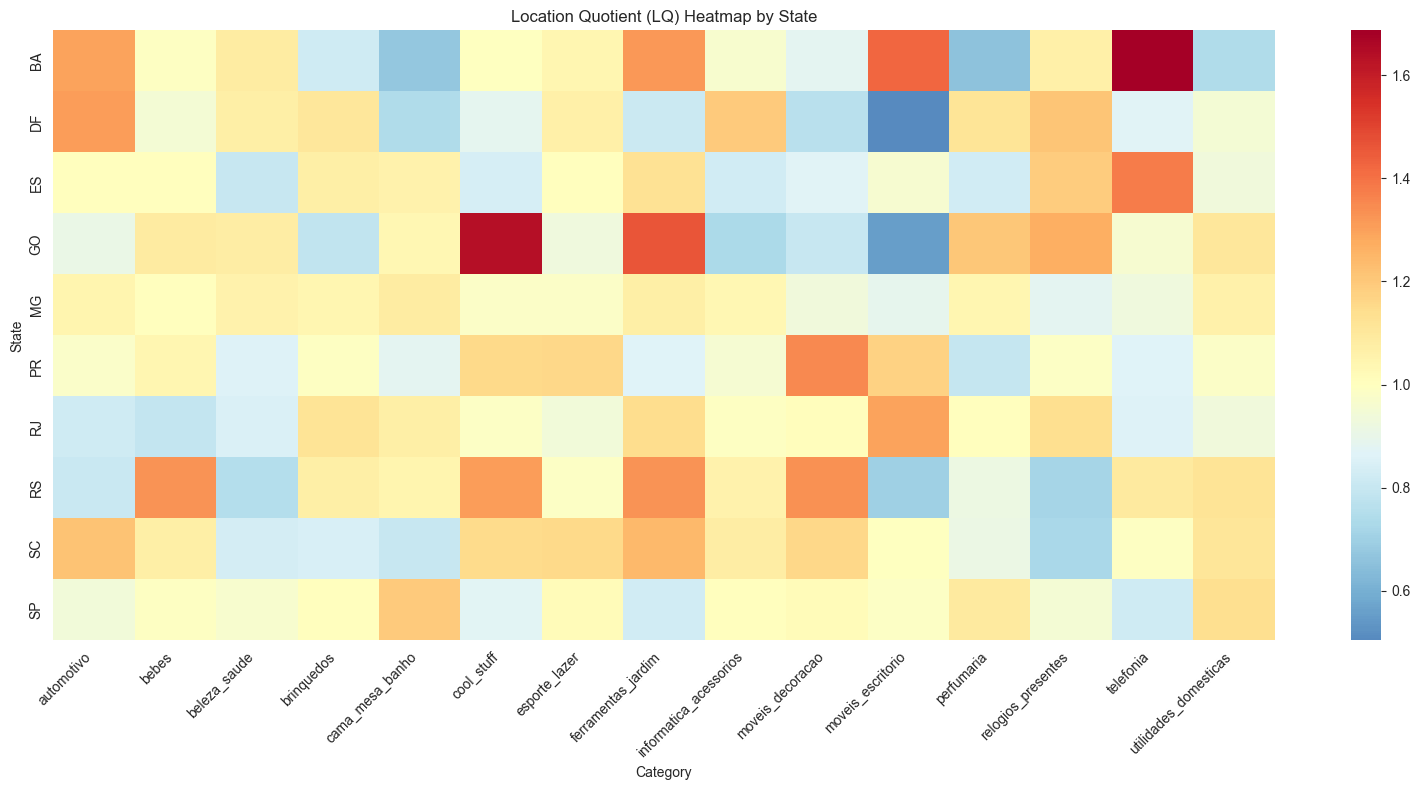

In [137]:
# build LQ heatmap for top 10 states × top 15 categories

lq_pivot = lq_focus.pivot(
    index="customer_state",
    columns="category",
    values="lq"
).fillna(0)

plt.figure(figsize=(16, 8))
sns.heatmap(
    lq_pivot,
    cmap="RdYlBu_r",
    center=1
)

plt.title("Location Quotient (LQ) Heatmap by State")
plt.xlabel("Category")
plt.ylabel("State")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Regional Specialty Categories Analysis
The `LQ` results show that most major states do **not** have extremely specialised product structures across the top categories. For most `state-category` combinations, the relative concentration stays around the national average, which suggests that the platform’s leading markets are still built on a fairly shared demand base rather than on sharply separated regional tastes. This is important because it means high `GMV` in a category often comes from overall state size, not necessarily from unusually strong local preference.

At the same time, the `LQ > 1.5` filter still identifies a small number of clearer specialty signals. In the current top-state view, `BA - telefonia` and `GO - cool_stuff` stand out as the most visible cases of **relative over-concentration**. The `LQ` heatmap supports this broader interpretation: regional variation exists, but it is selective rather than widespread. At this stage, the evidence suggests that regional assortment should not be built around the assumption that every state needs a completely different category strategy. A more realistic approach is to start from a common high-performing category base and then strengthen only the categories that show **meaningful relative concentration** in specific states.

### 8.4 Category Preference by Regional Cluster

After identifying state-level category patterns and `LQ`-based specialty signals, the next step is to compare category structure across the previously defined `cluster_name` groups. This step is useful because state-level analysis can reveal local variation, but cluster-level comparison helps show whether broader regional types also differ in product mix.

At this stage, the analysis uses category-level `GMV` aggregated by `cluster_name`. This is intentional: the goal is not to compare every individual state again, but to test whether the regional segmentation identified earlier is also reflected in demand composition. A share-based heatmap is used to compare structure more fairly, because raw `GMV` alone would be dominated by larger clusters such as `Balanced Core Markets` or the `Super Core Outlier Market`.

In [138]:
# merge cluster labels into the state-category table

state_cluster_map = df_state_clustered[["customer_state", "cluster_name"]].copy()

cluster_category_gmv = state_category_gmv.merge(
    state_cluster_map,
    on="customer_state",
    how="left"
)

print("Cluster-category GMV table:")
display(cluster_category_gmv.head())

Cluster-category GMV table:


,customer_state,category,total_gmv,order_count,cluster_name
0,AC,artigos_de_natal,130.85,1,High-AOV Potential Markets
1,AC,automotivo,661.91,4,High-AOV Potential Markets
2,AC,bebes,871.97,3,High-AOV Potential Markets
3,AC,beleza_saude,1655.00,7,High-AOV Potential Markets
4,AC,brinquedos,318.05,3,High-AOV Potential Markets


In [139]:
# aggregate category GMV by cluster

cluster_category_summary = (
    cluster_category_gmv.groupby(["cluster_name", "category"])
    .agg(
        total_gmv=("total_gmv", "sum"),
        total_orders=("order_count", "sum")
    )
    .reset_index()
)

print("Cluster-category summary:")
display(cluster_category_summary.head())

Cluster-category summary:


,cluster_name,category,total_gmv,total_orders
0,Balanced Core Markets,agro_industria_e_comercio,35412.91,85
1,Balanced Core Markets,alimentos,13460.45,177
2,Balanced Core Markets,alimentos_bebidas,8442.90,115
3,Balanced Core Markets,artes,8993.34,87
4,Balanced Core Markets,artes_e_artesanato,1093.37,8


In [140]:
# show top 5 categories within each regional cluster

cluster_top_categories = (
    cluster_category_summary
    .sort_values(["cluster_name", "total_gmv"], ascending=[True, False])
)

print("Top 5 categories within each cluster:")
display(cluster_top_categories.groupby("cluster_name").head(5).round(2))

Top 5 categories within each cluster:


,cluster_name,category,total_gmv,total_orders
11,Balanced Core Markets,beleza_saude,618516.05,4042
66,Balanced Core Markets,relogios_presentes,598421.52,2723
13,Balanced Core Markets,cama_mesa_banho,591193.51,5167
32,Balanced Core Markets,esporte_lazer,549840.06,3994
44,Balanced Core Markets,informatica_acessorios,504528.04,3713
82,High-AOV Potential Markets,beleza_saude,124194.62,565
130,High-AOV Potential Markets,relogios_presentes,95654.41,386
101,High-AOV Potential Markets,esporte_lazer,63790.52,358
111,High-AOV Potential Markets,informatica_acessorios,53747.05,326
79,High-AOV Potential Markets,automotivo,45756.85,222


In [141]:
# focus on top 15 national categories for clearer comparison

cluster_heatmap_data = cluster_category_summary[
    cluster_category_summary["category"].isin(top15_categories)
].copy()

cluster_category_pivot = cluster_heatmap_data.pivot(
    index="cluster_name",
    columns="category",
    values="total_gmv"
).fillna(0)

# normalise within each cluster to compare structure rather than size
cluster_category_share = cluster_category_pivot.div(
    cluster_category_pivot.sum(axis=1),
    axis=0
)

print("Cluster-category share table:")
display(cluster_category_share.round(4))

Cluster-category share table:


category,automotivo,bebes,beleza_saude,brinquedos,cama_mesa_banho,cool_stuff,esporte_lazer,ferramentas_jardim,informatica_acessorios,moveis_decoracao,moveis_escritorio,perfumaria,relogios_presentes,telefonia,utilidades_domesticas
cluster_name,,,,,,,,,,,,,,,
Balanced Core Markets,0.0548,0.0394,0.1082,0.0479,0.1035,0.0638,0.0962,0.0542,0.0883,0.0783,0.0278,0.0363,0.1047,0.0305,0.0661
High-AOV Potential Markets,0.0658,0.0380,0.1785,0.0468,0.0533,0.0650,0.0917,0.0509,0.0772,0.0561,0.0242,0.0324,0.1375,0.0497,0.0329
Logistics-Stressed Markets,0.0727,0.0429,0.1521,0.0371,0.0532,0.0625,0.0884,0.0504,0.0894,0.0631,0.0348,0.0325,0.1255,0.0546,0.0405
Super Core Outlier Market,0.0531,0.0391,0.1146,0.0465,0.1233,0.0520,0.0973,0.0398,0.0880,0.0760,0.0279,0.0408,0.1021,0.0267,0.0728


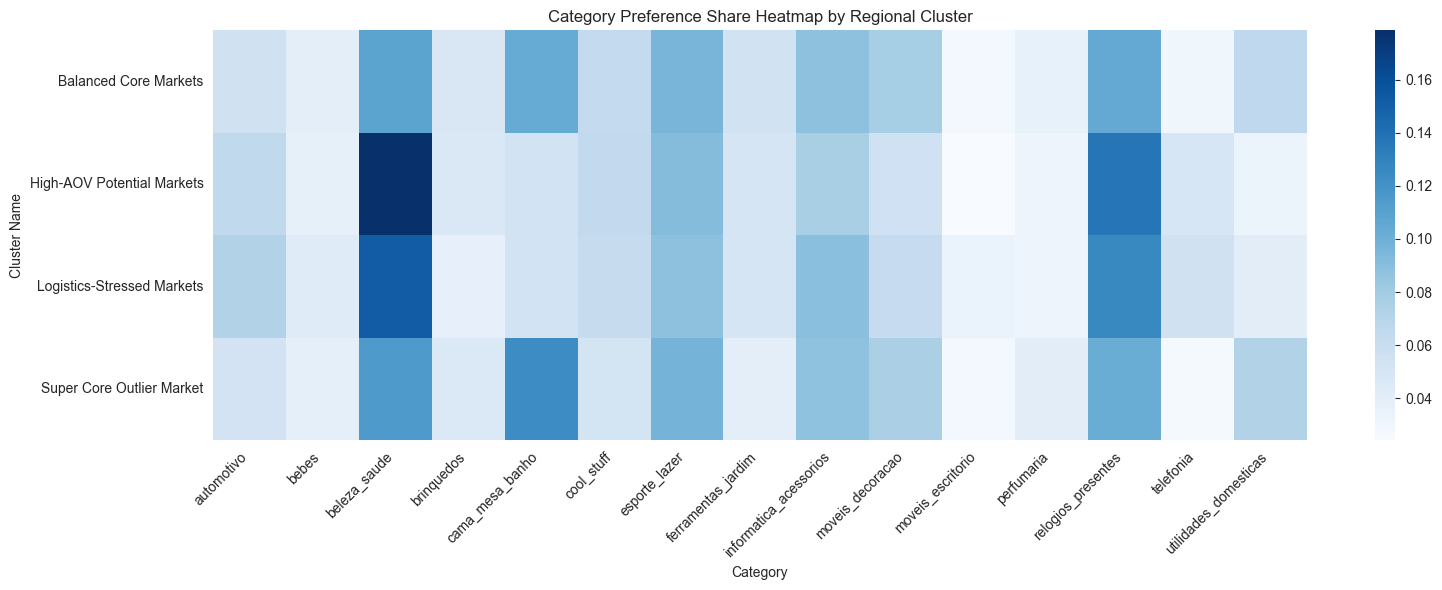

In [142]:
# visualise category structure by regional cluster

plt.figure(figsize=(16, 6))
sns.heatmap(
    cluster_category_share,
    cmap="Blues"
)

plt.title("Category Preference Share Heatmap by Regional Cluster")
plt.xlabel("Category")
plt.ylabel("Cluster Name")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### 8.5 Category Structure in Priority Problem Regions

After identifying `Priority Problem Region` states, the next step is to examine whether these regions also share a distinctive product structure. This step is useful because weak customer experience may not come only from logistics conditions; it may also be related to the category mix being sold in those markets.

At this stage, the analysis compares `Priority Problem Region` states with other high-volume states rather than with all states. This is intentional: low-volume states may add noise, while the main business question here is whether commercially important problem regions show a different demand structure. A share-based comparison is used so that the result reflects **relative category composition** rather than absolute market size.


In [144]:
# compare category structure between priority problem regions and other high-volume states

high_volume_states = df_state[df_state["order_count"] >= median_order_count]["customer_state"].tolist()
priority_problem_states = df_state_problem_flag[
    df_state_problem_flag["problem_region_flag"] == "Priority Problem Region"
]["customer_state"].tolist()

state_group_map = pd.DataFrame({
    "customer_state": high_volume_states
})

state_group_map["region_group"] = np.where(
    state_group_map["customer_state"].isin(priority_problem_states),
    "Priority Problem Regions",
    "Other High-volume States"
)

print("State grouping for problem-region category comparison:")
display(state_group_map)

State grouping for problem-region category comparison:


,customer_state,region_group
0,BA,Priority Problem Regions
1,CE,Priority Problem Regions
2,DF,Other High-volume States
3,ES,Priority Problem Regions
4,GO,Priority Problem Regions
5,MG,Other High-volume States
6,MT,Other High-volume States
7,PA,Priority Problem Regions
8,PE,Priority Problem Regions
9,PR,Other High-volume States


In [145]:
# merge the region-group label into the state-category GMV table

problem_region_category = state_category_gmv.merge(
    state_group_map,
    on="customer_state",
    how="inner"
)

print("Problem-region category table:")
display(problem_region_category.head())

Problem-region category table:


,customer_state,category,total_gmv,order_count,region_group
0,BA,agro_industria_e_comercio,2494.48,5,Priority Problem Regions
1,BA,alimentos,1371.83,18,Priority Problem Regions
2,BA,alimentos_bebidas,675.12,8,Priority Problem Regions
3,BA,artes,1111.25,10,Priority Problem Regions
4,BA,artigos_de_natal,1007.25,10,Priority Problem Regions


In [146]:
# aggregate category GMV by region group

problem_region_category_summary = (
    problem_region_category.groupby(["region_group", "category"])
    .agg(
        total_gmv=("total_gmv", "sum"),
        total_orders=("order_count", "sum")
    )
    .reset_index()
)

print("Problem-region category summary:")
display(problem_region_category_summary.head())

Problem-region category summary:


,region_group,category,total_gmv,total_orders
0,Other High-volume States,agro_industria_e_comercio,50879.38,142
1,Other High-volume States,alimentos,27094.16,397
2,Other High-volume States,alimentos_bebidas,12443.45,191
3,Other High-volume States,artes,21181.58,148
4,Other High-volume States,artes_e_artesanato,2184.14,24


In [148]:
# show the top categories in each region group

problem_region_top_categories = (
    problem_region_category_summary
    .sort_values(["region_group", "total_gmv"], ascending=[True, False])
)

print("Top 10 categories within each region group:")
display(problem_region_top_categories.groupby("region_group").head(10).round(2))

Top 10 categories within each region group:


,region_group,category,total_gmv,total_orders
11,Other High-volume States,beleza_saude,921471.10,6818
13,Other High-volume States,cama_mesa_banho,916544.17,8331
66,Other High-volume States,relogios_presentes,804022.57,3857
32,Other High-volume States,esporte_lazer,798191.67,6281
44,Other High-volume States,informatica_acessorios,726604.71,5612
54,Other High-volume States,moveis_decoracao,639028.03,6174
72,Other High-volume States,utilidades_domesticas,569808.54,5353
26,Other High-volume States,cool_stuff,468373.70,2589
8,Other High-volume States,automotivo,454609.04,3036
12,Other High-volume States,brinquedos,380775.89,2887


In [149]:
# focus on top 15 national categories for clearer structural comparison

problem_region_heatmap_data = problem_region_category_summary[
    problem_region_category_summary["category"].isin(top15_categories)
].copy()

problem_region_pivot = problem_region_heatmap_data.pivot(
    index="region_group",
    columns="category",
    values="total_gmv"
).fillna(0)

problem_region_share = problem_region_pivot.div(
    problem_region_pivot.sum(axis=1),
    axis=0
)

print("Problem-region category share table:")
display(problem_region_share.round(4))

Problem-region category share table:


category,automotivo,bebes,beleza_saude,brinquedos,cama_mesa_banho,cool_stuff,esporte_lazer,ferramentas_jardim,informatica_acessorios,moveis_decoracao,moveis_escritorio,perfumaria,relogios_presentes,telefonia,utilidades_domesticas
region_group,,,,,,,,,,,,,,,
Other High-volume States,0.0558,0.0409,0.1131,0.0467,0.1125,0.0575,0.0979,0.0457,0.0891,0.0784,0.0268,0.0385,0.0986,0.0286,0.0699
Priority Problem Regions,0.0548,0.0352,0.1233,0.0464,0.0915,0.0624,0.0914,0.0547,0.0812,0.0688,0.0331,0.0359,0.1281,0.0384,0.0548


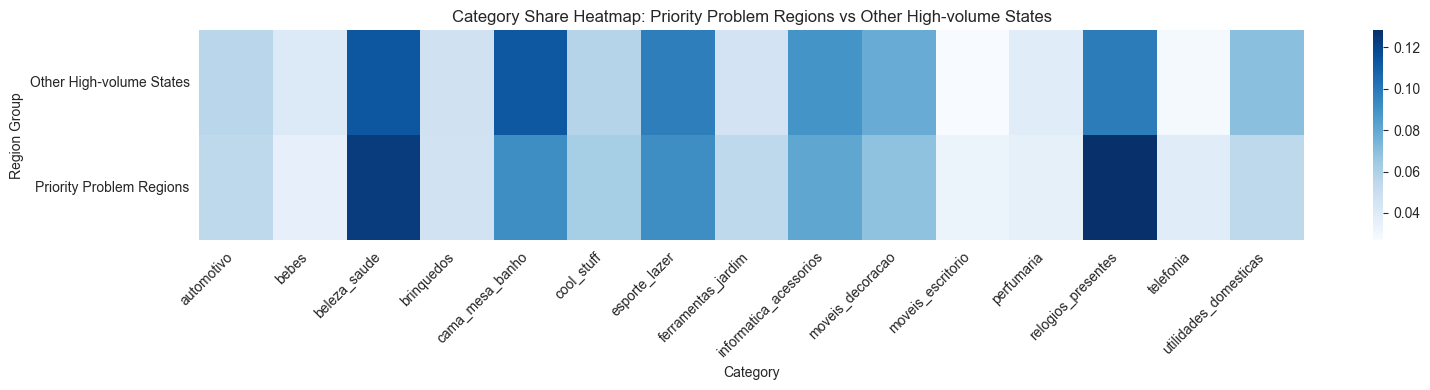

In [150]:
# visualise category-share structure for problem regions vs other high-volume states

plt.figure(figsize=(16, 4))
sns.heatmap(
    problem_region_share,
    cmap="Blues"
)

plt.title("Category Share Heatmap: Priority Problem Regions vs Other High-volume States")
plt.xlabel("Category")
plt.ylabel("Region Group")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Category Structure in Priority Problem Regions Analysis
The category comparison shows that `Priority Problem Regions` do **not** have a completely different product structure from other high-volume states. The leading categories still overlap heavily, including `relogios_presentes`, `beleza_saude`, `cama_mesa_banho`, `esporte_lazer`, and `informatica_acessorios`. This means the weaker performance of problem regions is not mainly explained by a totally different demand base, but by markets that sell broadly similar core categories under less favourable operating conditions.

At the same time, the share-based comparison suggests that the mix is **not perfectly identical**. `Priority Problem Regions` appear relatively more concentrated in categories such as `beleza_saude`, `relogios_presentes`, and `cool_stuff`, while categories like `cama_mesa_banho` appear slightly less dominant than in other high-volume states. This is important because it suggests that the issue is not simply “bad regions buy different things,” but rather that a familiar national category set may create different execution pressure across regions. At this stage, the evidence supports a more balanced interpretation: category structure may contribute to regional experience gaps at the margin, but the main problem still looks more operational than purely demand-driven.